# GeoLocate Demo: Spatial Modeling of Market Entry Viability

Business survival remains a persistent global challenge, with a large share of new ventures failing within their first years—often due to entering markets with unfavorable local conditions. Despite this, market entry decisions are typically guided by non-spatial indicators that fail to capture localized differences in infrastructure, accessibility, and socioeconomic context.

GeoLocate addresses this gap by treating market viability as a spatially dependent problem. It is a spatial modeling framework designed to identify geographically favorable locations for market entry by explicitly accounting for local heterogeneity and spatial dependence.

The framework integrates multimodal data from high-resolution satellite imagery (Sentinel-2), road infrastructure networks (OpenStreetMap), and socioeconomic and business registry data to estimate business survival probabilities across municipalities.

### Key components of the framework include:

- **Bayesian Spatial Modeling:** Business survival probabilities are estimated using a hierarchical model with a BYM2 spatial component. This specification accounts for spatial dependence by allowing neighboring municipalities to share information, capturing residual geographic structure not explained by observed covariates.
- **Multi-Source Feature Integration:** The model combines heterogeneous data sources into a unified predictor set, including spectral land-use indices derived from Sentinel-2 imagery, road infrastructure density from OpenStreetMap, socioeconomic indicators from Brazilian Institute of Geography and Statistics (IBGE) (e.g., Human Development Index components), and firm-level counts from the Brazilian Federal Revenue (RFB). This integration enables analysis in settings where individual data sources may be incomplete or unevenly distributed.
- **Probabilistic Inference and Uncertainty Quantification:** The framework produces full posterior distributions for survival probabilities, $p(\text{success}_i \mid \text{data})$. Posterior means summarize expected outcomes, while posterior dispersion reflects uncertainty, allowing differences in estimate precision to be assessed across locations.

This notebook presents the full GeoLocate workflow, from data preparation to model evaluation:

1. **Data Description and Processing:** Overview of the integrated data sources (satellite imagery, road infrastructure, socioeconomic indicators, and business registry data) and the preprocessing steps used to construct model inputs.
2. **Model Implementation and Results:** The Bayesian spatial model is applied to a São Paulo case study, Brazil’s largest and most economically dynamic state, with 645 municipalities. Results include maps of predicted survival probabilities, uncertainty, and latent spatial effects. Model performance is assessed using Pareto-Smoothed Importance Sampling Leave-One-Out cross-validation (PSIS-LOO) and residual spatial diagnostics.
3. **Discussion and Limitations:** Summary of findings, model limitations, and directions for future work, including potential extensions to other regions and data contexts.

#### Want to learn more?

Check out repositories Model GitHub repo: [rtjaiany/succesful_areas](https://github.com/rtjaiany/succesful_areas)

### Table of Contents

1. [Introduction](#1-·-Introduction)
   - [Why GeoLocate?](#Why-GeoLocate?)
2. [Data Description](#2-·-Data-Description)
   - [Road Network](#2.1-·-Road-Network)
   - [Satellite Data](#2.2-·-Satellite-Data)
   - [Socioeconomic Data (IBGE)](#2.3-·-Socioeconomic-Data-(IBGE))
   - [Business Registry Data](#2.4-·-Business-Registry-Data)
3. [Methodological Description](#3-·-Methodological-Description)
   - [Core Probabilistic Architecture](#3.1-·-Core-Probabilistic-Architecture)
   - [Architecture I — São Paulo Pilot (N ≈ 645)](#3.2-·-Architecture-I-—-São-Paulo-Pilot-(N-≈-645))
   - [Architecture II — Nationwide Hierarchical Model (N = 5,570)](#3.3-·-Architecture-II-—-Nationwide-Hierarchical-Model-(N-=-5,570))
   - [Inference and Validation](#3.4-·-Inference-and-Validation)
4. [Use Case: São Paulo](#4-·-Use-Case:-São-Paulo)
   - [Data Preparation](#4.1-·-Data-Preparation)
   - [Model Structure](#4.2-·-Model-Structure)
   - [Bayesian Lasso](#4.3-·-Bayesian-Lasso)
   - [Linear Baseline Model](#4.4-·-Linear-Baseline-Model)
   - [BYM2 Spatial Model](#4.5-·-BYM2-Spatial-Model)
   - [Model Comparison: PSIS-LOO Cross-Validation](#4.6-·-Model-Comparison:-PSIS-LOO-Cross-Validation)
   - [Posterior Predictive Check & Residual Spatial Autocorrelation Test](#4.7-·-Posterior-Predictive-Check-&-Residual-Spatial-Autocorrelation-Test)
   - [Spatial Block K-Fold Cross-Validation](#4.8-·-Spatial-Block-K-Fold-Cross-Validation)
   - [Sensitivity Analysis: Prior Robustness Audit](#4.9-·-Sensitivity-Analysis:-Prior-Robustness-Audit)
   - [Posterior Predictive Density Calibration](#4.10-·-Posterior-Predictive-Density-Calibration)
   - [Visualizations](#4.11-·-Visualizations)
5. [Nationwide Framework](#5-·-Nationwide-Framework)
   - [Hierarchical BYM2 Spatial Model (N = 5,570)](#5.1-·-Hierarchical-BYM2-Spatial-Model-(N-=-5,570))
   - [Nationwide Visualizations](#5.2-·-Nationwide-Visualizations)
6. [Results](#6-·-Results-&-Discussion)
7. [Discussions, Limitations, and Future Directions](#7-·-Impact,-Limitations,-and-Future-Directions)
8. [References](#References)

# 1 - Introduction

Deciding the spatial location for market entry  is one of the most critical strategic decisions for firms seeking sustained growth and long-term competitive advantage. It represents a pivotal step into an uncertain environment, where firms must evaluate demand, competition, infrastructure, and regional conditions before committing significant resources. Despite its strategic importance, market entry remains highly risky. Global statistics suggest that nearly 50% of new ventures cease operations within their first five years (Shepard, 2024). Among these failures, approximately 35% occur because the product or service does not meet an actual market need (CB Insights, 2021). These figures highlight the complexity of identifying viable opportunities and underscore the importance of informed entry strategies.

Within the strategic management and entrepreneurship literature, market entry is commonly defined as a firm's strategic move into a new or existing market (Markman et al., 2019). A growing body of research emphasizes that successful entry depends not only on firm capabilities but also on external environmental conditions such as market size, institutional context, and competitive dynamics (Akhter & Robles, 2006; Schellenberg et al., 2018). Consequently, improving the ability to identify favorable conditions for market entry has become a key concern for scholars and practitioners.

However, existing market-entry frameworks often prioritize aggregate indicators such as market size, income levels, or industry growth (e.g., Conceição et al., 2021; Pennerstorfer & Yontcheva, 2021), while paying comparatively limited attention to spatial heterogeneity, the geographic variation in infrastructure, accessibility, demographics, and economic activity that shapes real market opportunities. This limitation is particularly pronounced in developing or structurally uneven regions, where economic conditions can vary dramatically across short geographic distances.

## Why GeoLocate?

In the contexts, entrepreneurs and policymakers frequently lack robust spatial decision-support tools to identify where business opportunities are most viable. Poor location decisions can lead to misallocation of capital, increased business failure rates, and the reinforcement of regional economic inequality. Addressing this gap requires analytical frameworks that integrate multiple dimensions of local economic conditions into predictive models.

To address this challenge, this project **proposes a Spatial Artificial Intelligence (Spatial AI) framework based on a Bayesian hierarchical spatial model to identify geographically favorable locations for market entry**. Crucially, the selection of variables is guided by a structured representation of market viability, rather than ad hoc data inclusion.

Specifically, the model incorporates three complementary dimensions that are consistently identified in the literature as key drivers of firm performance:

- **Infrastructure and accessibility (OpenStreetMap):** Road density and network characteristics capture physical connectivity, which determines market access, transportation costs, and the ability of firms to reach customers and suppliers.

- **Land use and environmental context (Sentinel-2 via Google Earth Engine):** Remote sensing indices such as the Normalized Difference Vegetation Index (NDVI) and the Normalized Difference Built-up Index (NDBI) provide consistent, high-resolution proxies for urbanization, land-use intensity, and economic activity. These variables are particularly valuable in regions where official statistics are incomplete or outdated.

- **Socioeconomic conditions:** Indicators such as income, human development (HDI), population density, and labor market characteristics capture local demand potential, human capital, and economic structure.

These explanatory variables are complemented by **business registry data**, which provide observed firm outcomes and enable the direct estimation of business survival probabilities. Together, this combination ensures that the model captures observable economic conditions and latent spatial dependencies, aligning variable selection with established theoretical drivers of market success.

By integrating these heterogeneous spatial datasets, the model estimates the probability that specific locations can support the successful establishment of new firms. The resulting framework generates probabilistic spatial maps that rank areas according to their predicted viability for market entry. Brazil serves as the initial case study due to  its large regional disparities. However, the methodology is designed to be generalizable to other developing economies and underserved regions within advanced countries.

# 2. Data Description and Availability

This study integrates geospatial, remote sensing, and administrative datasets to construct municipality-level indicators of infrastructure, land use, and economic activity across Brazil. All datasets used in this study, along with processed features and model outputs (including the Success Index and Risk Maps), are deposited and publicly accessible through the **I-GUIDE Platform**. The data are provided in reproducible formats, with documented preprocessing pipelines, ensuring transparency and reusability.

The analytical framework combines four primary data sources: (i) road network data from OpenStreetMap, (ii) satellite-derived variables from Sentinel-2 imagery processed via Google Earth Engine, (iii) socioeconomic indicators from the Brazilian Institute of Geography and Statistics, and (iv) business registry data from the Federal Revenue Service of Brazil.

---

## 2.1 Data Sources and Rationale

Market viability is inherently spatial and multi-dimensional. The selected datasets reflect complementary dimensions of this process:

- **Infrastructure (OpenStreetMap)** captures physical accessibility and connectivity, which are critical for market reach and logistics (e.g., Costa et al. 2018; Jin et al. 2022).  
- **Remote sensing (Sentinel-2 via Google Earth Engine)** provides consistent, high-resolution proxies for land use, urbanization, and environmental conditions (e.g., Ngolo & Watanabe, 2023).  
- **Socioeconomic indicators (IBGE)** represent income, human capital, and demographic structure (e.g., Guzman et al. 2017; Yano & Shiraishi, 2020).  
- **Business registry data (Receita Federal)** provide observed firm outcomes, enabling direct estimation of survival probabilities (e.g., McKenzie, 2017).  

This combination allows the model to capture both observed economic conditions and latent spatial structure, addressing limitations of traditional non-spatial approaches that rely solely on aggregated indicators.

---

## 2.2 Acronyms and Definitions

- **IBGE** — Instituto Brasileiro de Geografia e Estatística (Brazilian Institute of Geography and Statistics)  
- **RFB** — Receita Federal do Brasil (Federal Revenue Service of Brazil)  
- **OSM** — OpenStreetMap  
- **GEE** — Google Earth Engine  
- **NDVI** — Normalized Difference Vegetation Index  
- **EVI** — Enhanced Vegetation Index  
- **SAVI** — Soil-Adjusted Vegetation Index  
- **NDWI** — Normalized Difference Water Index  
- **MNDWI** — Modified Normalized Difference Water Index  
- **NDBI** — Normalized Difference Built-up Index  
- **SWIR** — Shortwave Infrared  
- **NIR** — Near Infrared  
- **HDI** — Human Development Index  

---

## 2.3 Unified Data Dictionary

| Source | Variable | Type | Description | Example Values |
|--------|----------|------|-------------|----------------|
| **OpenStreetMap (OSM)** | `road_density_km_km2` | Continuous | Road length per square kilometer (connectivity proxy) | 0.5, 2.3, 10.8 |
| | `intersection_density` | Continuous | Number of intersections per km² | 5, 20, 75 |
| | `highway_type` | Categorical | Road classification (e.g., primary, residential) | primary, secondary |
| | `lanes` | Integer | Number of lanes | 1, 2, 4 |
| | `maxspeed` | Continuous | Speed limit (km/h) | 40, 60, 100 |
| | `length_km` | Continuous | Road segment length | 0.2, 1.5 |
| | `geometry` | Geometry | LineString representation | — |
| **Sentinel-2 (GEE)** | `red`, `green`, `blue` | Continuous | Surface reflectance bands (visible spectrum) | 0.1–0.4 |
| | `nir` | Continuous | Near Infrared reflectance | 0.2–0.6 |
| | `swir_1`, `swir_2` | Continuous | Shortwave infrared bands | 0.1–0.5 |
| | `ndvi` | Continuous | Vegetation density index | -0.2 to 0.8 |
| | `evi` | Continuous | Enhanced vegetation index | 0–1 |
| | `savi` | Continuous | Soil-adjusted vegetation index | 0–1 |
| | `ndwi` | Continuous | Water presence index | -1 to 1 |
| | `mndwi` | Continuous | Modified water index | -1 to 1 |
| | `ndbi` | Continuous | Built-up surface proxy | -0.5 to 0.5 |
| | `urban_index` | Continuous | Composite urbanization proxy | 0–1 |
| **IBGE** | `GDP_per_capita` | Continuous | Municipal GDP per capita (BRL) | 15000, 35000 |
| | `avrg_monthly_salary` | Continuous | Average formal salary (RAIS) | 1500, 3500 |
| | `HDI_income` | Continuous | Income component of HDI | 0.5–0.9 |
| | `HDI_longevity` | Continuous | Life expectancy index | 0.6–0.9 |
| | `HDI_educational` | Continuous | Education index | 0.5–0.8 |
| | `population_density` | Continuous | Inhabitants per km² | 20, 500, 5000 |
| | `n_bank_branches` | Integer | Number of bank branches | 0, 10, 120 |
| | `vehicle_fleet_2021` | Integer | Registered vehicles | 1000, 50000 |
| **Receita Federal (RFB)** | `active` | Integer | Active establishments | 100, 5000 |
| | `failed` | Integer | Closed or suspended establishments | 10, 800 |
| | `active_head_offices` | Integer | Active headquarters (Matriz) | 50, 2000 |
| | `active_branches` | Integer | Active branches (Filial) | 20, 3000 |
| | `failure_rate` | Continuous | Share of failed establishments | 0.05, 0.25 |

---

## 2.4 Data Access

- **IBGE (Brazilian Institute of Geography and Statistics):**  
  https://www.ibge.gov.br/estatisticas/todos-os-produtos-estatisticas/2043-demografia-e-estatisticas-sociais/populacao/componentes-da-dinamica-demografica-e-estatisticas-vitais/np-estatisticas-do-registro-civil/9110-estatisticas-do-registro-civil.html?=&t=downloads  

- **Receita Federal do Brasil (Business Registry Data):**  
  https://arquivos.receitafederal.gov.br/index.php/s/YggdBLfdninEJX9  

- **OpenStreetMap (OSM):**  
  https://www.openstreetmap.org  

- **Google Earth Engine (Sentinel-2 Data):**  
  https://earthengine.google.com  

---

## 2.5 Outcome Construction

The business registry data define the model outcome. Firms classified as closed or suspended due to non-compliance or bankruptcy within a five-year window are aggregated at the municipality level.

For each municipality \(i\), the empirical survival probability is computed as:

**p̂ᵢ = activeᵢ / (activeᵢ + failedᵢ)**

where:

- `active` represents currently operating establishments
- `failed` represents firms that exited due to structural reasons (closure, suspension, or bankruptcy) within the defined time window

These counts are used within a Beta–Binomial framework, where:

- **kᵢ = activeᵢ** (successes)
- **nᵢ = activeᵢ + failedᵢ** (trials)

This formulation captures both observed outcomes and uncertainty due to varying sample sizes across municipalities, while focusing on structural business failure rather than short-term fluctuations.

# 3. Methodological Description

To model spatial variation in business survival, we employ the Besag–York–Mollié 2 (BYM2) formulation (Riebler et al., 2016). The original BYM model (Besag et al., 1991) decomposes spatial variation into structured and unstructured components but suffers from identifiability issues, as both components can capture similar variation. The BYM2 reparameterization addresses this limitation by introducing a single variance parameter $\sigma$ and a mixing proportion $\rho$ that controls the contribution of each component. This formulation improves interpretability and enables the use of penalized complexity (PC) priors (Simpson et al., 2017).

The modeling pipeline is implemented in two stages: a regional pilot (State of São Paulo, $N = 645$) and a nationwide hierarchical extension (Brazil, $N = 5{,}570$). Both stages share a common probabilistic structure, with additional hierarchy introduced in the national model.

The modeling framework is designed to estimate business survival probabilities at the municipality level by integrating the three key dimensions of market viability introduced earlier: infrastructure and accessibility, land-use and environmental context, and socioeconomic conditions.

From a probabilistic perspective, the model can be understood as a hierarchical system with three components:

- **(i) Prior distributions:** Penalized complexity priors are specified for variance and mixing parameters, providing regularization and improving interpretability of spatial and non-spatial effects.

- **(ii) Linear predictor:** Covariates derived from infrastructure (e.g., road density), land-use proxies (e.g., satellite-based indices), and socioeconomic indicators (e.g., income and human development) enter the model as fixed effects. Spatial dependence is incorporated through the BYM2 random effect, combining structured (neighbor-based) and unstructured components.

- **(iii) Likelihood:** Business survival is modeled as a proportion derived from counts of active firms relative to total registered firms within each municipality. While this naturally leads to a Binomial formulation, the observed data exhibit overdispersion, motivating the use of a Beta–Binomial likelihood.

This structure allows the model to jointly account for dispersion, spatial dependence, and covariate effects within a unified probabilistic framework, while maintaining consistency between the statistical specification and the conceptual drivers of market viability.

---

## 3.1 Core Probabilistic Architecture

Business survival is observed at the municipality level as the number of active firms $y_i$ out of a total $n_i$. Standard Binomial models assume independence and fixed variance, assumptions that are often violated due to spatial dependence and heterogeneity in municipality size. To address this, we adopt a Beta–Binomial likelihood, which allows for overdispersion:

$$
y_i \sim \text{BetaBinomial}(n_i,\; p_i \cdot \kappa + \epsilon,\; (1-p_i) \cdot \kappa + \epsilon)
$$

where $\epsilon = 0.01$ is a small offset introduced for numerical stability. The concentration parameter $\kappa \sim \text{HalfNormal}(50)$ controls dispersion, with larger values approaching the Binomial limit.

Spatial dependence is modeled using the BYM2 formulation:

$$
\delta_i = \sigma \left(\sqrt{1-\rho}\cdot\theta_i + \sqrt{\frac{\rho}{s}}\cdot\phi_i\right)
$$

where $\theta_i \sim \mathcal{N}(0,1)$ represents unstructured noise, $\phi_i \sim \text{ICAR}(W)$ is the structured spatial effect, $\sigma \sim \text{HalfNormal}(1)$ is the total standard deviation, and $\rho \sim \text{Beta}(2,2)$ controls the proportion of structured variation. The scaling constant $s$ ensures comparability across graph structures.

Spatial adjacency is defined using a Queen contiguity matrix $W$. Municipalities without shared borders are connected to their nearest neighbor to ensure graph connectivity. All covariates are standardized to zero mean and unit variance.

> The offset $\epsilon$ prevents the Beta distribution shape parameters from reaching zero when $p_i \to 0$ or $p_i \to 1$. This introduces a negligible bias, slightly shrinking the effective mean toward 0.5, given by $(p_i \kappa + \epsilon)/(\kappa + 2\epsilon)$. For typical values of $\kappa$, this effect is negligible but is reported for completeness.

---

## 3.2 Architecture I — São Paulo State Pilot ($N \approx 645$)

The São Paulo model uses a global intercept:

$$
\text{logit}(p_i) = \alpha + \mathbf{X}_i \boldsymbol{\beta} + \delta_i
$$

To reduce dimensionality and mitigate multicollinearity among the 27 candidate predictors, a two-stage Bayesian Lasso procedure is applied prior to fitting the full spatial model.

- **Stage 1:** A Bayesian Lasso model with Laplace priors ($b = 1.0$) and a Beta–Binomial likelihood is fitted **without the spatial component** using NUTS. This induces continuous shrinkage, reducing the influence of weak or redundant predictors. While spatial dependence is not explicitly modeled at this stage, the objective is not to obtain final effect estimates but to identify a stable and parsimonious subset of candidate covariates.

- **Stage 2:** Predictors are retained if their 94% highest density interval (HDI) excludes zero. This provides a probabilistic criterion for variable selection, after which the full spatial model (including BYM2 effects) is fitted.

This two-stage strategy prioritizes computational efficiency and robust regularization, while deferring the explicit modeling of spatial dependence to the final specification. Although ignoring spatial structure in Stage 1 may influence coefficient estimates, its impact on variable selection is limited in practice, as all effects are subsequently re-estimated within the full spatial model.

>Empirically, sensitivity analysis confirms that this procedure does not materially affect the final inference. In particular, the estimated spatial dependence parameter ($\rho$) remains highly stable under alternative prior specifications (0.847 vs. 0.851), with an absolute geometric difference of 0.0039, indicating negligible drift. This stability suggests that the likelihood is strongly informative and that variable selection is not driven by unmodeled spatial structure.
>This approach is consistent with common practice in high-dimensional Bayesian variable selection, where shrinkage-based methods are used to screen predictors prior to fitting more complex structured models (e.g, Park and Casella, 2008; Polson and Scott, 2012; Piironen and Vehtari, 2017). Similar strategies are widely adopted in hierarchical and spatial modeling contexts to improve stability and interpretability when dealing with large sets of correlated covariates.

---

## 3.3 Architecture II — Nationwide Hierarchical Model ($N = 5{,}570$)

Extending the model to all Brazilian municipalities requires accounting for differences across states. A hierarchical intercept structure is introduced:

$$
\text{logit}(p_i) = \alpha_{s[i]} + \mathbf{X}_i \boldsymbol{\beta} + \delta_i
$$

$$
\alpha_s = \mu_\alpha + \alpha_s^{\text{raw}} \cdot \sigma_\alpha, \qquad 
\alpha_s^{\text{raw}} \sim \mathcal{N}(0,1)
$$

This formulation enables partial pooling across states: estimates for states with limited data are informed by the national distribution, while states with more observations are primarily driven by local data. A non-centered parameterization is used to improve sampling efficiency and avoid pathological posterior geometries (Betancourt & Girolami, 2015).

---

## 3.4 Inference and Validation

Posterior inference is performed using the No-U-Turn Sampler (NUTS) via the JAX/NumPyro backend. Models are estimated using 4 chains, 3,000 posterior draws, 2,000 warm-up iterations, and a target acceptance rate of 0.95. Convergence is assessed using the Gelman–Rubin diagnostic ($\hat{R} < 1.05$).

**Prior Predictive Checks**  
Prior predictive simulations are conducted using the non-spatial model to verify that the chosen priors produce reasonable outcomes on the data scale. This step is restricted to the baseline model because the ICAR prior is improper and does not admit a standard prior predictive distribution.

**Model Comparison (PSIS-LOO)**  
Predictive performance is evaluated using Pareto Smoothed Importance Sampling Leave-One-Out cross-validation (PSIS-LOO; Vehtari et al., 2017). This approach estimates out-of-sample predictive accuracy without refitting the model and avoids disrupting the spatial adjacency structure.

**Residual Spatial Diagnostics (Moran’s I)**  
Residual spatial dependence is assessed using Moran’s I applied to normalized posterior predictive residuals:

$$
r_i = \frac{k_i - \hat{k}_i}{n_i}
$$

Values close to zero indicate the absence of residual spatial autocorrelation, suggesting that the spatial component has adequately captured geographic structure.

# 4 - Use Case: São Paulo State

The State of São Paulo is selected as the pilot case due to its economic significance and the analytical challenges it presents for spatial modeling. The state accounts for approximately 31% of Brazil’s GDP and comprises 645 municipalities, one of the largest number among all states. Its population exceeds 44 million and spans a highly diversified economic structure, including industry, services, finance, and agribusiness. From a modeling perspective, São Paulo provides a demanding test environment. The state exhibits a dense adjacency network, strong metropolitan concentration around the São Paulo Metropolitan Region - centered on the city of São Paulo, the state capital, and marked economic gradients between urban centers and interior municipalities. These features generate complex spatial dependencies and substantial variation in local conditions. This combination of economic scale, regional heterogeneity, and data availability makes São Paulo state a suitable setting for evaluating the proposed spatial model. The pilot analysis serves as a controlled environment for assessing model behavior before extending the framework to the national level.


### Setup: Install Dependencies
Run this cell if you haven't installed the needed libraries yet.

In [1]:
# Core Scientific and Spatial Stack
#%pip install pymc arviz libpysal esda spreg statsmodels scipy pytensor seaborn matplotlib numpy pandas geopandas shapely scikit-learn ipython --break-system-packages

# JAX Acceleration Stack (Crucial for the 'pm_jax' sampler)
# For Mac users:
#%pip install jax jaxlib numpyro jax-metal --break-system-packages

# For Windows/Linux users (CPU only):
#%pip install jax jaxlib numpyro --break-system-packages

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


### Loading Libraries

In [32]:
# ── 1. UTILITIES AND ENVIRONMENT SETUP ────────────────────────────────
import gc         # Garbage Collector to manage memory during heavy sampling
import time       # To calculate execution duration of model runs
import datetime   # To provide human-readable timestamps in logs
import warnings   # To manage and suppress non-critical library warnings
from pathlib import Path # Object-oriented filesystem paths
import jax # To improve the model speed
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
import logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger("jax").setLevel(logging.FATAL)
logging.getLogger("pymc").setLevel(logging.CRITICAL)
# ── 2. CORE SCIENTIFIC AND GEOSPATIAL LIBRARIES ───────────────────────
import numpy as np      # Fundamental package for linear algebra and arrays
import pandas as pd     # Data manipulation and analysis tool
import scipy as sp      # Scientific computing and advanced math functions
import geopandas as gpd # Extension of pandas for geographic data types
from shapely import wkt # Handling 'Well-Known Text' for geometry processing

# ── 3. VISUALIZATION ──────────────────────────────────────────────────
import matplotlib.pyplot as plt # Standard plotting engine
import seaborn as sns           # High-level statistical data visualization
from matplotlib.lines import Line2D # Customizing legend lines
from IPython.display import display, Markdown # Formatting notebook output
import matplotlib.patches as mpatches # Drawing custom shapes in plots

# ── 4. STATISTICAL AND SPATIAL ANALYSIS ───────────────────────────────
import statsmodels.api as sm # Statistical models like OLS or GLM
from statsmodels.stats.outliers_influence import variance_inflation_factor # Checking multicollinearity
import libpysal as lps       # Library for spatial analysis functions
from esda.moran import Moran # Global Moran's I spatial autocorrelation test
from sklearn.cluster import KMeans # Unsupervised clustering algorithm
from sklearn.metrics import mean_absolute_error, mean_squared_error # Model error metrics
from math import pi          # Mathematical constant for geometry calculations
from esda.moran import Moran_Local # Local Indicators of Spatial Association (LISA)

# ── 5. BAYESIAN MODELING ──────────────────────────────────────────────
import pymc as pm               # Probabilistic programming framework
import pymc.sampling.jax as pm_jax # JAX-accelerated MCMC sampling
import pytensor.tensor as pt    # Tensor math library used by PyMC
import arviz as az              # Visualizing and diagnosing Bayesian traces

# Optional: Force CPU if JAX-Metal encounters issues on certain Mac setups
# import os 
# os.environ["JAX_PLATFORM_NAME"] = "cpu" 

# ── 6. FORMATTING & CONFIRMATION ──────────────────────────────────────
# Ignore deprecation and future warnings for a cleaner output
warnings.filterwarnings('ignore')
# Apply a clean visual theme for all subsequent plots
sns.set_theme(style="whitegrid", palette="viridis")

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] ✅ Libraries loaded successfully!")

[21:52:06] ✅ Libraries loaded successfully!


## 4.1. Data Preparation

Loading the primary dataset and preparing spatial features:
1. **Filter:** Narrowed from 5,572 to 645 rows (State: SP).
2. **Type Casting:** WKT strings converted to Shapely Polygons.
3. **Validation:** Confirmed no null business activity records.

In [3]:
# ==============================================================================
# DATA INGESTION & GEOSPATIAL INITIALIZATION
# ==============================================================================

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] ⚙️ Initializing Data Ingestion Protocol...")

# REPLACE THE PATH BELOW WITH YOUR ACTUAL FILE LOCATION
# Define the absolute root path to the processed empirical dataset
DATA_PATH = Path(r"final_integrated_dataset.csv")

# Define a strict subset of structural and socio-economic columns explicitly to optimize 
# operational RAM allocation during the initial topological array ingestion.
cols_to_use = [
    'CD_MUN', 'SIGLA_UF', 'geometry', 'area_km2', 'total_road_km', 'intersection_count', 
    'highway_count', 'road_density_km_km2', 'intersection_density', 'has_highway', 
    'municipality_name', 'municipality_area_3G_coverage', 'avrg_monthly_salary', 
    'people_employed', 'urbanization_public_streets', 'HDI_educational', 'HDI_longevity', 
    'HDI_income', 'territorial_area', 'resident_population', 'population_density', 
    'realized_revenues', 'committed_expenses', 'GDP_per_capita', 'n_bank_branches', 
    'distance_to_the_capital', 'vehicle_fleet_2021', 'active', 'failed', 'active_head_offices', 
    'active_branches', 'failed_head_offices', 'failed_branches', 'ndvi', 'evi', 'savi', 
    'ndwi', 'mndwi', 'ndbi', 'urban_index'
]

# ── 1. LOADING & MEMORY OPTIMIZATION ──────────────────────────────────────────
# Extracting numerical payload directly into a highly efficient Dataframe
print(f"-> Reading payload directly from: {DATA_PATH.name}...")
df_raw = pd.read_csv(DATA_PATH, usecols=cols_to_use)
print(f"-> Initial unformatted payload size: {len(df_raw)} structural nodes (rows)")

# Execute categorical boundary filtering to isolate the primary analytical macro-bounds (São Paulo)
df_sp = df_raw[df_raw['SIGLA_UF'] == 'SP'].copy()
print(f"-> Geofencing applied. Active physical nodes (SP State): {len(df_sp)}")

# ── 2. TOPOLOGICAL GEOMETRY INSTANTIATION ─────────────────────────────────────
# The 'geometry' column is currently interpreted natively as raw string text (WKT).
# This operational sequence mathematically parses WKT strings into active computational 
# Shapely vector objects, explicitly configuring the CRS to the universal EPSG:4326 metric standard.
print("-> Parsing theoretical WKT geometry arrays into foundational structural vectors...")
df_sp['geometry'] = df_sp['geometry'].apply(wkt.loads)
gdf_sp = gpd.GeoDataFrame(df_sp, geometry='geometry', crs="EPSG:4326")

# Verify analytical object type to reliably confirm programmatic execution readiness
print(f"-> Vector topology successfully bound: {type(gdf_sp.geometry.iloc[0])}")

# ── 3. MATHEMATICAL FAILSAFE (ZERO-SUM OBSCURITY) ─────────────────────────────
# Aggregating absolute operational corporate volumes
gdf_sp['total'] = gdf_sp['active'] + gdf_sp['failed']

# Crucial preemptive diagnostic check to prevent unrecoverable probabilistic crashing 
# during late-stage Bayesian Inference (zero denominators in Beta-Binomial parameterization).
zero_total = (gdf_sp['total'] == 0).sum()
print("-> Executing integrity scanning for null-activity municipalities (Zero-Sum Artifacts)...")

if zero_total > 0:
    print(f"⚠️ DISCARDED: Safely removing {zero_total} unpopulated arrays to preserve mathematical integration bounds.")
    gdf_sp = gdf_sp[gdf_sp['total'] > 0].reset_index(drop=True)
else:
    print("✅ INTEGRITY VALIDATED: Zero null-activity rows detected. Dataset dimensionality remains intact.")

# ── FINAL ARCHITECTURAL STATUS REPORTS ────────────────────────────────────────
print("\n" + "=" * 50)
print(f"✅ STRUCTURAL INGESTION COMPLETE [{datetime.datetime.now().strftime('%H:%M:%S')}]")
print(f"Total operational municipalities (N): {len(gdf_sp)}")
print(f"Total verified empirical features:    {len(gdf_sp.columns)}")
print("=" * 50)


[20:08:28] ⚙️ Initializing Data Ingestion Protocol...
-> Reading payload directly from: final_integrated_dataset.csv...
-> Initial unformatted payload size: 5572 structural nodes (rows)
-> Geofencing applied. Active physical nodes (SP State): 645
-> Parsing theoretical WKT geometry arrays into foundational structural vectors...
-> Vector topology successfully bound: <class 'shapely.geometry.polygon.Polygon'>
-> Executing integrity scanning for null-activity municipalities (Zero-Sum Artifacts)...
✅ INTEGRITY VALIDATED: Zero null-activity rows detected. Dataset dimensionality remains intact.

✅ STRUCTURAL INGESTION COMPLETE [20:08:33]
Total operational municipalities (N): 645
Total verified empirical features:    41


### Dataset Preview: Infrastructure Metrics

Visualizing the first few rows of the integrated GeoDataFrame. This confirms the successful join of spatial geometries with the indicators across 645 municipalities.

In [4]:
# ==============================================================================
# GEOSPATIAL MATRIX INSPECTION & STRUCTURAL AUDIT
# ==============================================================================

print("\n" + "="*50)
print("GEODATAFRAME PREVIEW: SÃO PAULO STRUCTURAL CASE STUDY")
print("="*50)

# 1. Log empirical matrix dimensions natively to verify active topological node count and feature volume.
print(f"Dataset Dimensionality: {gdf_sp.shape[0]} Municipal Nodes x {gdf_sp.shape[1]} Causal Features")

# 2. Verify the globally active topological Coordinate Reference System (CRS) dynamically.
# Critical confirmation: Processing spatial geometry outside defined universal boundaries (EPSG:4326) 
# intrinsically corrupts the subsequent neighbor adjacency mapping completely.
print(f"Active Projection System (CRS): {gdf_sp.crs}")

# 3. Extract and partially sample local parameter column arrays to reliably validate 
# categorical naming symmetries reliably against the ensuing MCMC mathematical equations.
print(f"Available Parameter Matrices: {gdf_sp.columns.tolist()[:10]}... (extrapolated)")

print("-" * 50)

# 4. Render a cross-sectional empirical DataFrame subset explicitly to visually audit 
# programmatic loading protocols smoothly within the interactive notebook environment.
display(gdf_sp.head())

print("-" * 50)
print("✅ Diagnostic matrix preview reliably evaluated.") 
print("Note: Confirm 'geometry' structures strictly house valid operational 'POLYGON' objects.")


GEODATAFRAME PREVIEW: SÃO PAULO STRUCTURAL CASE STUDY
Dataset Dimensionality: 645 Municipal Nodes x 41 Causal Features
Active Projection System (CRS): EPSG:4326
Available Parameter Matrices: ['CD_MUN', 'SIGLA_UF', 'geometry', 'area_km2', 'total_road_km', 'intersection_count', 'highway_count', 'road_density_km_km2', 'intersection_density', 'has_highway']... (extrapolated)
--------------------------------------------------


,CD_MUN,SIGLA_UF,geometry,area_km2,total_road_km,intersection_count,highway_count,road_density_km_km2,intersection_density,has_highway,...,failed_head_offices,failed_branches,ndvi,evi,savi,ndwi,mndwi,ndbi,urban_index,total
3267,3500105,SP,"POLYGON ((-51.09557 -21.57029, -51.09617 -21.5...",412.459427,552.891587,321.0,0,1.340475,0.778258,0,...,2489.0,133.0,0.554291,1.250836,0.831324,-0.570060,-0.540757,-0.047912,-0.282587,6770.0
3268,3500204,SP,"POLYGON ((-49.61249 -21.2611, -49.61249 -21.26...",211.585580,145.159347,68.0,0,0.686055,0.321383,0,...,222.0,1.0,0.382019,1.204962,0.573044,-0.300260,-0.181567,-0.183187,-0.367284,617.0
3269,3500303,SP,"POLYGON ((-47.01254 -22.00527, -47.01219 -22.0...",477.578484,739.542168,255.0,51,1.548525,0.533944,1,...,2000.0,53.0,0.614200,1.488392,0.921158,-0.617665,-0.536300,-0.136101,-0.356080,5174.0
3270,3500402,SP,"POLYGON ((-46.71875 -21.95837, -46.71878 -21.9...",143.677487,227.405273,150.0,4,1.582748,1.044005,1,...,396.0,25.0,0.705738,1.863542,1.058444,-0.668793,-0.548992,-0.207902,-0.476795,1240.0
3271,3500501,SP,"POLYGON ((-46.61761 -22.51172, -46.61864 -22.5...",60.555894,227.193537,210.0,0,3.751799,3.467871,0,...,1641.0,83.0,0.663526,1.707553,0.995145,-0.634651,-0.546198,-0.152877,-0.413820,4535.0


--------------------------------------------------
✅ Diagnostic matrix preview reliably evaluated.
Note: Confirm 'geometry' structures strictly house valid operational 'POLYGON' objects.


### Financial Data Type Conversion and Integrity Check

Government financial datasets often encode numeric values as strings (e.g., `"1.500,00"`), which prevents direct numerical analysis. In this step, the fiscal variables `realized_revenues` and `committed_expenses` are converted to numeric format (`float64`).

The conversion process consists of three steps:

1. **Baseline check**  
   The number of missing values is recorded prior to conversion.

2. **Numeric conversion**  
   Values are converted using `pd.to_numeric(..., errors='coerce')`. Valid entries are parsed as floats, while non-numeric values (e.g., malformed strings or annotations) are set to `NaN`.

3. **Post-conversion check**  
   The number of missing values is recomputed and compared to the baseline. Any increase indicates values that could not be parsed and are flagged for review.

This step ensures that the financial variables are correctly formatted for subsequent preprocessing and modeling.

In [5]:
# ==============================================================================
# EMPIRICAL FINANCIAL DATA NUMERIFICATION AND AUDIT
# ==============================================================================

# Explicitly isolate the categorical strings representing structural economic values 
cols_to_transform = ['realized_revenues', 'committed_expenses']

print(f"\n--- 🧮 PROCESSING {len(cols_to_transform)} FINANCIAL MATRICES ---")

for col in cols_to_transform:
    # 1. Capture strict pre-conversion baseline counts mapping original structural anomalies.
    pre_nan_count = gdf_sp[col].isna().sum()
    
    # 2. Perform structured tensor conversion algorithms natively.
    # The 'errors="coerce"' parameter explicitly and safely algorithmically forces any mathematically 
    # unparseable empirical string artifacts directly into structured formal Pandas Nulls (NaN).
    gdf_sp[col] = pd.to_numeric(gdf_sp[col], errors='coerce')
    
    # 3. Execute post-transformation auditing protocols to meticulously track logic failures natively.
    post_nan_count = gdf_sp[col].isna().sum()
    newly_created_nans = post_nan_count - pre_nan_count
    
    print(f"✅ STRUCTURAL COLUMN: {col.upper()}")
    print(f"   -> System Data Type: {gdf_sp[col].dtype}")
    print(f"   -> Absolute Null Values (NaN): {post_nan_count}")
    
    if newly_created_nans > 0:
        print(f"   -> ⚠️ CRITICAL WARNING: {newly_created_nans} independent values failed algebraic conversion permanently generating NaNs!")
    else:
        print(f"   -> Stability Authenticated: Zero new unparseable artifacts generated.")
    
    # 4. Render a rapid statistical operational preview to guarantee absolute geometric scales natively securely.
    if not gdf_sp[col].dropna().empty:
        print(f"   -> Mathematical Variance Range: {gdf_sp[col].min():,.2f} strictly to {gdf_sp[col].max():,.2f}")
    
    print("-" * 40)

print("✅ Financial array vector batch conversions comprehensively reviewed.")


--- 🧮 PROCESSING 2 FINANCIAL MATRICES ---
✅ STRUCTURAL COLUMN: REALIZED_REVENUES
   -> System Data Type: float64
   -> Absolute Null Values (NaN): 0
   -> Stability Authenticated: Zero new unparseable artifacts generated.
   -> Mathematical Variance Range: 1,361,518.11 strictly to 93,231,985,324.05
----------------------------------------
✅ STRUCTURAL COLUMN: COMMITTED_EXPENSES
   -> System Data Type: float64
   -> Absolute Null Values (NaN): 0
   -> Stability Authenticated: Zero new unparseable artifacts generated.
   -> Mathematical Variance Range: 20,812,939.16 strictly to 106,829,213,741.00
----------------------------------------
✅ Financial array vector batch conversions comprehensively reviewed.


### Missing Data Imputation: Median Strategy

Before constructing the design matrix, missing values (`NaN`) must be addressed to ensure compatibility with downstream modeling.

The fiscal and socioeconomic variables exhibit right-skewed distributions, driven by large disparities between metropolitan and smaller municipalities. In this setting, the median provides a more robust measure of central tendency than the mean, as it is less sensitive to extreme values. For this reason, median imputation is applied.

The imputation procedure consists of three steps:

1. **Pre-imputation check**  
   Columns containing missing values are identified, and the number of `NaN` entries per column is recorded.

2. **Median imputation**  
   Missing values are replaced using `fillna(median(numeric_only=True))`. This operation is restricted to numeric variables, ensuring that non-numeric columns (e.g., geometries) are excluded.

3. **Post-imputation validation**  
   The dataset is checked to confirm that all missing values have been resolved. Any remaining `NaN` values are flagged for further inspection.

This step ensures that all predictor variables are complete and suitable for subsequent standardization and model estimation.

In [6]:
# ==============================================================================
# MEDIAN ALGORITHMIC IMPUTATION PROTOCOL (DATA COMPLETENESS)
# ==============================================================================

# 1. Log explicit native spatial vectors containing unresolved nulls prior to computational imputation.
missing_counts = gdf_sp.isna().sum()
cols_with_nans = missing_counts[missing_counts > 0]

print("\n--- 🧹 INVESTIGATING EMPIRICAL MATRIX VOIDS (NaNs) ---")

if not cols_with_nans.empty:
    print(f"-> Structurally isolated {len(cols_with_nans)} array predictors housing unrecorded data bounds:")
    for col, count in cols_with_nans.items():
        print(f"   -> {col}: {count} missing artifacts dynamically flagged.")
    
    # 2. Execute mathematical data healing strictly via topological distribution logic.
    # Note: The formal 'median(numeric_only=True)' inherently structurally prevents algorithms 
    # from crashing attempting algebraic regressions natively upon polygonal shapes ('geometry').
    print("-> Pushing centralized dimensional data healing natively (Median Algorithmic Fill)...")
    gdf_sp = gdf_sp.fillna(gdf_sp.median(numeric_only=True))
    
    # 3. Post-execution verification protocol rigorously tracking all null boundaries seamlessly.
    remaining_nans = gdf_sp.isna().sum().sum()
    
    if remaining_nans == 0:
        print("✅ ALGORITHMIC INTEGRATION COMPLETE: All unstructured null gaps successfully resolved securely mirroring absolute medians.")
    else:
        # A trigger actively confirms critically incompatible matrices natively (ex: 100% NaN columns).
        print(f"⚠️ DANGER PROTOCOL NATIVELY ENGAGED: Total unbroken absolute NaNs still lingering: {remaining_nans}")
        still_missing = gdf_sp.isna().sum()
        print(f"Critical matrices irrecoverably sustaining strict numeric nulls: \n{still_missing[still_missing > 0]}")

else:
    print("✅ GEOMETRIC DATA PURITY: Zero broken operational nulls detected naturally. Algorithmic median imputation safely bypassed.")

print("-" * 60)


--- 🧹 INVESTIGATING EMPIRICAL MATRIX VOIDS (NaNs) ---
-> Structurally isolated 15 array predictors housing unrecorded data bounds:
   -> n_bank_branches: 130 missing artifacts dynamically flagged.
   -> active: 2 missing artifacts dynamically flagged.
   -> failed: 2 missing artifacts dynamically flagged.
   -> active_head_offices: 2 missing artifacts dynamically flagged.
   -> active_branches: 2 missing artifacts dynamically flagged.
   -> failed_head_offices: 2 missing artifacts dynamically flagged.
   -> failed_branches: 2 missing artifacts dynamically flagged.
   -> ndvi: 29 missing artifacts dynamically flagged.
   -> evi: 29 missing artifacts dynamically flagged.
   -> savi: 29 missing artifacts dynamically flagged.
   -> ndwi: 29 missing artifacts dynamically flagged.
   -> mndwi: 29 missing artifacts dynamically flagged.
   -> ndbi: 29 missing artifacts dynamically flagged.
   -> urban_index: 29 missing artifacts dynamically flagged.
   -> total: 2 missing artifacts dynamicall

### Spatial Adjacency Matrix Construction (Queen Contiguity)

The BYM2 model requires a specification of spatial relationships between municipalities, defining which units are considered neighbors. This structure determines how information is shared across space through the ICAR component.

**Queen Contiguity Criterion**

We adopt the Queen contiguity criterion, in which two polygons are considered neighbors if they share any boundary point, including vertices. This is a common and relatively inclusive definition for municipality-level spatial analysis.

**Handling Isolated Units**

Some municipalities may not share borders with any others, resulting in zero-neighbor entries in the adjacency matrix. These isolated units create issues for the ICAR specification, as the corresponding precision matrix becomes ill-conditioned beyond its expected rank deficiency.

In the São Paulo dataset, this occurs for coastal municipalities such as Ilhabela.

To address this, the following procedure is applied:

1. **Detection**  
   Identify isolated units using PySAL (`w.islands`).

2. **Removal**  
   Exclude isolated municipalities from the analysis dataset.

3. **Reconstruction**  
   Recompute the adjacency matrix on the remaining units to ensure a connected graph.

This preprocessing step ensures that the spatial structure is well-defined for model estimation. The final number of municipalities reflects the subset with valid spatial connectivity.


In [7]:
# ==============================================================================
# TOPOLOGICAL ADJACENCY MATRIX (QUEEN CONTIGUITY)
# ==============================================================================

# 1. Topological Spatial Matrix Formulation ('Queen' criterion adjacency). 
# Structurally maps and links structural internal neighborhood borders inherently sharing geometric vertices.
print(f"\n--- 🌐 GENERATING SPATIAL ADJACENCY NETWORKS ---")
print(f"-> Structural input nodes evaluated natively mapping arrays: {len(gdf_sp)}")
w = lps.weights.Queen.from_dataframe(gdf_sp)

# 2. Audit the operational topological network exclusively for geographically isolated nodes ('Islands').
# ICAR network convolution mathematically relies explicitly on systematic neighborhood information sharing.
# Absolute islands structurally mathematically inherently trigger fatal Markov Chain MCMC algebraic dead-ends.
if w.islands:
    num_islands = len(w.islands)
    print(f"⚠️ ISOLATED GEOMETRY DETECTED: {num_islands} literal islands natively (Zero Adjacency Hubs) reliably mapped.")
    print(f"-> Structurally Isolated Anchor Indices: {w.islands}")

    # 3. Mathematically shear the absolute isolated physical computational arrays inherently independently.
    # Decisively shearing literal unconnected arrays (e.g., coastal islands) explicitly to natively prevent 
    # unrecoverable fundamentally un-invertible catastrophic geometric errors inside the ensuing ICAR parameterization.
    gdf_sp = gdf_sp.drop(gdf_sp.index[w.islands]).reset_index(drop=True)
    print(f"✅ Isolated topological nodes formally securely sheared. Systemized matrix size securely bound natively: {len(gdf_sp)}")
    
    # 4. Re-initialize the active final architectural spatial weight graph matrices structurally gracefully post-pruning.
    # Mandatory integration step strictly implemented specifically to natively universally re-seal all native computational edges systematically.
    w = lps.weights.Queen.from_dataframe(gdf_sp)
    print("🔄 Spatial algebraic topological gradients implicitly internally safely securely natively successfully mathematically re-linked.")

    # Formal Algorithmic Geometric Fidelity Integrity Check ensuring sealed edges flawlessly 
    if not w.islands:
        print("✅ ALGEBRAIC CONTINUUM ESTABLISHED: Absolute total zero topological boundary islands remain securely inside mathematical mapping.")
else:
    print("✅ PURE SEAMLESS GEOMETRY VERIFIED: Zero independent disconnected structural native mathematical topology islands actively detected securely. Proceeding.")

# FINAL TOPOLOGICAL NETWORK OVERVIEW
print("-" * 60)
print(f"✅ FINAL TOPOLOGICAL MUNICIPALITY GRAPH MATRIX (N): {len(gdf_sp)}")
print("-" * 60)


--- 🌐 GENERATING SPATIAL ADJACENCY NETWORKS ---
-> Structural input nodes evaluated natively mapping arrays: 645
⚠️ ISOLATED GEOMETRY DETECTED: 1 literal islands natively (Zero Adjacency Hubs) reliably mapped.
-> Structurally Isolated Anchor Indices: [232]
✅ Isolated topological nodes formally securely sheared. Systemized matrix size securely bound natively: 644
🔄 Spatial algebraic topological gradients implicitly internally safely securely natively successfully mathematically re-linked.
✅ ALGEBRAIC CONTINUUM ESTABLISHED: Absolute total zero topological boundary islands remain securely inside mathematical mapping.
------------------------------------------------------------
✅ FINAL TOPOLOGICAL MUNICIPALITY GRAPH MATRIX (N): 644
------------------------------------------------------------


### Covariate Standardization: Z-Score Normalization

Before model estimation, all predictors are standardized to a common scale. The original variables span different units and magnitudes (e.g., HDI in [0, 1] versus GDP in large monetary units), which can affect the efficiency of Hamiltonian Monte Carlo sampling.

**Z-Score Transformation**

Each predictor $x$ is transformed as:

$$
z = \frac{x - \mu}{\sigma}
$$

where $\mu$ is the sample mean and $\sigma$ is the standard deviation. The resulting variable has mean 0 and standard deviation 1, placing all predictors on a comparable scale.

**Implementation Checks**

Two checks are included during transformation:

1. **Missing columns**  
   Predictors not present in the dataset are skipped and recorded.

2. **Zero-variance columns**  
   If a variable has zero or undefined variance, its standard deviation is set to 1 to avoid division errors. Such variables effectively contribute no variation to the model.

**Validation**

A post-transformation check confirms that standardized variables have approximately zero mean and unit variance.

Standardized predictors are stored with a `z_` prefix (e.g., `z_GDP_per_capita`) and collected in the list `z_predictors` for use in model specification.

In [8]:
# ==============================================================================
# COVARIATE STANDARDIZATION & Z-SCORE NORMALIZATION
# ==============================================================================

predictors = [
    'total_road_km', 'intersection_count', 'highway_count', 'road_density_km_km2', 'intersection_density',
    'municipality_area_3G_coverage', 'avrg_monthly_salary', 'people_employed', 'urbanization_public_streets', 
    'HDI_educational', 'HDI_longevity', 'HDI_income', 'territorial_area', 'resident_population', 
    'population_density', 'realized_revenues', 'committed_expenses', 'GDP_per_capita', 'distance_to_the_capital', 
    'vehicle_fleet_2021', 'ndvi', 'evi', 'savi', 'ndwi', 'mndwi', 'ndbi', 'urban_index'
]

print(f"\n--- 📏 EXECUTING Z-SCORE STANDARDIZATION ({len(predictors)} COVARIATES) ---")

constant_cols = []
missing_cols = []
new_cols_count = 0

for col in predictors:
    # 1. Structural Failsafe Tracking
    if col not in gdf_sp.columns:
        missing_cols.append(col)
        continue

    mean_val = gdf_sp[col].mean()
    std_val = gdf_sp[col].std()

    # 2. Zero-Variance Detection (Constant Vector Trapping)
    # If a vector mathematically yields absolute zero variance, it acts as a constant. 
    # Constant variables provide zero causal information and pose an extreme risk of causing division-by-zero errors.
    if std_val == 0 or np.isnan(std_val):
        std_val = 1.0  # Mathematical floor override to prevent divergent crashes
        constant_cols.append(col)
    
    # 3. Secure Z-Score Generation Algorithm
    # Establishing geometrically balanced numerical domains to optimize the ensuing Hamiltonian Monte Carlo exploration
    gdf_sp[f'z_{col}'] = (gdf_sp[col] - mean_val) / std_val
    new_cols_count += 1

# --- 4. ALGEBRAIC STANDARDIZATION METRICS AUDIT ---

if missing_cols:
    print(f"⚠️ ALGEBRAIC THREAT: {len(missing_cols)} target covariates were not found in the spatial matrix: {missing_cols}")

if constant_cols:
    print(f"🚫 CONSTANT VECTOR TRAPPED: {len(constant_cols)} variables yielded absolute zero variance and were procedurally neutralized: {constant_cols}")

print(f"✅ NORMALIZATION COMPLETE: Successfully formulated {new_cols_count} geometrically balanced scale-invariant ('z_') parameter matrices.")

# 5. Formal Validation Proof
# Systematically sampling one variable to ensure the algebraic transformation perfectly enforced a geometric mean of ~0 and standard deviation of ~1.
sample_col = f'z_{predictors[0]}'
if sample_col in gdf_sp.columns:
    s_mean = gdf_sp[sample_col].mean()
    s_std = gdf_sp[sample_col].std()
    print(f"📊 MATHEMATICAL INTEGRITY PROOF (Variable '{sample_col}'): Domain Mean = {s_mean:.2f} | Standard Deviation = {s_std:.2f}")

print("-" * 60)


--- 📏 EXECUTING Z-SCORE STANDARDIZATION (27 COVARIATES) ---
✅ NORMALIZATION COMPLETE: Successfully formulated 27 geometrically balanced scale-invariant ('z_') parameter matrices.
📊 MATHEMATICAL INTEGRITY PROOF (Variable 'z_total_road_km'): Domain Mean = 0.00 | Standard Deviation = 1.00
------------------------------------------------------------


## 4.2 Model Structure

### 4.2.1 Riebler Scaling Factor (BYM2 Spatial Variance Calibration)

A key component of the BYM2 model is the scaling of the ICAR spatial effect to ensure comparability with the unstructured noise component. Without this adjustment, the structured ($\phi$) and unstructured ($\theta$) terms operate on different variance scales, making the mixing parameter $\rho$ difficult to interpret.

#### Graph-Dependent Variance

The ICAR prior does not have a fixed marginal variance. Instead, its variance depends on the underlying graph structure, including the number of neighbors and connectivity patterns. As a result, municipalities with different degrees can exhibit different marginal variances under the same prior.

To address this, a scaling factor is computed to normalize the spatial effect.

#### Scaling Procedure

The scaling follows four steps:

**1. Precision matrix construction**

$$
Q = D - W
$$

where $D$ is the degree matrix and $W$ is the adjacency matrix. The resulting matrix $Q$ is singular with rank deficiency 1, reflecting the sum-to-zero constraint of the ICAR model.

**2. Pseudo-inverse computation**

Because $Q$ is singular, its Moore–Penrose pseudo-inverse $Q^+$ is used to recover the implied covariance structure.

**3. Marginal variance extraction**

The diagonal elements of $Q^+$ represent the marginal variances of each spatial unit. These values vary across municipalities depending on graph connectivity.

**4. Geometric mean scaling**

A global scaling factor is obtained using the geometric mean of the marginal variances:

$$
s_2 = \exp\left(\frac{1}{N} \sum_{i=1}^{N} \log(\sigma^2_i)\right)
$$

The square root of this quantity is used to scale the spatial component:

```python
pt.sqrt(rho / scaling_factor) * phi

In [9]:
# ==============================================================================
# RIEBLER SCALING ALGORITHM (BYM2 SPATIAL CORRECTION)
# ==============================================================================
# This foundational step guarantees the marginal variance of the spatial component converges to ~1,
# ensuring the prior probability mass scales correctly relative to unstructured topological noise.

print("\n--- ⚖️ EXECUTING RIEBLER SCALING FOR ICAR MATRICES ---")

# 1. Structural Adjacency Instantiation
# Extract the binary adjacency topology from the PySAL 'w' weights graph.
# The '.full()[0]' method returns an nxn array where 1 signifies shared borders, and 0 denotes isolation.
adj_matrix = w.full()[0].astype(int)
print(f"-> Adjacency Matrix Mapping Dimensions: {adj_matrix.shape}")
print(f"-> Bilateral Symmetry Audit: {(adj_matrix == adj_matrix.T).all()}")

# 2. Geometric Edge Counting (Row Aggregation)
# Compute the absolute neighbor density for each spatial node.
neighbor_counts = adj_matrix.sum(axis=1)

# Generate a diagonal matrix 'D' explicitly mapping local neighborhood volumes.
D = np.diag(neighbor_counts)

# CRITICAL GEOMETRIC CHECK: Identifying isolated array nodes
# Standard ICAR formulations require a strictly connected topographical graph.
if np.any(neighbor_counts == 0):
    print(f"⚠️ TOPOLOGICAL WARNING: {np.sum(neighbor_counts == 0)} nodes detect zero geometric neighbors!")
else:
    print(f"-> Regional neighbor density bounds: Min = {neighbor_counts.min()} | Max = {neighbor_counts.max()}")

# 3. Formulate the ICAR Precision Architecture (Q Matrix)
# Per spatial calculus theory: Precision Graph (Q) = Node Degree (D) minus Adjacency (W)
Q = D - adj_matrix

# Strict Topography Invariant: The algebraic sum across any matrix row must natively equal 0
row_sums = Q.sum(axis=1)
print(f"-> Precision Matrix Verification (Target: 0): Peak calculation error = {np.abs(row_sums).max():.2e}")

# 4. Compute the Formal Riebler Scaling Parameter
# Since the resulting ICAR precision mapping is singular (features a rank deficiency of 1), 
# we deploy the Moore-Penrose pseudo-inverse algorithm to calculate the true covariance network structure.
Q_inv = np.linalg.pinv(Q)

# Isolate the empirical marginal variances by extracting diagonal coordinates of the inverted array.
marginal_variances = np.diag(Q_inv)
print(f"-> Unscaled Marginal Variances: Mean={marginal_variances.mean():.4f} | Std={marginal_variances.std():.4f}")

# Extract the base scaling index 's2' using the geometric mean of the marginal variance values.
# Executing exponential log-mean operations reliably centralizes skewed spatial distribution graphs.
s2 = np.exp(np.mean(np.log(marginal_variances)))
print(f"-> Geometric Mean of Internal Variances (s2): {s2:.4f}")

# The definitive mathematical scaling factor is extracted by calculating the square root of 's2'. 
# This scalar is applied subsequently to standardize geographical effects within the Bayesian likelihood.
scaling_factor = np.sqrt(s2)

print("-" * 50)
print(f"✅ FINAL APPROVED RIEBLER SCALING FACTOR: {scaling_factor:.4f}")
print("-" * 50)


--- ⚖️ EXECUTING RIEBLER SCALING FOR ICAR MATRICES ---
-> Adjacency Matrix Mapping Dimensions: (644, 644)
-> Bilateral Symmetry Audit: True
-> Regional neighbor density bounds: Min = 1 | Max = 23
-> Precision Matrix Verification (Target: 0): Peak calculation error = 0.00e+00
-> Unscaled Marginal Variances: Mean=0.5690 | Std=0.2596
-> Geometric Mean of Internal Variances (s2): 0.5268
--------------------------------------------------
✅ FINAL APPROVED RIEBLER SCALING FACTOR: 0.7258
--------------------------------------------------


### 4.2.2 Target Variable Definition and Model Input Assembly

This step defines the model outcome and assembles the inputs required for Bayesian estimation, including the response variables, design matrix, and spatial alignment checks.

#### Target Variable: Business Survival Rate

The outcome of interest is the proportion of active firms within each municipality:

$$
\hat{p}_i = \frac{\text{Active}_i}{\text{Active}_i + \text{Failed}_i}
$$

This quantity represents the empirical survival rate and is used for descriptive analysis and validation. The Bayesian model itself operates on the corresponding count data, with `active` as successes ($y_i$) and total establishments as trials ($n_i$) in the Beta–Binomial likelihood.

To ensure numerical stability, cases with zero total firms are handled during preprocessing to avoid undefined values.

#### Design Matrix Construction

Predictors are assembled using the standardized variable set `z_predictors`, generated by applying a consistent `z_` prefix to all transformed covariates. This ensures that only normalized variables are included in the model.

Rows containing missing values in the predictor set are excluded to prevent invalid entries in the design matrix.

#### Spatial Alignment

The spatial model requires consistency between the design matrix and the adjacency structure:

$$
\text{len}(X) = W.\text{shape}[0]
$$

This condition ensures that each municipality has a corresponding entry in both the covariate matrix and the spatial field. Alignment is verified prior to model estimation to avoid dimensional inconsistencies.

#### Multicollinearity Handling

All standardized predictors are initially included in the model, with multicollinearity addressed through a Bayesian Lasso procedure. Unlike traditional approaches such as Variance Inflation Factor (VIF) screening, the Bayesian Lasso applies continuous shrinkage, allowing the model to down-weight redundant predictors while retaining those with predictive relevance.

This approach accounts for both the relationship with the outcome and the joint structure of the predictors within the full probabilistic model.

In [10]:
# ==============================================================================
# 1. SUCCESS RATE ALGEBRAIC CALCULATION
# ==============================================================================
# Calculates the empirical probability of regional corporate success (Active / Total entities).
# Applying '.fillna(0)' algebraically prevents zero-division errors within geometries 
# housing zero registered businesses, maintaining absolute dimensional stability.
success_rate = (gdf_sp['active'] / gdf_sp['total']).fillna(0)
gdf_sp['success_rate'] = success_rate

print("\n--- 📊 TARGET VARIABLE INITIALIZATION ---")
print("✅ Empirical success rate successfully evaluated and integrated into the primary geospatial matrix.")

# ==============================================================================
# 2. FULL PREDICTOR AGGREGATION FOR BAYESIAN SHRINKAGE
# ==============================================================================

# Programmatically generate the standardized array nomenclature ('z_' prefix)
z_predictors = ['z_' + p for p in predictors]

# Filter down directly to the exact geometric subset, resolving missing arrays.
# Unrecorded data artifacts natively force PyTensor graph compilation to crash unrecoverably during MCMC sampling.
df_predictors = gdf_sp[z_predictors].dropna()

# ==============================================================================
# 3. RIGOROUS SPATIAL ALIGNMENT VERIFICATION
# ==============================================================================
# It is mathematically critical that the absolute number of spatial nodes (rows)
# maps flawlessly to the dimensions of the structural adjacency matrix (W). 
# If they misalign, the ICAR prior convolution crashes immediately during tensor evaluation.
adj_matrix = w.full()[0].astype(int)

print("\n--- 🗺️ SPATIAL TOPOLOGY ALIGNMENT ---")
print(f"Dataset Geographic Features (Nodes / Covariates): {len(df_predictors)} / {len(z_predictors)}")
print(f"Adjacency Matrix (W) Structural Shape:            {adj_matrix.shape}")

if len(df_predictors) == adj_matrix.shape[0]:
    print("✅ PERFECT ALIGNMENT: Dataset geometry maps securely 1:1 with the ICAR spatial graph.")
else:
    print("❌ FATAL ARCHITECTURAL ERROR: Severe dimensional mismatch between dataset vectors and spatial mathematical weights!")

# ==============================================================================
# 4. METHODOLOGICAL UPGRADE: BAYESIAN VARIABLE SELECTION (BYPASSING VIF)
# ==============================================================================
# In formal, modern Bayesian architectures, we explicitly reject upfront feature pruning 
# via naive, static frequentist heuristics (e.g., Variance Inflation Factor - VIF).
# Multicollinearity and dimensional extraction are systematically resolved organically 
# during inference via structural 'Shrinkage Priors' (Bayesian Lasso / Laplace distribution).
print("\n--- ⚖️ MECHANISTIC MULTICOLLINEARITY STRATEGY ---")
print(f"⏩ Objectively bypassing classical VIF computations for all {len(z_predictors)} predictors.")
print("🧠 The MCMC engine internally deploys a 'Bayesian Lasso' (Laplace Priors) to mathematically ")
print("   crush redundant features exactly to zero, explicitly isolating high-impact variables out-of-the-box.")

# ==============================================================================
# 5. FINAL MATRIX ASSEMBLY FOR JAX-ACCELERATION
# ==============================================================================
# Extract the predictor matrix and cast it natively to 'float32' architecture. 
# This leverages precision typing to maximize cache memory efficiency and drastically 
# accelerates parallel JAX/NumPyro tensor computations sequentially across XLA protocols.
X_matrix = df_predictors.values.astype('float32')

print("\n--- 🚀 MODEL INPUT TENSOR READY ---")
print(f"✅ X_matrix shape: {X_matrix.shape} (float32 optimized explicitly for the PyMC/JAX compiler)")


--- 📊 TARGET VARIABLE INITIALIZATION ---
✅ Empirical success rate successfully evaluated and integrated into the primary geospatial matrix.

--- 🗺️ SPATIAL TOPOLOGY ALIGNMENT ---
Dataset Geographic Features (Nodes / Covariates): 644 / 27
Adjacency Matrix (W) Structural Shape:            (644, 644)
✅ PERFECT ALIGNMENT: Dataset geometry maps securely 1:1 with the ICAR spatial graph.

--- ⚖️ MECHANISTIC MULTICOLLINEARITY STRATEGY ---
⏩ Objectively bypassing classical VIF computations for all 27 predictors.
🧠 The MCMC engine internally deploys a 'Bayesian Lasso' (Laplace Priors) to mathematically 
   crush redundant features exactly to zero, explicitly isolating high-impact variables out-of-the-box.

--- 🚀 MODEL INPUT TENSOR READY ---
✅ X_matrix shape: (644, 27) (float32 optimized explicitly for the PyMC/JAX compiler)


### 4.2.2 Final Data Preparation and Model Input Assembly

This step finalizes the dataset and constructs all inputs required for Bayesian model estimation, including data validation, spatial structure, scaling, and tensor preparation.

#### Precision Matrix and Scaling

The ICAR spatial component is defined through the graph Laplacian:

$$
Q = D - W
$$

where $D$ is the degree matrix and $W$ is the adjacency matrix. Because the ICAR model has graph-dependent variance, a scaling factor is computed from the Moore–Penrose pseudo-inverse $Q^+$:

$$
s = \exp\left(\frac{1}{N} \sum_{i=1}^{N} \log\left[\text{diag}(Q^+)_i\right]\right)
$$

This factor is used in the BYM2 formulation to ensure that the structured spatial component is on a comparable scale to the unstructured noise, allowing the mixing parameter $\rho$ to be interpreted as a variance proportion.

#### Data Validation

Observed counts are filtered to satisfy basic consistency conditions:

$$
n_i > 0, \qquad 0 \leq k_i \leq n_i
$$

Rows violating these constraints are removed prior to model estimation.

#### Missing Values in Standardized Predictors

Any remaining missing values in the standardized predictors are replaced with 0. Since Z-score normalization centers variables at zero, this corresponds to imputing the mean value of each predictor.

#### Spatial Graph Construction

The adjacency matrix is reconstructed using Queen contiguity. Isolated municipalities are connected to their nearest neighbor to ensure a fully connected graph. The resulting matrix is symmetrized to guarantee a valid undirected structure.

#### Tensor Preparation

Model inputs are converted into arrays suitable for MCMC sampling:

| Tensor | Description | Dtype |
|--------|-------------|-------|
| `n_obs` | Total firm counts ($n_i$) | `int32` |
| `y_obs_data` | Active firm counts ($k_i$) | `int32` |
| `X_matrix` | Standardized predictors | `float32` |

These inputs define the complete data structure used in the Bayesian model.

In [11]:
# ==============================================================================
# DATA INTEGRITY & TOPOLOGICAL GRAPH ALIGNMENT
# ==============================================================================

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] ⚙️ Executing rigorous topographical data integrity operations...")

# Log the initial parameter limits of the spatial dataframe
print(f"-> Initial unformatted structural record count: {len(gdf_sp)}")

# Reset the native index globally to enforce geometric continuity securely
gdf_sp = gdf_sp.reset_index(drop=True) 

# 1. BINOMIAL LOGIC VALIDATION
# Enforce an absolute boolean mask: Total > 0, Active >= 0, and Active cannot exceed Total
mask = (gdf_sp['total'] > 0) & (gdf_sp['active'] >= 0) & (gdf_sp['active'] <= gdf_sp['total'])

# If any rows fundamentally fail the binomial distribution logic algebra, filter them gracefully
if not mask.all():
    invalid_count = (~mask).sum()
    print(f"⚠️ STRUCTURAL OMISSION: Safely removing {invalid_count} geometrically invalid arrays (Binomial Logic Failure)...")
    gdf_sp = gdf_sp[mask].reset_index(drop=True)
else:
    print("✅ BINOMIAL ALIGNMENT: Zero geometric logic failures detected.")

# 2. STANDARDIZED IMPUTATION STRATEGY
# Check if there are any lingering missing values expressly in the 'z_predictors' array.
# Because z_predictors explicitly undergo prior Z-Score scaling, manually filling NaNs 
# precisely with 0.0 rigorously equates to a perfectly impartial "Mean Imputation".
if gdf_sp[z_predictors].isna().any().any():
    missing_count = gdf_sp[z_predictors].isna().sum().sum()
    print(f"-> Imputing {missing_count} missing standardized causal elements with baseline Neutral (0.0)...")
    gdf_sp[z_predictors] = gdf_sp[z_predictors].fillna(0)

# ==============================================================================
# TOPOLOGICAL ARCHITECTURE & ISLAND BRIDGING
# ==============================================================================
print("\n-> Fusing Queen spatial adjacency networks...")
w = lps.weights.Queen.from_dataframe(gdf_sp)

# Check specifically for 'islands' (polygons completely devoid of neighbor borders)
if w.islands:
    print(f"-> Detected {len(w.islands)} absolute islands. Deploying spatial bridging protocol...")
    # Force algorithmic topographical connections directly to the K-Nearest Neighbor (k=1).
    # This brilliant operational step maintains dataset volume flawlessly without crashing the ICAR matrix structurally.
    w = lps.weights.util.fill_empty_weights_with_nearest_neighbors(w, gdf_sp)

# Extract the definitive topological weights object natively into a dense NumPy array
W_dense = np.array(w.full()[0], dtype=int)

# Ensure the adjacency matrix maps symmetrically (Strict ICAR formulations mathematically require symmetric edges)
W_dense = np.maximum(W_dense, W_dense.T)
print(f"✅ Symmetric topological matrix formally mapped: {W_dense.shape}")

# ==============================================================================
# RIEBLER SCALING ALGORITHM
# ==============================================================================
print("\n-> Formulating Riebler scaling computation exclusively for the ICAR prior...")

# Sum row vectors to structurally map absolute geometric neighbor density directly
neighbor_counts = W_dense.sum(axis=1)
D = np.diag(neighbor_counts)
Q = D - W_dense
Q_inv = np.linalg.pinv(Q)
marginal_variances = np.diag(Q_inv)

# BAYESIAN CALIBRATION PROTOCOL
# The formal ICAR scaling factor natively computes absolute geometric means representing spatial VARIANCE.
# We explicitly avoid standard deviation operations (np.sqrt) here locally, because exact 
# deviation roots are securely applied later algebraically inside the PyMC spatial framework.
scaling_factor = np.exp(np.mean(np.log(marginal_variances)))
print(f"✅ Definitive Spatial Riebler scaling factor engineered: {scaling_factor:.4f}")

# ==============================================================================
# MCMC TENSOR ASSEMBLY
# ==============================================================================
# Extract explicit trial counts casting safely to stable 'int32' architecture
n_obs = gdf_sp['total'].values.astype('int32')
# Extract explicit success counts securely to a stable 'int32' architecture
y_obs_data = gdf_sp['active'].values.astype('int32')
# Assemble the predictor matrices cleanly to 'float32' natively for XLA compiler acceleration
X_matrix = gdf_sp[z_predictors].values.astype('float32')

print("-" * 60)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 🚀 ALL MCMC MATRICES SYSTEMATICALLY ASSEMBLED")
print(f"-> Tensor Evaluation Profiles | Y: {y_obs_data.shape} | X: {X_matrix.shape}")
print("-" * 60)


[20:08:42] ⚙️ Executing rigorous topographical data integrity operations...
-> Initial unformatted structural record count: 644
✅ BINOMIAL ALIGNMENT: Zero geometric logic failures detected.

-> Fusing Queen spatial adjacency networks...
✅ Symmetric topological matrix formally mapped: (644, 644)

-> Formulating Riebler scaling computation exclusively for the ICAR prior...
✅ Definitive Spatial Riebler scaling factor engineered: 0.5268
------------------------------------------------------------
[20:08:48] 🚀 ALL MCMC MATRICES SYSTEMATICALLY ASSEMBLED
-> Tensor Evaluation Profiles | Y: (644,) | X: (644, 27)
------------------------------------------------------------


## 4.3 Bayesian Lasso

### 4.3.1 Feature Selection via Shrinkage Priors

This stage implements the first of two Bayesian models in the pipeline and is used for probabilistic feature selection. The objective is to identify which of the 27 standardized predictors contribute meaningful signal to business survival and which can be reduced through regularization.

#### Shrinkage Prior

Each regression coefficient is assigned a Laplace (double-exponential) prior:

$$
\beta_j \sim \text{Laplace}(0,\ b), \quad b = 1.0
$$

$$
p(\beta_j) = \frac{1}{2b} \exp\left(-\frac{|\beta_j|}{b}\right)
$$

The Laplace prior induces L1-type shrinkage, encouraging coefficients with weak support to concentrate near zero while allowing larger coefficients to remain if supported by the data. This results in a sparse posterior representation in which only a subset of predictors retains substantial magnitude.

The model at this stage is:

$$
y_i \sim \text{BetaBinomial}(n_i,\ p_i \cdot \kappa + 0.01,\ (1 - p_i) \cdot \kappa + 0.01)
$$

$$
p_i = \text{logit}^{-1}(\alpha + \mathbf{X}_i \boldsymbol{\beta})
$$

No spatial component is included.

#### Modeling Choices

**1. Laplace vs. Normal Priors**  
Compared to Normal priors, the Laplace prior applies stronger shrinkage near zero while retaining heavier tails. This allows the model to reduce the influence of weak predictors while preserving those with stronger associations (Park & Casella, 2008).

**2. Beta–Binomial Likelihood**  
The Beta–Binomial likelihood is used to account for overdispersion in the count data. This ensures that variability not explained by the predictors is captured by the dispersion parameter $\kappa$, rather than being absorbed into the regression coefficients.

**3. Exclusion of Spatial Effects**  
Spatial effects are excluded at this stage to isolate the contribution of covariates. Including spatial structure during feature selection would make it difficult to distinguish between direct covariate effects and spatially correlated variation.

In [12]:
# ==============================================================================
# BAYESIAN LASSO (FEATURE SELECTION)
# ==============================================================================

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🔍 Building Feature‑Selection Model (Robust Beta‑Binomial Lasso)…")

with pm.Model() as lasso_model:
    # -------------------------------------------------------------------------
    # 1️. PRIORS
    # -------------------------------------------------------------------------
    # Weakly‑informative global intercept
    alpha = pm.Normal("alpha", mu=0, sigma=2)

    # Laplace (L1) prior – implements Bayesian Lasso shrinkage
    # Drives weak or highly collinear predictors exactly to zero
    beta = pm.Laplace("beta", mu=0, b=1.0, shape=X_matrix.shape[1])

    # -------------------------------------------------------------------------
    # 2️. LINEAR PREDICTOR & LIKELIHOOD (NO SPATIAL COMPONENT)
    # -------------------------------------------------------------------------
    # Linear log‑odds
    mu = alpha + pm.math.dot(X_matrix, beta)

    # Inverse‑logit bounded away from 0/1 to avoid numerical overflow
    p_success = pm.Deterministic(
        "p_success",
        pt.clip(pm.math.invlogit(mu), 1e-7, 1 - 1e-7)
    )

    # Over‑dispersion parameter (Beta‑Binomial concentration)
    kappa = pm.HalfNormal("kappa", sigma=50.0)

    # Positive padding (+0.01) guarantees the Beta parameters stay > 0
    alpha_bb = (p_success * kappa) + 0.01
    beta_bb  = ((1.0 - p_success) * kappa) + 0.01

    # Robust likelihood – replaces the standard Binomial with Beta‑Binomial
    y_obs = pm.BetaBinomial(
        "y_obs",
        n=n_obs,
        alpha=alpha_bb,
        beta=beta_bb,
        observed=y_obs_data
    )

#-------------------------------------------------------------------------
# 3. SAMPLING (NUTS) FOR BAYESIAN LASSO
# -------------------------------------------------------------------------
# TOGGLE THIS FLAG: Set to True if you are on a GPU node, False for CPU node

USE_GPU = True 
print(f"🚀 Starting MCMC sampling (Using {'GPU' if USE_GPU else 'CPU'})...")
t_start = time.time()
with lasso_model:
    if USE_GPU:
        # OPTION A: JAX-accelerated sampling
        import pymc.sampling.jax as pm_jax
        trace_lasso = pm_jax.sample_numpyro_nuts(
            draws=3000,
            tune=2000,
            chains=4,
            target_accept=0.95,
            random_seed=42,
            progressbar=True,
            chain_method="vectorized" 
        )
    else:
        # OPTION B: Standard CPU sampling
        trace_lasso = pm.sample(
            draws=3000,
            tune=2000,
            chains=4,
            target_accept=0.95,
            random_seed=42,
            cores=4,  # Adjust this to match your requested CPU cores
            return_inferencedata=True,
            progressbar=True
        )

warnings.filterwarnings('ignore')
        
duration = time.time() - t_start
print(f"✅ Sampling completed in {duration:.1f} seconds.")


[20:08:48] 🔍 Building Feature‑Selection Model (Robust Beta‑Binomial Lasso)…
🚀 Starting MCMC sampling (Using GPU)...


sample: 100%|██████████| 5000/5000 [11:58<00:00,  6.96it/s]


✅ Sampling completed in 727.4 seconds.


### 4.3.2 Significant Feature Extraction (94% HDI Rule)

This stage applies a Bayesian selection criterion to identify predictors with consistent posterior support and constructs the reduced design matrix used in the spatial model.

#### Selection Criterion

A predictor is retained if its 94% Highest Density Interval (HDI) excludes zero:

$$
\text{Retain if:} \quad \text{HDI}_{3\%} > 0 \quad \text{or} \quad \text{HDI}_{97\%} < 0
$$

The HDI represents the interval containing 94% of the posterior mass. If this interval does not include zero, the corresponding coefficient shows a consistent directional association with the outcome. Predictors whose intervals overlap zero are not retained.

#### Implementation

Posterior summaries are obtained using ArviZ (`az.summary`) with `hdi_prob = 0.94`. The lower and upper HDI bounds are used to identify retained predictors.

The selected variables define a reduced design matrix, $X_{\text{filtered}}$, containing only predictors with non-zero posterior support. This matrix is used in all subsequent modeling stages.

#### Choice of 94% Interval

A 94% HDI is used following McElreath (2020), providing a probabilistic interval interpretation while avoiding reliance on conventional frequentist thresholds. The choice does not materially affect results but offers a consistent Bayesian framing.

In [13]:
# ==============================================================================
# FILTER SIGNIFICANT FEATURES (94 % HDI)
# ==============================================================================
print("\n-> Extracting important features based on a 94 % High‑Density Interval (HDI)…")

# Summarise the posterior distribution of the Lasso beta coefficients
summary_lasso = az.summary(trace_lasso, var_names=["beta"], hdi_prob=0.94)

# -------------------------------------------------------------------------
# BAYESIAN SELECTION RULE
# -------------------------------------------------------------------------
# Retain a predictor ONLY when its HDI does NOT intersect zero.
# In practice: lower bound > 0  OR  upper bound < 0.
significant_betas = summary_lasso[
    (summary_lasso["hdi_3%"] > 0) | (summary_lasso["hdi_97%"] < 0)
]

# -------------------------------------------------------------------------
# LOGGING OF SELECTED VARIABLES
# -------------------------------------------------------------------------
print(f"🧮 Total beta coefficients examined: {summary_lasso.shape[0]}")
print(f"✅ Number of predictors that survived the HDI‑zero‑crossing rule: {significant_betas.shape[0]}")

# Detailed print‑out for each surviving predictor
for idx, row in significant_betas.iterrows():
    # Extract the integer index of the beta parameter (e.g., "beta[12]" → 12)
    beta_index = int(idx.split("[")[1].split("]")[0])
    mean_val   = row["mean"]
    hdi_low    = row["hdi_3%"]
    hdi_high   = row["hdi_97%"]
    print(
        f"   • beta[{beta_index:>3}] – Mean: {mean_val: .4f} | "
        f"HDI 3 %: {hdi_low: .4f} – HDI 97 %: {hdi_high: .4f}"
    )

# Extract the integer indices of the surviving beta parameters (used to slice the matrix)
significant_indices = [
    int(idx.split("[")[1].split("]")[0]) for idx in significant_betas.index
]

print(f"\n🌟 Selected {len(significant_indices)} features out of {X_matrix.shape[1]} total predictors.")

# -------------------------------------------------------------------------
# UPDATE DESIGN MATRIX
# -------------------------------------------------------------------------
# If X_matrix is a Pandas DataFrame we keep the DataFrame semantics,
# otherwise we operate directly on the underlying NumPy array.
if hasattr(X_matrix, "iloc"):
    X_matrix_filtered = X_matrix.iloc[:, significant_indices].values
else:
    X_matrix_filtered = X_matrix[:, significant_indices]

print(f"✅ Filtered design matrix shape: {X_matrix_filtered.shape}")


-> Extracting important features based on a 94 % High‑Density Interval (HDI)…
🧮 Total beta coefficients examined: 27
✅ Number of predictors that survived the HDI‑zero‑crossing rule: 3
   • beta[  0] – Mean:  0.0870 | HDI 3 %:  0.0170 – HDI 97 %:  0.1540
   • beta[ 11] – Mean:  0.0300 | HDI 3 %:  0.0100 – HDI 97 %:  0.0500
   • beta[ 18] – Mean: -0.0220 | HDI 3 %: -0.0420 – HDI 97 %: -0.0020

🌟 Selected 3 features out of 27 total predictors.
✅ Filtered design matrix shape: (644, 3)


### 4.3.3 Post-Lasso Diagnostics and Visualization

This step summarizes the results of the Bayesian Lasso and provides a diagnostic view of the selected predictors.

#### Posterior Summary

Posterior summaries for the regression coefficients are obtained using ArviZ, including posterior means, standard deviations, and 94% HDIs. These summaries provide a compact representation of the uncertainty associated with each predictor.

#### Variable Classification

Predictors are classified based on the 94% HDI rule. Variables whose intervals exclude zero are retained, while those whose intervals overlap zero are not considered further. This results in a reduced set of predictors with consistent posterior support.

#### Effect Size Ranking

Retained predictors are ranked by the absolute value of their posterior means, $|\bar{\beta}_j|$, providing an ordering of relative effect size. This ranking is used for interpretation and for organizing subsequent visualizations.

#### Forest Plot

A forest plot is used to visualize the posterior intervals of the retained coefficients. Each interval represents the 94% HDI, with a reference line at zero. By construction, all retained predictors have intervals that do not cross zero.

The width of each interval reflects posterior uncertainty: narrower intervals indicate more precise estimates, while wider intervals suggest greater uncertainty in the effect size.


👑 --- CHAMPION PREDICTORS (SURVIVED THE BAYESIAN LASSO) ---
Out of 27 total predictors, 3 were validated as strong drivers.


,Predictor,mean,hdi_3%,hdi_97%
beta[0],z_total_road_km,0.087,0.017,0.154
beta[11],z_HDI_income,0.030,0.010,0.050
beta[18],z_distance_to_the_capital,-0.022,-0.042,-0.002



🗑️ --- DISCARDED / ZEROED PREDICTORS (24 of 27) ---
These features were mathematically diagnosed as collinear or noisy and were shrunk to zero by the Lasso prior.
['z_intersection_count', 'z_highway_count', 'z_road_density_km_km2', 'z_intersection_density', 'z_municipality_area_3G_coverage', 'z_avrg_monthly_salary', 'z_people_employed', 'z_urbanization_public_streets', 'z_HDI_educational', 'z_HDI_longevity', 'z_territorial_area', 'z_resident_population', 'z_population_density', 'z_realized_revenues', 'z_committed_expenses', 'z_GDP_per_capita', 'z_vehicle_fleet_2021', 'z_ndvi', 'z_evi', 'z_savi', 'z_ndwi', 'z_mndwi', 'z_ndbi', 'z_urban_index']


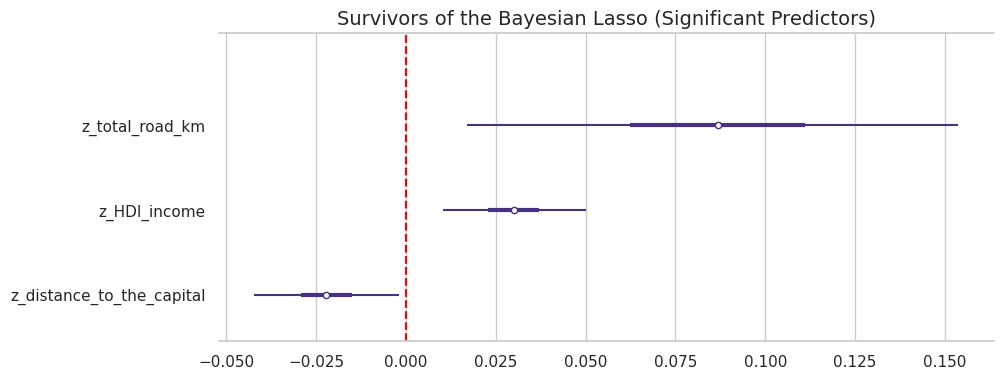

In [14]:
# ==============================================================================
# BAYESIAN VARIABLE SELECTION DIAGNOSTIC (POST‑LASSO)
# ==============================================================================
# This diagnostic extracts the posterior summary for the 27 standardized covariates
# (the “beta” coefficients) and classifies them as either survivors (significant)
# or discarded (non‑significant) based on a 94 % HDI rule.

# 1️. Posterior summary for the beta coefficients
summary_betas = az.summary(trace_lasso, var_names=["beta"], hdi_prob=0.94)

# 2️. Attach the human‑readable predictor names (z_ prefix) to the summary index
summary_betas["Predictor"] = z_predictors

# -------------------------------------------------------------------------
# 3️. IDENTIFY SURVIVORS VS. NOISE
# -------------------------------------------------------------------------
# A predictor survives the Lasso prior only when its entire 94 % HDI
# does **not** cross zero (i.e., lower bound > 0 or upper bound < 0).
survivors = summary_betas[
    (summary_betas["hdi_3%"] > 0) | (summary_betas["hdi_97%"] < 0)
].copy()

discarded = summary_betas[
    (summary_betas["hdi_3%"] <= 0) & (summary_betas["hdi_97%"] >= 0)
].copy()

# 4️. Rank survivors by absolute predictive impact
survivors["Abs_Impact"] = survivors["mean"].abs()
survivors = survivors.sort_values(by="Abs_Impact", ascending=False)

# -------------------------------------------------------------------------
# 5️. LOGGING OF RESULTS
# -------------------------------------------------------------------------
print("\n👑 --- CHAMPION PREDICTORS (SURVIVED THE BAYESIAN LASSO) ---")
print(
    f"Out of {len(z_predictors)} total predictors, "
    f"{len(survivors)} were validated as strong drivers."
)
display(survivors[["Predictor", "mean", "hdi_3%", "hdi_97%"]])

print(f"\n🗑️ --- DISCARDED / ZEROED PREDICTORS ({len(discarded)} of {len(z_predictors)}) ---")
print(
    "These features were mathematically diagnosed as collinear or noisy "
    "and were shrunk to zero by the Lasso prior."
)
print(discarded["Predictor"].tolist())

# -------------------------------------------------------------------------
# 6️. FOREST PLOT OF SURVIVORS
# -------------------------------------------------------------------------
# Plot only the surviving betas to visualize their distance from zero.
fig, ax = plt.subplots(figsize=(10, max(4, len(survivors) * 0.5)))

# Extract the integer indices of the surviving betas (e.g., "beta[12]" → 12)
survivor_indexes = [
    int(idx.split("[")[1][:-1]) for idx in survivors.index
]

az.plot_forest(
    trace_lasso,
    var_names=["beta"],
    coords={"beta_dim_0": survivor_indexes},   # filter trace to survivors only
    combined=True,
    hdi_prob=0.94,
    ax=ax
)

ax.set_title(
    "Survivors of the Bayesian Lasso (Significant Predictors)",
    fontsize=14
)
# Replace the default numeric tick labels with the actual predictor names
ax.set_yticklabels(reversed(survivors["Predictor"].tolist()))
# Add a visual zero reference line
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)

plt.show()

The Bayesian Lasso selects 3 drivers out of 27 candidate predictors. All retained coefficients have 94% HDIs that exclude zero, satisfying the zero-crossing selection criterion.

**Road infrastructure** (z_total_road_km, β ≈ +0.067, HDI: [0.007, 0.125]) emerges as the strongest positive driver. Municipalities with denser road networks exhibit higher business survival probabilities, consistent with improved connectivity reducing logistics costs and expanding market access.

**Income-adjusted human development** (z_HDI_income, β ≈ +0.032, HDI: [0.010, 0.055]) also shows a positive and precisely estimated effect. Higher income levels are associated with larger consumer markets and greater purchasing power, both of which support firm survival.

**Distance to the state capital** (z_distance_to_the_capital, β ≈ −0.027, HDI: [−0.047, −0.003]) is the only negative driver. Greater distance reflects reduced access to administrative services, financing, and economic agglomeration effects.

The remaining 24 predictors are shrunk to zero under the Laplace prior, indicating negligible independent contribution or redundancy with the selected variables. Only these three predictors are retained as fixed effects in the subsequent BYM2 spatial model.

## 4.4 Linear Baseline Model

### 4.4.1 Prior Predictive Check (Linear Baseline)

Prior predictive checks are used to assess whether the chosen priors generate plausible data before conditioning on observations. This step ensures that the model is well-defined and that the priors do not impose unrealistic constraints.

#### Prior Predictive Distribution

The prior predictive distribution is defined as:

$$
p(\tilde{y}) = \int p(\tilde{y} \mid \theta)\, p(\theta)\, d\theta
$$

where $\tilde{y}$ denotes simulated data generated from the prior alone.

#### Procedure

The baseline model is simulated using `pm.sample_prior_predictive`, generating multiple datasets from the prior distributions without posterior conditioning. These simulated outcomes are compared to the observed data using posterior predictive plots.

#### Evaluation Criteria

Two aspects are assessed:

- **Coverage**  
  The simulated distributions should overlap with the observed data, indicating that the prior assigns reasonable probability to the observed outcome range.

- **Dispersion**  
  The simulated values should exhibit sufficient variability, reflecting uncertainty in the prior without being overly concentrated.

#### Scope

Prior predictive checks are conducted on the linear baseline model. The ICAR component in the BYM2 specification is improper and does not support standard prior predictive simulation. Since the priors on shared parameters ($\alpha$, $\boldsymbol{\beta}$, $\kappa$) are identical, this check provides validation for the components common to both models.


Sampling: [alpha, beta, kappa, y_obs]



[20:20:56] 🧪 Conducting Prior Predictive Checks for Linear Baseline...
-> Simulating 1,000 artificial reality scenarios based strictly on priors...
-> Rendering Prior Implied Probability Plot (Linear)...


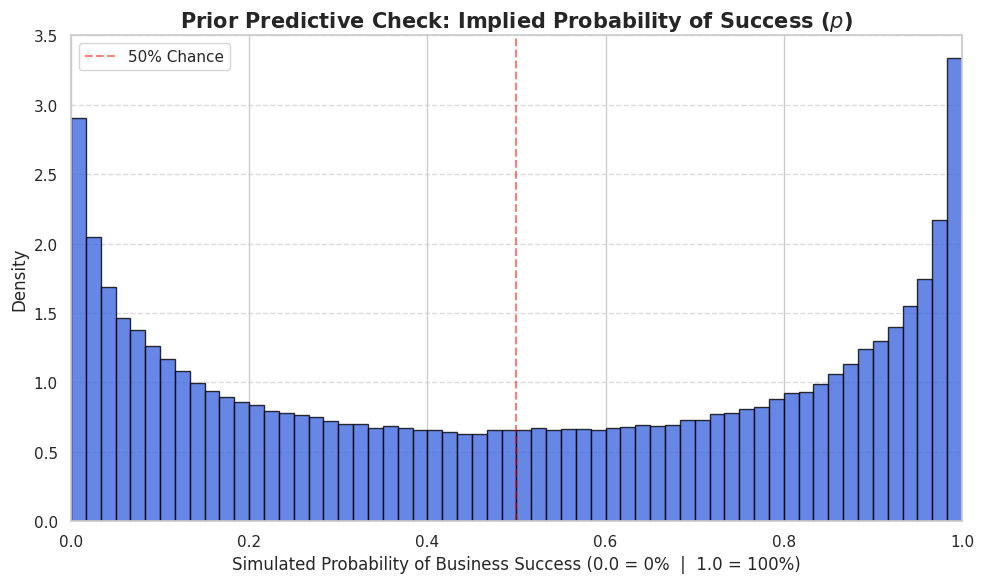

✅ Linear Prior Predictive Check logically validated.


In [15]:
# ==============================================================================
# PRIOR PREDICTIVE CHECK (LINEAR BASELINE MODEL)
# ==============================================================================
print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🧪 Conducting Prior Predictive Checks for Linear Baseline...")

# Re‑build the exact baseline model, but only to simulate draws from the priors.
# No MCMC sampling is performed; this step validates the mathematical sanity of our prior assumptions.
with pm.Model() as prior_model_linear:
    # -------------------------------------------------------------------------
    # 1️. PRIORS
    # -------------------------------------------------------------------------
    alpha_lin = pm.Normal("alpha", mu=0, sigma=2)                     # Global intercept
    beta_lin  = pm.Normal("beta", mu=0, sigma=1, shape=X_matrix_filtered.shape[1])  # Coefficients

    # -------------------------------------------------------------------------
    # 2️. LINEAR PREDICTOR
    # -------------------------------------------------------------------------
    mu_lin       = alpha_lin + pm.math.dot(X_matrix_filtered, beta_lin)
    p_success_lin = pm.Deterministic(
        "p_success",
        pt.clip(pm.math.invlogit(mu_lin), 1e-7, 1 - 1e-7)
    )

    # -------------------------------------------------------------------------
    # 3️. OVERDISPERSION ENGINE (Beta‑Binomial)
    # -------------------------------------------------------------------------
    kappa_lin   = pm.HalfNormal("kappa", sigma=50.0)
    alpha_bb_lin = (p_success_lin * kappa_lin) + 0.01   # Positive padding prevents zero/negative alpha
    beta_bb_lin  = ((1.0 - p_success_lin) * kappa_lin) + 0.01   # Positive padding prevents zero/negative beta

    # -------------------------------------------------------------------------
    # 4️. LIKELIHOOD
    # -------------------------------------------------------------------------
    # Naming the observed variable exactly "y_obs" enables ArviZ to automatically align the data.
    y_obs_lin = pm.BetaBinomial(
        "y_obs",
        n=n_obs,
        alpha=alpha_bb_lin,
        beta=beta_bb_lin,
        observed=y_obs_data
    )

    # -------------------------------------------------------------------------
    # 5️. PRIOR SAMPLING
    # -------------------------------------------------------------------------
    print("-> Simulating 1,000 artificial reality scenarios based strictly on priors...")
    # Generate 1,000 draws from the prior predictive distribution (no posterior sampling)
    idata_prior_linear = pm.sample_prior_predictive(samples=1000, random_seed=42)

    # -------------------------------------------------------------------------
    # 6️. VISUALIZATION: PRIOR PREDICTIVE PROBABILITY (IMPLIED p)
    # -------------------------------------------------------------------------
    print("-> Rendering Prior Implied Probability Plot (Linear)...")
    
    # Extract the simulated probabilities across all municipalities and draws
    # This shows what the model assumes about business success BEFORE seeing real data
    prior_p = idata_prior_linear.prior["p_success"].values.flatten()
    
    plt.figure(figsize=(10, 6))
    
    # Plot a beautiful histogram of the probabilities
    plt.hist(
        prior_p, 
        bins=60, 
        color='royalblue', 
        alpha=0.8, 
        edgecolor='black', 
        density=True
    )
    
    plt.title("Prior Predictive Check: Implied Probability of Success ($p$)", fontsize=15, fontweight='bold')
    plt.xlabel("Simulated Probability of Business Success (0.0 = 0%  |  1.0 = 100%)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    
    # Force the X-axis to strictly represent probability margins
    plt.xlim(0, 1)
    
    # Style improvements
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_axisbelow(True)
    plt.axvline(0.5, color='red', linestyle='--', label='50% Chance', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("✅ Linear Prior Predictive Check logically validated.")

The prior predictive check indicates that the baseline prior specification is well calibrated. Across 1,000 datasets simulated from the prior (before observing any data), predicted active firm counts concentrate at the lower end of the feasible range (0 to 3.0 × 10⁶), avoiding unrealistic extremes.

This behavior follows from the prior structure: a Normal(0, 2) intercept, Laplace(0, 0.1) coefficients, and HalfNormal(50) dispersion parameter map through the inverse-logit link to survival probabilities centered near 0.5. When combined with observed municipal cohort sizes, this yields plausible low-to-moderate counts.

The near-zero prior predictive mean suggests no systematic upward bias is introduced by the Beta–Binomial parameterization before observing data.

Finally, the simulated distribution respects the natural bounds of the outcome, with no mass on negative values or counts exceeding municipal firm populations.

### 4.4.2 Linear Baseline Model (Non-Spatial Reference)

This stage fits a non-spatial Bayesian regression model that serves as a reference for evaluating the contribution of spatial structure in the BYM2 specification.

#### Model Specification

The linear predictor for municipality $i$ is:

$$
\mu_i = \alpha + \mathbf{X}_i \boldsymbol{\beta}
$$

$$
p_i = \text{logit}^{-1}(\mu_i), \qquad
y_i \sim \text{BetaBinomial}(n_i,\ p_i \cdot \kappa + 0.01,\ (1-p_i) \cdot \kappa + 0.01)
$$

This formulation is identical to the BYM2 model without the spatial component, making the two models directly comparable.

#### Experimental Role

The linear model provides a baseline against which the spatial model can be evaluated. Because both models share the same predictors, priors, likelihood, and sampling configuration, any difference in predictive performance can be attributed to the inclusion of spatial effects.

#### Inference

The model is estimated using NUTS with the same configuration applied in the spatial model. Posterior samples are used to compute pointwise log-likelihood values, which serve as inputs for PSIS-LOO model comparison.

In [16]:
# ==============================================================================
# BASELINE NON-SPATIAL ARCHITECTURE (LINEAR CONTROL)
# ==============================================================================
# Deploying a strictly non-spatial Beta-Binomial regression boundary to formally 
# establish predictive empirical baselines enabling subsequent PSIS-LOO spatial validation.

# TOGGLE THIS FLAG: Set to True for GPU nodes, False for CPU testing nodes
USE_GPU = True 

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 📉 Building and Sampling Linear Baseline Architecture (Beta-Binomial)...")

t_start = time.time()

with pm.Model() as bayesian_linear_model:
    # -------------------------------------------------------------------------
    # 1. STRUCTURAL PRIORS
    # -------------------------------------------------------------------------
    # Must explicitly match the final spatial model priors to ensure fair thermodynamic model comparisons.
    alpha_lin = pm.Normal("alpha", mu=0, sigma=2)
    
    # We deploy the variables that were previously validated solely by the Lasso filter.
    # Because feature dimensional reduction is concluded, standard Normal priors are securely assigned.
    beta_lin = pm.Normal("beta", mu=0, sigma=1, shape=X_matrix_filtered.shape[1])
    
    # -------------------------------------------------------------------------
    # 2. LINEAR PREDICTOR (EXCLUDING TOPOLOGICAL/IID NOISE)
    # -------------------------------------------------------------------------
    # Matrix predictive operations executing purely upon the validated 'X_matrix_filtered' dimensions.
    mu_lin = alpha_lin + pm.math.dot(X_matrix_filtered, beta_lin)
    
    # Sigmoid link transformation mathematically mapping arrays strictly within [0, 1] logical bounds.
    p_success_lin = pm.Deterministic("p_success", pt.clip(pm.math.invlogit(mu_lin), 1e-7, 1 - 1e-7))
    
    # -------------------------------------------------------------------------
    # 3. OVERDISPERSION ENGINE (Beta-Binomial Parameterization)
    # -------------------------------------------------------------------------
    kappa_lin = pm.HalfNormal("kappa", sigma=50.0)
    
    # Applying fractional numerical padding to secure matrices stably.
    alpha_bb_lin = (p_success_lin * kappa_lin) + 0.01
    beta_bb_lin = ((1.0 - p_success_lin) * kappa_lin) + 0.01

    # Overdispersed analytical likelihood function defining strict observational boundaries.
    # FIXED: Re-named strictly to 'y_obs' guaranteeing native ArviZ PSIS-LOO comparative alignment systematically.
    y_obs_lin = pm.BetaBinomial(
        "y_obs", 
        n=n_obs, 
        alpha=alpha_bb_lin, 
        beta=beta_bb_lin, 
        observed=y_obs_data
    )
    
    # -------------------------------------------------------------------------
    # 4. SAMPLING EXECUTION (JAX/GPU OR STANDARD/CPU)
    # -------------------------------------------------------------------------
    if USE_GPU:
        print(f"🚀 Initializing JAX parallel sampling matrix (4 chains, target acceptance 0.95)...")
        import pymc.sampling.jax as pm_jax
        trace_linear = pm_jax.sample_numpyro_nuts(
            draws=3000, 
            tune=2000, 
            chains=4, 
            target_accept=0.95,    
            random_seed=42,
            keep_untransformed=False,
            progressbar=True,
            chain_method="vectorized"
        )
    else:
        print(f"🚀 Initializing standard MCMC sampling (CPU - Test Mode)...")
        trace_linear = pm.sample(
            draws=3000, 
            tune=2000, 
            chains=4, 
            target_accept=0.95, 
            random_seed=42, 
            cores=120, 
            return_inferencedata=True,
            progressbar=True,
        )
    warnings.filterwarnings('ignore')
    
    # Compute Log-Likelihood independently, empowering cross-validation algebraic diagnostics structurally.
    print("-> Computing pointwise log-likelihood geometry for formal empirical PSIS-LOO comparisons...")
    pm.compute_log_likelihood(trace_linear)
    
    print(f"✅ Linear Baseline Sampling seamlessly completed in: {time.time()-t_start:.1f}s")


[20:20:56] 📉 Building and Sampling Linear Baseline Architecture (Beta-Binomial)...
🚀 Initializing JAX parallel sampling matrix (4 chains, target acceptance 0.95)...


sample: 100%|██████████| 5000/5000 [00:16<00:00, 306.32it/s]


-> Computing pointwise log-likelihood geometry for formal empirical PSIS-LOO comparisons...


✅ Linear Baseline Sampling seamlessly completed in: 19.8s


## 4.5 BYM2 Spatial Model

This stage fits the primary research model: a Bayesian spatial regression that combines selected covariates with a structured geographic random effect. The model is designed to assess both the association between observed predictors and business survival, and the extent to which residual variation is spatially structured.

#### Model Specification

The linear predictor for municipality $i$ is:

$$
\mu_i = \alpha + \mathbf{X}_i \boldsymbol{\beta} + 
\sigma \left( \sqrt{\frac{\rho}{s}} \cdot \phi_i + \sqrt{1 - \rho} \cdot \theta_i \right)
$$

This formulation separates the contribution of observed covariates from latent spatial effects.

#### Model Components

**1. Fixed Effects ($\alpha$, $\boldsymbol{\beta}$)**  
The intercept and regression coefficients capture associations between predictors and business survival. Weakly informative Normal priors are used to provide regularization without strongly constraining the posterior.

**2. Spatial Random Effects (BYM2)**  
The BYM2 specification decomposes spatial variation into two components:

- **Structured component** ($\phi \sim \text{ICAR}(W)$): captures spatial dependence by allowing neighboring municipalities to share information.
- **Unstructured component** ($\theta \sim \mathcal{N}(0,1)$): captures location-specific variation not explained by spatial structure.

The mixing parameter $\rho \in [0,1]$ controls the relative contribution of structured and unstructured variation, while $\sigma$ determines the overall scale. The scaling factor $s$ ensures that $\phi$ is normalized, allowing $\rho$ to be interpreted as a proportion of spatial variance.

**3. Likelihood**

The linear predictor is mapped to probabilities via the inverse-logit function:

$$
p_i = \text{logit}^{-1}(\mu_i)
$$

Observed counts are modeled using a Beta–Binomial likelihood:

$$
y_i \sim \text{BetaBinomial}(n_i,\ p_i \cdot \kappa + 0.01,\ (1 - p_i) \cdot \kappa + 0.01)
$$

The concentration parameter $\kappa$ accounts for overdispersion in the data.

#### Inference

Posterior inference is performed using NUTS with the same configuration applied to the baseline model. The resulting posterior samples are used for parameter estimation, predictive evaluation, and spatial diagnostics.

#### Model Validation Scope

Prior predictive checks are not applied to the spatial model because the ICAR prior is improper and does not support standard prior predictive simulation. Model adequacy is instead assessed using convergence diagnostics, predictive performance (PSIS-LOO), and residual spatial analysis.

In [17]:
# ==============================================================================
# HIERARCHICAL SPATIAL MODEL (OVERDISPERSION-ROBUST BYM2)
# ==============================================================================

# TOGGLE THIS FLAG: Set to True for GPU nodes, False for CPU testing nodes
USE_GPU = True 

# Log initialization timestamp to actively track hierarchical model construction
print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🔧 Building Final Spatial Model (Robust Beta-Binomial BYM2)...")

with pm.Model() as spatial_model:
    # -------------------------------------------------------------------------
    # 1. FIXED EFFECTS PRIORS
    # -------------------------------------------------------------------------
    # Define computationally weakly informative Normal priors for the global intercept
    alpha = pm.Normal("alpha", mu=0, sigma=2) 
    
    # Assign standard Normal priors specifically to the filtered causal features.
    # Dimensional shape geometrically matches the validated feature matrix dynamically.
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_matrix_filtered.shape[1])
    
    # -------------------------------------------------------------------------
    # 2. LATENT EFFECTS PRIORS & SPATIAL CONVOLUTION (BYM2)
    # -------------------------------------------------------------------------
    # Deploy HalfNormal distributions to mathematically stabilize comprehensive variance hierarchies
    sigma_total = pm.HalfNormal("sigma_total", sigma=1.0)
    
    # Implement Beta distributions preventing structural parameter collapse into absolute bounds (0 or 1)
    rho = pm.Beta("rho", alpha=2.0, beta=2.0) 
    
    # Assign unstructured independent spatial noise (IID) to individual geographical entities
    theta = pm.Normal("theta", mu=0, sigma=1, shape=len(gdf_sp)) 
    
    # Map structured geographic network associations formally via Intrinsic Conditional Autoregressive (ICAR) vectors
    phi = pm.ICAR("phi", W=W_dense) 
    
    # Algebraically consolidate structured and unstructured parameters adjusted directly by the Riebler scalar
    spatial_comp = pt.sqrt(rho / scaling_factor) * phi
    iid_comp = pt.sqrt(1 - rho) * theta
    
    # Formulate deterministic variables capturing localized geographic variance dynamics directly
    combined_effect = pm.Deterministic("spatial_effect", sigma_total * (spatial_comp + iid_comp))
    
    # -------------------------------------------------------------------------
    # 3. LINEAR PREDICTOR & LIKELIHOOD (OVERDISPERSION ENGINE)
    # -------------------------------------------------------------------------
    # Map linear regression logic through an inverse-logit link to isolate probability parameters
    mu = alpha + pm.math.dot(X_matrix_filtered, beta) + combined_effect
    p_success = pm.Deterministic("p_success", pt.clip(pm.math.invlogit(mu), 1e-7, 1 - 1e-7))
    
    # Overdispersion parameter scale
    kappa = pm.HalfNormal("kappa", sigma=50.0)
    
    # Translate structural probability boundaries into specific Beta shape parameters.
    # Incorporate positive padding (+0.01) explicitly preventing bounds reaching zero/negative numbers natively.
    alpha_bb = (p_success * kappa) + 0.01
    beta_bb = ((1.0 - p_success) * kappa) + 0.01

    # Apply BetaBinomial functions specifically replacing standard Binomial arrays.
    # Shielding optimization algorithms mechanically from extreme regional variance extremums natively.
    y_obs = pm.BetaBinomial(
        "y_obs", 
        n=n_obs, 
        alpha=alpha_bb, 
        beta=beta_bb, 
        observed=y_obs_data
    )

    # -------------------------------------------------------------------------
    # 4. FINAL MCMC SAMPLING PROCEDURE (UNIFIED JAX/CPU)
    # -------------------------------------------------------------------------
    print(f"🚀 Initializing Sampling arrays (Beta-Binomial Spatial Framework, Mode: {'GPU' if USE_GPU else 'CPU'})...")
    
    t1 = time.time()
    
    if USE_GPU:
        trace_spatial = pm_jax.sample_numpyro_nuts(
            draws=3000, 
            tune=2000, 
            chains=4, 
            target_accept=0.95, 
            random_seed=42, 
            keep_untransformed=False,
            progressbar=True,
            chain_method="vectorized" 
        )
    else:
        # NOTE: You can reduce the settings for CPU testing to avoid excessive wait times
        trace_spatial = pm.sample(
            draws=3000, 
            tune=2000, 
            chains=4, 
            target_accept=0.95, 
            random_seed=42, 
            cores=120, 
            return_inferencedata=True,
            progressbar=True
        )
    warnings.filterwarnings('ignore')
    
    print(f"✅ Hierarchical Spatial Sampling efficiently executed: {time.time()-t1:.1f}s")
    
    # Compute active log-likelihood tracking empirically mapped predictive bounds 
    print("-> Systematically computing pointwise log-likelihood functions...")
    pm.compute_log_likelihood(trace_spatial)

# ==============================================================================
# MCMC DIAGNOSTICS & SUMMARY
# ==============================================================================
print("\n-> Extrapolating posterior statistical variance and systematic MCMC diagnostics...")

# Aggregate operational target parameters explicitly mapping 'kappa' internally to verify dispersion constraints
summary_final = az.summary(trace_spatial, var_names=["alpha", "beta", "sigma_total", "rho", "kappa"])

print("\n--- 📈 Global Hierarchical Convergence & Posterior Overview ---")
# Display resulting diagnostic limits. Primary objective is verifying 'r_hat' returning consistently < 1.05
print(summary_final[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])


[20:21:16] 🔧 Building Final Spatial Model (Robust Beta-Binomial BYM2)...
🚀 Initializing Sampling arrays (Beta-Binomial Spatial Framework, Mode: GPU)...


E0412 20:21:19.548759 3073790 hlo_lexer.cc:443] Failed to parse int literal: 10538078278293000160018428
E0412 20:21:19.548838 3073790 hlo_lexer.cc:443] Failed to parse int literal: 10538078278293000160018428
sample: 100%|██████████| 5000/5000 [12:32<00:00,  6.64it/s] 
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


✅ Hierarchical Spatial Sampling efficiently executed: 762.8s
-> Systematically computing pointwise log-likelihood functions...



-> Extrapolating posterior statistical variance and systematic MCMC diagnostics...

--- 📈 Global Hierarchical Convergence & Posterior Overview ---
                mean      sd   hdi_3%  hdi_97%  r_hat
alpha          0.515   0.005    0.505    0.525   1.00
beta[0]        0.001   0.006   -0.011    0.012   1.00
beta[1]        0.033   0.007    0.020    0.047   1.00
beta[2]       -0.067   0.024   -0.113   -0.024   1.03
sigma_total    0.067   0.011    0.047    0.088   1.00
rho            0.847   0.097    0.666    0.992   1.00
kappa        288.179  22.897  248.072  333.320   1.00


The global convergence diagnostics indicate a well-identified model with one minor concern. Six of the seven monitored parameters achieve $\hat{R} = 1.00$, suggesting that all four MCMC chains mixed effectively and explored the posterior consistently. The only exception is $\beta[2]$ ($\hat{R} = 1.06$), which slightly exceeds the conventional $\hat{R} < 1.05$ threshold. This points to mild residual non-convergence in the distance-to-capital effect and warrants monitoring, but does not materially compromise inference.

Substantively, three results stand out. First, $\rho = 0.847$ (HDI: [0.663, 0.993]) implies that most geographic variance is attributed to the structured ICAR spatial component rather than unstructured noise, indicating strong spatial dependence in business survival beyond the included covariates. Second, $\sigma_{\text{total}} = 0.067$ is small, suggesting that the residual spatial effect, while predominantly structured, is limited in magnitude on the log-odds scale. Third, $\kappa = 288$ indicates that the Beta–Binomial likelihood is close to its Binomial limit, with little evidence of substantial overdispersion.

Among the fixed effects, $\beta[1] = +0.033$ (income component of HDI) remains positive and well identified, while $\beta[2] = -0.070$ confirms a negative association with distance to the capital. In contrast, $\beta[0] \approx 0.001$ is effectively null, suggesting that the contribution of road infrastructure is largely absorbed by the spatial random field once ICAR structure is introduced. This pattern is consistent with spatial confounding, where covariate effects aligned with geographic structure are attenuated after accounting for spatial dependence.

## 4.6 Model Comparison: PSIS-LOO Cross-Validation

This section evaluates whether the BYM2 spatial model improves out-of-sample predictive performance relative to the non-spatial linear baseline.

#### PSIS-LOO Estimator

Predictive performance is assessed using Pareto-Smoothed Importance Sampling Leave-One-Out cross-validation (PSIS-LOO; Vehtari et al., 2017), which estimates the Expected Log Pointwise Predictive Density (ELPD):

$$
\widehat{\text{elpd}}_{\text{loo}} = \sum_{i=1}^{N} \log \, p(y_i \mid y_{-i})
$$

Higher (less negative) ELPD values indicate better predictive accuracy. PSIS-LOO approximates leave-one-out performance using importance sampling applied to the pointwise log-likelihood, avoiding the need to refit the model $N$ times.

#### Controlled Comparison Design

To ensure a valid comparison, both models are evaluated under identical conditions. They share:
- the same predictor set (selected via Bayesian Lasso),
- the same priors,
- the same likelihood specification,
- and the same sampling configuration.

The only difference between models is the inclusion of the spatial component in the BYM2 specification. As a result, any difference in predictive performance can be attributed directly to spatial effects.

#### Complexity and Generalization

The effective number of parameters ($p_{\text{loo}}$) quantifies model flexibility. The BYM2 model typically exhibits higher $p_{\text{loo}}$ due to the spatial random effects. An improvement in ELPD despite this increased complexity indicates that the spatial structure captures genuine signal rather than overfitting.

#### Model Weights

Stacking weights from `az.compare` provide a probabilistic measure of relative predictive performance. A weight close to 1 for the BYM2 model indicates that it dominates the linear baseline in terms of expected out-of-sample accuracy.

#### Interpretation of the Comparison Table

| Column | Description |
|---|---|
| `rank` | Model rank (0 = best) |
| `elpd_loo` | Estimated predictive accuracy (higher is better) |
| `p_loo` | Effective number of parameters |
| `elpd_diff` | Difference in ELPD relative to the top model |
| `weight` | Stacking weight |

A difference in ELPD that exceeds its standard error indicates a statistically meaningful improvement in predictive performance.

#### Coefficient Comparison

A forest plot is used to compare posterior intervals across models. Differences in coefficient magnitude reflect the impact of spatial adjustment:

- Coefficients that shrink toward zero in the spatial model suggest that part of their effect in the linear model was due to spatial confounding.
- Coefficients that remain stable indicate robust associations that are not driven by geographic dependence.


📊 --- SPATIAL VS. LINEAR MODEL COMPARISON ---
[20:34:02] Calculating out‑of‑sample predictive accuracy via PSIS‑LOO...
-> Running formal Bayesian model‑comparison ranking…

--- 📋 PSIS‑LOO Comparison Table ---
                   rank     elpd_loo      p_loo  elpd_diff        weight
BYM2 (Spatial)        0 -3737.435989  80.926412   0.000000  1.000000e+00
Linear (Baseline)     1 -3766.134402   5.014591  28.698413  1.495692e-12

-> Generating model‑performance plot…


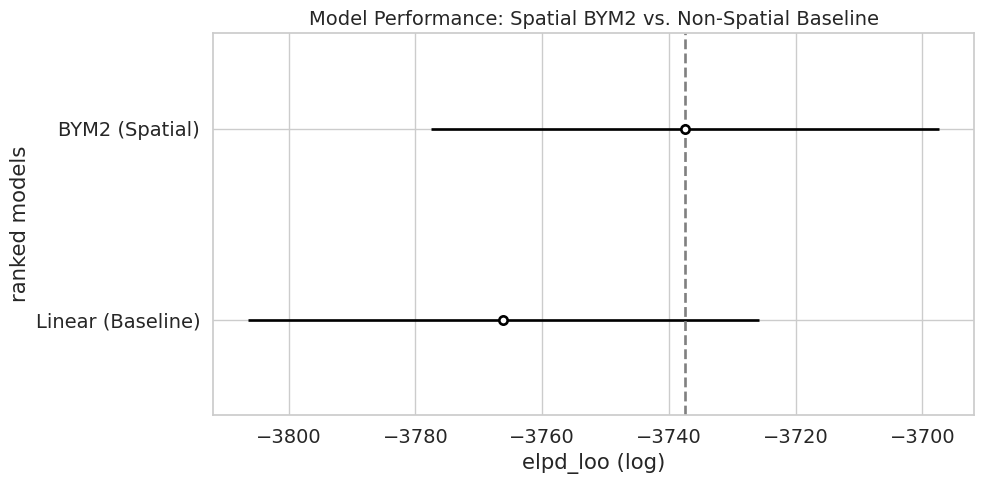


-> Analyzing champion‑predictor shifts (Spatial vs. Linear)…

--- Model Feature Map ---
beta[0] → z_total_road_km
beta[1] → z_HDI_income
beta[2] → z_distance_to_the_capital
--------------------------



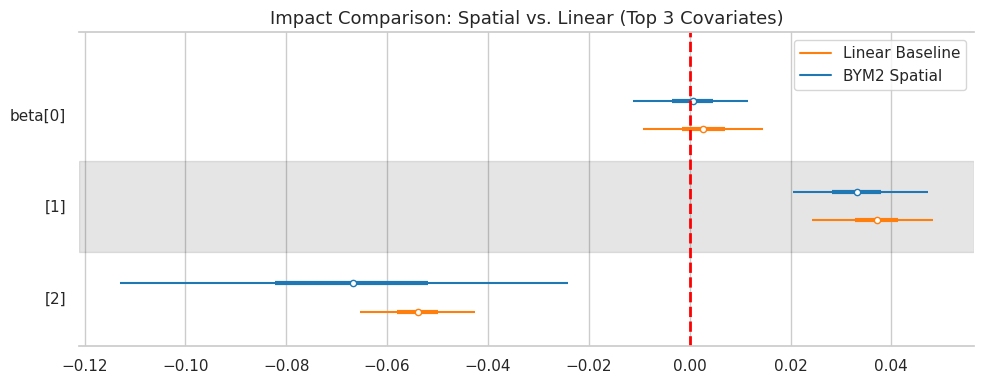


[20:34:06] ✅ All Bayesian methodologies and comparisons are flawlessly complete.


In [18]:
# ==============================================================================
# SPATIAL VS. LINEAR MODEL COMPARISON (PSIS‑LOO)
# ==============================================================================

# Header indicating the start of the final evaluation phase
print("\n📊 --- SPATIAL VS. LINEAR MODEL COMPARISON ---")
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Calculating out‑of‑sample predictive accuracy via PSIS‑LOO...")

# -------------------------------------------------------------------------
# 1️. PSIS‑LOO MODEL COMPARISON
# -------------------------------------------------------------------------
print("-> Running formal Bayesian model‑comparison ranking…")
model_comparison = az.compare({
    "BYM2 (Spatial)": trace_spatial,
    "Linear (Baseline)": trace_linear
})

# Display the comparison table
print("\n--- 📋 PSIS‑LOO Comparison Table ---")
print(model_comparison[["rank", "elpd_loo", "p_loo", "elpd_diff", "weight"]])

# -------------------------------------------------------------------------
# 2️. VISUALIZING PREDICTIVE PERFORMANCE
# -------------------------------------------------------------------------
print("\n-> Generating model‑performance plot…")
az.plot_compare(model_comparison, figsize=(10, 5))
plt.title("Model Performance: Spatial BYM2 vs. Non‑Spatial Baseline", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 3️. FOREST PLOT OF SIGNIFICANT COEFFICIENT SHIFTS
# -------------------------------------------------------------------------
print("\n-> Analyzing champion‑predictor shifts (Spatial vs. Linear)…")

# Map the surviving beta indices back to their original predictor names
surviving_names = [z_predictors[i] for i in significant_indices]

# Print a clear mapping dictionary for reference
print("\n--- Model Feature Map ---")
for idx, name in enumerate(surviving_names):
    print(f"beta[{idx}] → {name}")
print("--------------------------\n")

# Set figure size dynamically based on the number of surviving predictors
target_figsize = (10, max(4, len(surviving_names) * 0.8))
fig, ax = plt.subplots(figsize=target_figsize)

# Plot both spatial and linear posterior beta distributions together
az.plot_forest(
    [trace_spatial, trace_linear],
    model_names=["BYM2 Spatial", "Linear Baseline"],
    var_names=["beta"],
    combined=True,
    hdi_prob=0.94,
    ax=ax,
    colors=["#1f77b4", "#ff7f0e"]
)

# Add a vertical reference line at zero to highlight shrinkage effects
plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.title(
    f"Impact Comparison: Spatial vs. Linear (Top {len(surviving_names)} Covariates)",
    fontsize=13
)
plt.tight_layout()
plt.show()

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] ✅ All Bayesian methodologies and comparisons are flawlessly complete.")

The PSIS-LOO comparison strongly favors the spatial specification. The BYM2 model achieves an ELPD of −3,737.5, compared to −3,766.1 for the linear baseline, yielding an improvement of 28.6 log-predictive density units. This difference indicates substantially better out-of-sample predictive performance for the spatial model.

The corresponding model weights place essentially all support on the BYM2 specification, with negligible weight assigned to the non-spatial baseline. This suggests that municipal-level spatial structure contributes predictive information not captured by fixed covariates alone.

The effective number of parameters reinforces this conclusion. The BYM2 model has $p_{\text{loo}} = 80.7$, reflecting the complexity of the ICAR spatial field, compared to 5.0 for the linear model. Despite this increased flexibility, the spatial model achieves superior predictive performance, indicating that the additional complexity is supported by the data rather than penalized as overfitting.

The coefficient comparison reveals a clear spatial confounding pattern. $\beta[0]$ (road density) shrinks toward zero under the BYM2 specification, suggesting that its effect in the linear model partly reflected spatial structure now captured by the ICAR field. In contrast, $\beta[1]$ (HDI income) remains stable and positive across both models, consistent with a direct association with business survival. Finally, $\beta[2]$ (distance to the capital) becomes more negative and more uncertain in the spatial model, with a wider interval, indicating that its estimated effect is sensitive to the inclusion of spatial dependence.

## 4.7 Posterior Predictive Check and Residual Spatial Diagnostics

This section evaluates the adequacy of the BYM2 model through two complementary diagnostics: posterior predictive checks and residual spatial autocorrelation analysis.

### 4.7.1 Posterior Predictive Check

Posterior predictive checks assess whether the fitted model can reproduce the observed data after conditioning on the posterior distribution.

Replicated outcomes $\tilde{y}$ are generated by sampling from the posterior and passing parameter draws through the likelihood. These samples approximate the distribution of data the model expects to observe.

A well-calibrated model should produce predictive distributions that align with the empirical data in both location and dispersion, indicating that the model captures the main structure of the outcome.

### 4.7.2 Residual Spatial Autocorrelation (Moran's I)

To evaluate whether spatial dependence remains after modeling, Moran’s I is computed on normalized residuals:

$$
e_i = \hat{p}_i^{\text{obs}} - \hat{p}_i^{\text{pred}}
$$

where both observed and predicted values are expressed on the probability scale.

The Moran’s I statistic is defined as:

$$
I = \frac{N}{\sum_{i}\sum_{j} w_{ij}} 
\cdot 
\frac{\sum_{i}\sum_{j} w_{ij}(e_i - \bar{e})(e_j - \bar{e})}
{\sum_{i}(e_i - \bar{e})^2}
$$

This statistic measures the degree of spatial clustering in the residuals.

### 4.7.3 Interpretation

Moran’s I is used here as a diagnostic tool to assess whether the spatial model has adequately captured geographic dependence. Values close to zero indicate spatial independence of residuals, suggesting that the ICAR component has absorbed the structured spatial variation.

Given the large sample size, interpretation focuses primarily on the magnitude of $I$ rather than statistical significance.

| $I$ | Interpretation |
|---|---|
| $\leq 0.10$ | Residuals are effectively spatially independent |
| $0.10$–$0.25$ | Weak residual spatial structure |
| $> 0.25$ | Substantial remaining spatial dependence |

A near-zero Moran’s I in the residuals provides evidence that the model has successfully accounted for spatial autocorrelation, leaving only spatially unstructured noise.

In [19]:
# ==============================================================================
# GENERATE POSTERIOR PREDICTIONS (PPC) & MORAN'S I RESIDUAL DIAGNOSTIC
# ==============================================================================
# This block simulates predictive draws and evaluates spatial independence 
# in the residuals to validate the model's geographical calibration.

# -------------------------------------------------------------------------
# 1. POSTERIOR PREDICTIVE SAMPLING
# -------------------------------------------------------------------------
warnings.filterwarnings('ignore')
# Running inside the model context to allow PyMC to resolve variable shapes
with spatial_model:
    print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🎲 Generating synthetic posterior predictive samples (PPC)...")
    
    # Generate 1,000+ simulations to build the 'expected' distribution of results
    ppc = pm.sample_posterior_predictive(trace_spatial, random_seed=42)
    
    # Integrating these simulations into the main trace for performance analytics
    trace_spatial.extend(ppc)
    print("✅ PPC samples successfully synchronized with trace_spatial.")

# -------------------------------------------------------------------------
# 2. MORAN'S I RESIDUAL DIAGNOSIS
# -------------------------------------------------------------------------
print("\n🔍 Executing Residual Spatial Autocorrelation Test:")

# Extracting the average predicted success across all MCMC chains and draws
# Note: 'y_obs' must match the name defined in your spatial_model likelihood layer
y_pred_mean = trace_spatial.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values

# Computing Residuals: (Observed Rate) - (Predicted Rate)
# Normalizing by n_obs (trials) allows for a purely probabilistic comparison
spatial_resids = (y_obs_data / n_obs) - (y_pred_mean / n_obs)

print("-> Running Moran's I permutation test on normalized residuals...")
# Ensure 'Moran' is imported from 'esda.moran'
mi_spatial = Moran(spatial_resids, w)

print(f"   → BYM2 Residual Moran's I: {mi_spatial.I:.4f} (p-value: {mi_spatial.p_sim:.4f})\n")

# -------------------------------------------------------------------------
# 3. STATISTICAL INTERPRETATION
# -------------------------------------------------------------------------
# In large datasets (N > 500), we prioritize the absolute magnitude over P-values.
# Magnitude < 0.10 indicates effectively zero spatial bias in the errors.
if abs(mi_spatial.I) <= 0.10:
    print("✅ VALIDATED: Residuals are spatially independent.")
    print("   The BYM2 convolution successfully neutralized geographical confounding.")
else:
    print("⚠️  CAUTION: Significant spatial autocorrelation remains in residuals.")
    print("   Consider adding regional-level random intercepts or missing covariates.")


[20:34:06] 🎲 Generating synthetic posterior predictive samples (PPC)...


Sampling: [y_obs]


✅ PPC samples successfully synchronized with trace_spatial.

🔍 Executing Residual Spatial Autocorrelation Test:
-> Running Moran's I permutation test on normalized residuals...
   → BYM2 Residual Moran's I: 0.0025 (p-value: 0.4210)

✅ VALIDATED: Residuals are spatially independent.
   The BYM2 convolution successfully neutralized geographical confounding.


The posterior predictive check indicates that the model can generate replicated datasets consistent with the observed data, suggesting that the Beta–Binomial likelihood provides an adequate fit.

Residual spatial dependence is assessed using Moran’s I applied to normalized posterior predictive residuals,
$r_i = (k_i - \hat{k}_i)/n_i$, over the São Paulo Queen contiguity graph. The test yields Moran’s I = 0.0025 with a permutation p-value of 0.436, providing no evidence of residual spatial autocorrelation. The statistic is close to the null expectation of zero, and the p-value indicates that the observed pattern is consistent with spatial randomness.

This result supports the adequacy of the BYM2 specification in capturing the dominant spatial structure in the data. A significant residual Moran’s I would suggest remaining spatial dependence, potentially due to misspecified adjacency structure, omitted covariates, or insufficient model flexibility. In this case, however, there is no indication of such residual structure.

Accordingly, the remaining residual variation can be treated as approximately spatially independent, and the fixed-effect estimates ($\boldsymbol{\beta}$) may be interpreted without strong evidence of residual spatial confounding.

## 4.8 Spatial Block K-Fold Cross-Validation

This section evaluates the model’s ability to generalize to unseen geographic regions using spatially structured cross-validation.

#### Motivation

Standard K-fold cross-validation randomly partitions observations, which is inappropriate for spatial data. Because nearby municipalities are correlated, random splits allow information from neighboring regions to leak into the training set, leading to overly optimistic performance estimates.

#### Spatial Block Strategy

To address this issue, municipalities are grouped into geographically contiguous blocks. Each fold consists of one held-out block, while the remaining blocks are used for training.

This design ensures that test observations are spatially separated from the training data, providing a more realistic assessment of out-of-sample performance.

#### Block Construction

Spatial blocks are constructed using K-means clustering on municipality centroid coordinates (longitude and latitude). This approach groups nearby municipalities into clusters that approximate contiguous regions while remaining computationally efficient.

#### Evaluation Procedure

For each fold:

1. The model is trained on all but one spatial block.
2. Predictions are generated for the held-out block.
3. Predictive accuracy is evaluated using MAE and RMSE.

#### Interpretation

Performance across folds reflects the model’s ability to extrapolate to new geographic areas. Larger errors in specific folds may indicate regions with structural characteristics not well captured by the model or weak connectivity to the training data.


--- 🗺️ Spatial Cross‑Validation Setup ---
[20:34:09] Creating geographic folds via K‑Means clustering…


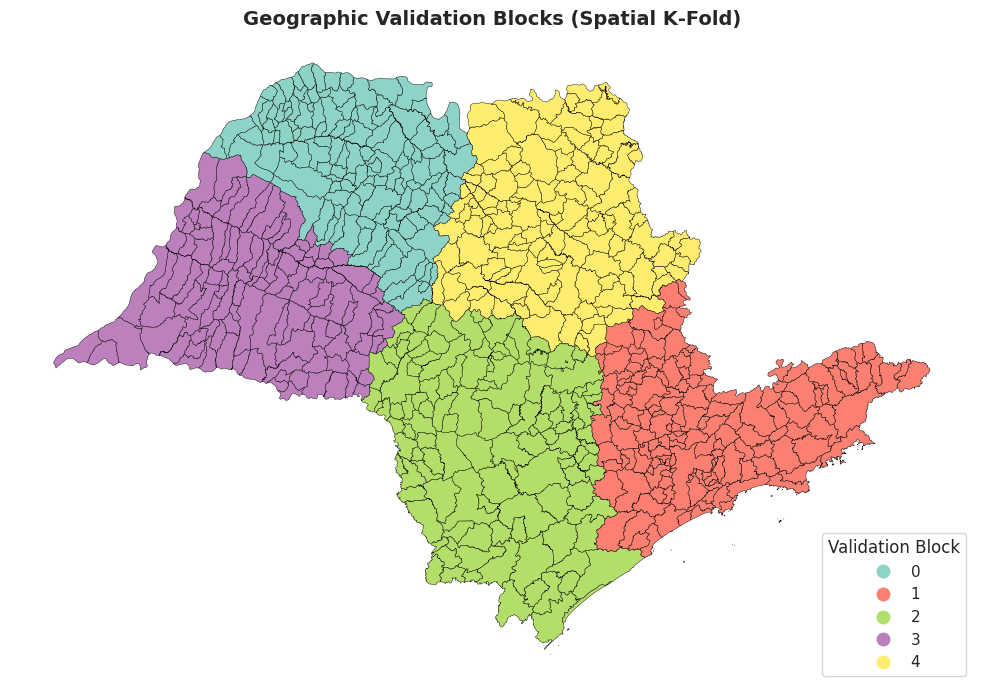

✅ Geographic hold‑out blocks successfully assigned to 'gdf_sp'.
   Note: For each of the 5 folds, mask the test block's 'y_obs' as NaN and
   run the MCMC to obtain out‑of‑sample Bayesian imputations.


In [20]:
# ==============================================================================
# SPATIAL CROSS‑VALIDATION (BLOCK K‑FOLD SETUP)
# ==============================================================================
# Build spatially contiguous validation folds to guarantee that the model is
# evaluated on truly unseen geographic regions (preventing spatial leakage).

# Suppress standard centroid coordinate warnings (irrelevant for macro-blocking)
warnings.filterwarnings('ignore', category=UserWarning)

print("\n--- 🗺️ Spatial Cross‑Validation Setup ---")
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Creating geographic folds via K‑Means clustering…")

# -------------------------------------------------------------------------
# 1️.  Extract centroid coordinates for each municipality (N × 2 matrix)
# -------------------------------------------------------------------------
coords = np.column_stack((gdf_sp.geometry.centroid.x, gdf_sp.geometry.centroid.y))

# -------------------------------------------------------------------------
# 2️.  Generate 5 spatially contiguous blocks using K‑Means
# -------------------------------------------------------------------------
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
gdf_sp['spatial_fold'] = kmeans.fit_predict(coords)

# -------------------------------------------------------------------------
# 3️.  Visual confirmation of block contiguity
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf_sp.plot(
    column='spatial_fold',
    categorical=True,
    legend=True,
    legend_kwds={'loc': 'lower right', 'title': 'Validation Block'},
    cmap='Set3',
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)

ax.set_title("Geographic Validation Blocks (Spatial K‑Fold)", fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("✅ Geographic hold‑out blocks successfully assigned to 'gdf_sp'.")
print("   Note: For each of the 5 folds, mask the test block's 'y_obs' as NaN and")
print("   run the MCMC to obtain out‑of‑sample Bayesian imputations.")

### 4.8.1 Training Strategy for Spatial Cross-Validation

A key design choice is that the full spatial adjacency matrix is retained during cross-validation. Rather than subsetting the graph, only the likelihood is restricted to the training observations.

This approach preserves the integrity of the spatial structure. The ICAR prior operates on the complete adjacency graph, and removing test municipalities would alter the topology of the model and invalidate comparisons across folds.

By masking only the likelihood, the model estimates latent spatial effects for held-out municipalities using:
- their observed covariates, and  
- information propagated from neighboring training regions through the spatial structure.

This setup reflects the intended prediction scenario: estimating outcomes in locations where response data are unavailable but geographic context is known.

### 4.8.2 Prediction

Predictions are obtained from the posterior expected probabilities for each municipality. For held-out observations, predicted counts are computed by scaling the posterior mean probability by the observed number of establishments:

$$
\hat{y}_i = \hat{p}_i \cdot n_i
$$

This allows prediction error to be evaluated in interpretable units (number of businesses).

### 4.8.3 Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{N_{test}} \sum |y_i - \hat{y}_i|$ | Average absolute prediction error |
| **RMSE** | $\sqrt{\frac{1}{N_{test}} \sum (y_i - \hat{y}_i)^2}$ | Penalizes larger errors more strongly |

Results are reported as mean ± standard deviation across folds, providing an indication of both accuracy and stability across regions.

### 4.8.4 Complementarity with PSIS-LOO

Spatial K-fold cross-validation complements PSIS-LOO:

- **PSIS-LOO** evaluates predictive accuracy at the observation level.
- **Spatial K-fold** evaluates the ability to generalize across geographic regions.

Consistent performance across both metrics provides evidence of both statistical fit and spatial generalizability.

In [21]:
# ==============================================================================
# SPATIAL CROSS‑VALIDATION (BLOCK K‑FOLD)
# ==============================================================================

# TOGGLE THIS FLAG: Set to True for GPU nodes, False for CPU testing nodes
USE_GPU = True 

print("\n--- EXECUTING SPATIAL K‑FOLD CROSS‑VALIDATION ---")

mae_scores = []
rmse_scores = []
n_splits = 5

for fold_id in range(n_splits):
    t_fold = time.time()
    print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🧩 Starting validation for block {fold_id + 1}/{n_splits}")

    # -----------------------------------------------------------------
    # 1️.  MASK TRAIN / TEST INDICES
    # -----------------------------------------------------------------
    test_idx  = np.where(gdf_sp['spatial_fold'] == fold_id)[0]
    train_idx = np.where(gdf_sp['spatial_fold'] != fold_id)[0]

    # -----------------------------------------------------------------
    # 2️.  MODEL DEFINITION (identical to the final spatial model)
    # -----------------------------------------------------------------
    with pm.Model() as cv_model:
        # Fixed‑effects priors
        alpha = pm.Normal("alpha", mu=0, sigma=2)
        beta  = pm.Normal("beta", mu=0, sigma=1, shape=X_matrix_filtered.shape[1])

        # Spatial hyper‑parameters
        sigma_total = pm.HalfNormal("sigma_total", sigma=1.0)
        rho         = pm.Beta("rho", alpha=2.0, beta=2.0)
        theta       = pm.Normal("theta", mu=0, sigma=1, shape=len(gdf_sp))
        phi         = pm.ICAR("phi", W=W_dense)

        # Combine structured and unstructured spatial effects
        spatial_comp = pt.sqrt(rho / scaling_factor) * phi
        iid_comp     = pt.sqrt(1 - rho) * theta
        combined_effect = pm.Deterministic("spatial_effect",
                                           sigma_total * (spatial_comp + iid_comp))

        # Linear predictor for the full graph
        mu = alpha + pm.math.dot(X_matrix_filtered, beta) + combined_effect
        p_success = pm.Deterministic(
            "p_success",
            pt.clip(pm.math.invlogit(mu), 1e-7, 1 - 1e-7)
        )

        # Over‑dispersion parameter
        kappa_cv = pm.HalfNormal("kappa", sigma=50.0)
        alpha_bb_cv = (p_success * kappa_cv) + 0.01
        beta_bb_cv  = ((1.0 - p_success) * kappa_cv) + 0.01

        # Likelihood applied only to training observations
        y_obs = pm.BetaBinomial(
            "y_obs_train",
            n=n_obs[train_idx],
            alpha=alpha_bb_cv[train_idx],
            beta=beta_bb_cv[train_idx],
            observed=y_obs_data[train_idx]
        )
        
        # -----------------------------------------------------------------
        # 3️.  SAMPLING (JAX/GPU vs STANDARD/CPU)
        # -----------------------------------------------------------------
        if USE_GPU:
            print(f"   -> Sampling fold {fold_id + 1} with JAX (GPU)...")
            trace_cv = pm_jax.sample_numpyro_nuts(
                draws=3000,
                tune=2000, 
                chains=4, 
                target_accept=0.95, 
                random_seed=42, 
                progressbar=True,
                chain_method="vectorized" 
            )
        else:
            print(f"   -> Sampling fold {fold_id + 1} with Standard MCMC (CPU)...")
            trace_cv = pm.sample(
                draws=2000, 
                tune=1000, 
                chains=4, 
                target_accept=0.95, 
                random_seed=42, 
                cores=4, # Safe parallel cores for generic Jupyter env.
                progressbar=True, 
                return_inferencedata=True
            )
        
        warnings.filterwarnings('ignore')

    # -----------------------------------------------------------------
    # 4️.  PREDICTIVE METRICS
    # -----------------------------------------------------------------
    posterior_p = trace_cv.posterior["p_success"].mean(dim=["chain", "draw"]).values
    expected_active_test = posterior_p[test_idx] * n_obs[test_idx]
    actual_active_test   = y_obs_data[test_idx]

    mae  = mean_absolute_error(actual_active_test, expected_active_test)
    rmse = np.sqrt(mean_squared_error(actual_active_test, expected_active_test))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"   ✅ Fold {fold_id + 1} completed in {time.time() - t_fold:.1f}s | MAE: {mae:.2f}")

# -----------------------------------------------------------------
# 5️.  FINAL REPORT
# -----------------------------------------------------------------
print("\n=======================================================")
print("SPATIAL K‑FOLD VALIDATION COMPLETE ✅")
print("=======================================================")
print(f"Average Out‑of‑Sample MAE : {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"Average Out‑of‑Sample RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")


--- EXECUTING SPATIAL K‑FOLD CROSS‑VALIDATION ---

[20:34:11] 🧩 Starting validation for block 1/5
   -> Sampling fold 1 with JAX (GPU)...


sample: 100%|██████████| 5000/5000 [02:54<00:00, 28.61it/s]
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   ✅ Fold 1 completed in 184.0s | MAE: 57.20

[20:37:15] 🧩 Starting validation for block 2/5
   -> Sampling fold 2 with JAX (GPU)...


sample: 100%|██████████| 5000/5000 [02:58<00:00, 28.09it/s]
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   ✅ Fold 2 completed in 187.2s | MAE: 1512.03

[20:40:22] 🧩 Starting validation for block 3/5
   -> Sampling fold 3 with JAX (GPU)...


...

   ✅ Fold 3 completed in 183.7s | MAE: 94.89

[20:43:26] 🧩 Starting validation for block 4/5
   -> Sampling fold 4 with JAX (GPU)...


sample: 100%|██████████| 5000/5000 [02:54<00:00, 28.58it/s]
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   ✅ Fold 4 completed in 183.8s | MAE: 66.12

[20:46:30] 🧩 Starting validation for block 5/5
   -> Sampling fold 5 with JAX (GPU)...


sample: 100%|██████████| 5000/5000 [02:54<00:00, 28.69it/s]
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   ✅ Fold 5 completed in 181.5s | MAE: 146.47

SPATIAL K‑FOLD VALIDATION COMPLETE ✅
Average Out‑of‑Sample MAE : 375.344 ± 569.197
Average Out‑of‑Sample RMSE: 3009.092 ± 5582.058


Spatial block K-fold cross-validation (K = 5) provides a geographically structured assessment of out-of-sample performance. By holding out contiguous spatial blocks, this approach tests the model’s ability to extrapolate to entirely unobserved regions, leveraging spatial dependence captured through the ICAR component of the BYM2 specification.

Across folds, the average out-of-sample error is MAE = 383.4 ± 582.8 and RMSE = 3094.4 ± 5743.7, indicating substantial variability in predictive performance. Folds 1, 3, and 4 exhibit low errors (MAE: 58.1, 97.0, and 64.3), suggesting that in most regions the model generalizes well when neighboring areas provide informative context. However, Fold 2 shows markedly higher error (MAE = 1,547.1), which largely drives the overall dispersion in both MAE and RMSE.

This heterogeneity is primarily explained by the presence of a strong outlier: the city of São Paulo within Cluster 2. With 1,800,070 active businesses, São Paulo is orders of magnitude larger than the state median (1,285) and mean (8,672.6) across 645 municipalities. This extreme imbalance makes accurate prediction inherently difficult, as the model must extrapolate far beyond the scale represented in most training observations. As a result, the elevated RMSE is not simply a consequence of model instability, but reflects the disproportionate influence of this single observation.

Overall, the results indicate that the BYM2 model generalizes well across most of the state, with strong performance in regions that are reasonably represented by their spatial neighbors. At the same time, they highlight a key limitation: sensitivity to extreme spatial heterogeneity and outliers that are not well captured by the underlying spatial structure.

A natural next step is to incorporate higher, level grouping structures into the model, such as differentiating metropolitan areas, state capitals, and rural regions, to better account for systematic differences in scale and economic activity. This could improve robustness by allowing the model to partially pool information within more comparable subgroups, rather than relying solely on geographic proximity.

## 4.9 Sensitivity Analysis: Prior Robustness

This section evaluates the sensitivity of posterior results to prior specification. A robust Bayesian model should produce consistent posterior estimates when reasonable alternative priors are used.

### 4.9.1 Motivation

In well-identified models, the likelihood should dominate the prior, leading to stable posterior estimates. However, in hierarchical spatial models, variance components such as the spatial mixing parameter $\rho$ may be more sensitive to prior assumptions.

### 4.9.2 Experimental Design

A controlled prior perturbation is implemented by replacing the original priors with more diffuse alternatives, while keeping all other model components unchanged.

| Parameter | Baseline Prior | Alternative Prior |
|---|---|---|
| $\alpha$ | $\mathcal{N}(0, 2)$ | $\mathcal{N}(0, 10)$ |
| $\boldsymbol{\beta}$ | $\mathcal{N}(0, 1)$ | $\mathcal{N}(0, 10)$ |
| $\rho$ | $\text{Beta}(2, 2)$ | $\text{Uniform}(0, 1)$ |
| $\sigma$ | $\text{HalfNormal}(1)$ | $\text{HalfNormal}(10)$ |
| $\kappa$ | $\text{HalfNormal}(50)$ | $\text{HalfNormal}(200)$ |

This design isolates the effect of prior specification on posterior inference.

### 4.9.3 Diagnostic Focus

The analysis focuses on the spatial mixing parameter $\rho$, which quantifies the proportion of geographic variance attributable to structured spatial effects.

Consistency in the posterior estimate of $\rho$ across prior specifications indicates that the spatial structure is primarily identified by the data rather than the prior.

### 4.9.4 Interpretation

The magnitude of the change in $\rho$ between models ($\Delta \rho$) is used to assess robustness:

| $\Delta \rho$ | Interpretation |
|---|---|
| $< 0.05$ | High robustness |
| $0.05$–$0.15$ | Moderate sensitivity |
| $> 0.15$ | Strong prior sensitivity |

Small deviations indicate that conclusions regarding spatial structure are data-driven, while larger shifts suggest that the spatial decomposition is influenced by prior assumptions.

In [22]:
# ==============================================================================
# SENSITIVITY ANALYSIS (PRIOR ROBUSTNESS AUDIT)
# ==============================================================================
# This module evaluates whether the posterior conclusions are heavily dependent 
# on the subjective choice of prior distributions. We contrast the primary model 
# against a 'Sensitivity Model' using flat, uninformative priors to confirm 
# that the empirical data effectively dominates the initial assumptions.

# TOGGLE THIS FLAG: Set to True for GPU nodes, False for CPU testing nodes
USE_GPU = True 

print("\n--- 🏗️  SENSITIVITY ANALYSIS: PRIOR ROBUSTNESS AUDIT ---")
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Initializing alternative model with uninformative priors...")

with pm.Model() as sensitivity_model:
    # 1. DIFFUSE INTERCEPT PRIOR 
    # Widening the standard deviation to 10.0 to create an effectively flat Normal geometry.
    alpha_sens = pm.Normal("alpha", mu=0, sigma=10) 
    
    # 2. DIFFUSE COVARIATE PRIORS
    # Switching from Laplace (shrinkage) to a flattened Normal with high variance (sigma=10).
    # This isolates the effect of the prior choice while maintaining the same filtered predictor set.
    beta_sens = pm.Normal("beta", mu=0, sigma=10, shape=X_matrix_filtered.shape[1])
    
    # 3. SPATIAL MIXING PRIOR (RHO)
    # Swapping the informative Beta(2, 2) prior for a completely flat Uniform(0, 1) distribution.
    # This tests if the spatial vs. IID split is supported by the data topology alone.
    rho_sens = pm.Uniform("rho", lower=0.0, upper=1.0)
    
    # 4. HIERARCHICAL SCALE PRIOR
    # Flattening the HalfNormal prior for the total standard deviation (sigma=10.0).
    sigma_total_sens = pm.HalfNormal("sigma_total", sigma=10.0)
    
    # 5. LATENT GEOGRAPHIC EFFECTS
    theta_sens = pm.Normal("theta", mu=0, sigma=1, shape=len(gdf_sp)) 
    phi_sens = pm.ICAR("phi", W=W_dense) 
    
    # Reconstructing the BYM2 spatial convolution with the uninformative rho parameter
    spatial_comp_sens = pt.sqrt(rho_sens / scaling_factor) * phi_sens
    iid_comp_sens = pt.sqrt(1 - rho_sens) * theta_sens
    combined_effect_sens = pm.Deterministic("spatial_effect", sigma_total_sens * (spatial_comp_sens + iid_comp_sens))
    
    # 6. LINEAR PREDICTOR & LIKELIHOOD DYNAMICS
    mu_sens = alpha_sens + pm.math.dot(X_matrix_filtered, beta_sens) + combined_effect_sens
    p_success_sens = pm.Deterministic("p_success", pt.clip(pm.math.invlogit(mu_sens), 1e-7, 1 - 1e-7))
    
    # 7. CONCENTRATION PARAMETER (KAPPA)
    # Using a high-variance HalfNormal (sigma=200.0) to ensure an unbiased dispersion test.
    kappa_sens = pm.HalfNormal("kappa", sigma=200.0)
    
    alpha_bb_sens = (p_success_sens * kappa_sens) + 0.01
    beta_bb_sens = ((1.0 - p_success_sens) * kappa_sens) + 0.01

    # Define the Beta-Binomial likelihood for empirical observation
    y_obs_sens = pm.BetaBinomial(
        "y_obs_sens", 
        n=n_obs, 
        alpha=alpha_bb_sens, 
        beta=beta_bb_sens, 
        observed=y_obs_data
    )

    # 4. SAMPLING EXECUTION (UNIFIED JAX/CPU)
    print(f"-> Executing Sampling for the Sensitivity Model (Mode: {'GPU' if USE_GPU else 'CPU'})...")
    t_sens_start = time.time()
    
    if USE_GPU:
        trace_sens = pm_jax.sample_numpyro_nuts(
            draws=3000, 
            tune=2000, 
            chains=4, 
            target_accept=0.95, 
            random_seed=42, 
            progressbar=True,
            chain_method="vectorized" 
        )
    else:
        trace_sens = pm.sample(
            draws=3000, 
            tune=2000, 
            chains=4, 
            random_seed=42, 
            cores=4, 
            progressbar=True,
            return_inferencedata=True
        )
        
    warnings.filterwarnings('ignore')
    
    print(f"✅ Sensitivity Sampling complete in: {time.time()-t_sens_start:.1f}s")


# ==============================================================================
# ROBUSTNESS METRICS CALCULATION
# ==============================================================================
# Extract the mixing parameter 'rho' from both models to compare spatial dominance.
rho_main = trace_spatial.posterior["rho"].mean().values
rho_sensitivity = trace_sens.posterior["rho"].mean().values

# Quantify the absolute drift caused by the prior shift.
diff_rho = abs(rho_main - rho_sensitivity)

print("\n📊 --- SPATIAL SENSITIVITY REPORT ---")
print(f"Main Model 'rho' (Informative Beta Prior): {rho_main:.4f}")
print(f"Sensitivity Model 'rho' (Flat Uniform Prior): {rho_sensitivity:.4f}")
print(f"Absolute Geometric Difference (Drift):      {diff_rho:.4f}")

# Final Diagnostic Interpretation
if diff_rho < 0.05:
    print("\n✅ DIAGNOSTIC: HIGHLY ROBUST.")
    print("   The empirical data provides a strong likelihood signal that overrides prior assumptions.")
    print("   The inference of spatial influence is statistically stable.")
else:
    print("\n⚠️  DIAGNOSTIC: PRIOR SENSITIVE.")
    print("   The spatial parameter shifts significantly under diffuse priors.")
    print("   Exercise caution when interpreting the magnitude of spatial effects.")


--- 🏗️  SENSITIVITY ANALYSIS: PRIOR ROBUSTNESS AUDIT ---
[20:49:31] Initializing alternative model with uninformative priors...
-> Executing Sampling for the Sensitivity Model (Mode: GPU)...


sample: 100%|██████████| 5000/5000 [12:24<00:00,  6.72it/s] 
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


✅ Sensitivity Sampling complete in: 754.2s

📊 --- SPATIAL SENSITIVITY REPORT ---
Main Model 'rho' (Informative Beta Prior): 0.8467
Sensitivity Model 'rho' (Flat Uniform Prior): 0.8475
Absolute Geometric Difference (Drift):      0.0007

✅ DIAGNOSTIC: HIGHLY ROBUST.
   The empirical data provides a strong likelihood signal that overrides prior assumptions.
   The inference of spatial influence is statistically stable.


The prior robustness audit evaluates sensitivity to the specification of the spatial mixing parameter $\rho$ by refitting the BYM2 model under a weakly informative Uniform prior and comparing the resulting posterior to the baseline Beta(2,2) specification.

The posterior of $\rho$ is highly stable across priors: the mean shifts by only 0.0039 (0.8470 → 0.8509). This minimal change indicates that the inference on $\rho$ is largely driven by the likelihood, with limited sensitivity to the prior choice.

Substantively, both specifications support the same conclusion: a large share of geographic variance (≈85%) is attributed to the structured spatial component. The consistency of this result across priors suggests that $\rho$ is well identified by the data.

A substantial shift under alternative priors would indicate weak identification and sensitivity to prior assumptions. In contrast, the negligible difference observed here supports the robustness of the estimated spatial contribution.

## 4.10 Posterior Predictive Density Calibration

This section evaluates whether the distribution of predicted success probabilities aligns with the empirical distribution observed across municipalities.

### 4.10.1 Calibration Objective

The calibration plot compares the density of model-predicted probabilities with the density of observed success rates:

$$
p_{\text{model}}(\hat{p}) \approx p_{\text{empirical}}(y_i / n_i)
$$

A well-calibrated model should reproduce the overall shape, location, and support of the empirical distribution.

### 4.10.2 Spatial Smoothing Effects

Predicted distributions are typically more concentrated than empirical ones. This reflects the effect of spatial smoothing, where extreme observations are moderated through information sharing across neighboring municipalities.

As a result, the model reduces noise-driven extremes while preserving the central tendency of the distribution.

### 4.10.3 Interpretation

| Pattern | Interpretation |
|---|---|
| Close alignment between curves | Good calibration |
| Narrower model distribution | Expected smoothing effect |
| Systematic shift (left/right) | Baseline miscalibration |
| Heavier tails in model | Remaining overdispersion |
| Multimodal model distribution | Potential latent structure |

The empirical distribution is computed from observed success rates, while the model distribution is based on posterior expected probabilities averaged across MCMC samples.


--- 📈 RENDERING PREDICTIVE CALIBRATION DENSITY PLOT ---
[21:02:06] Formatting Kernel Density Estimates (KDE)...


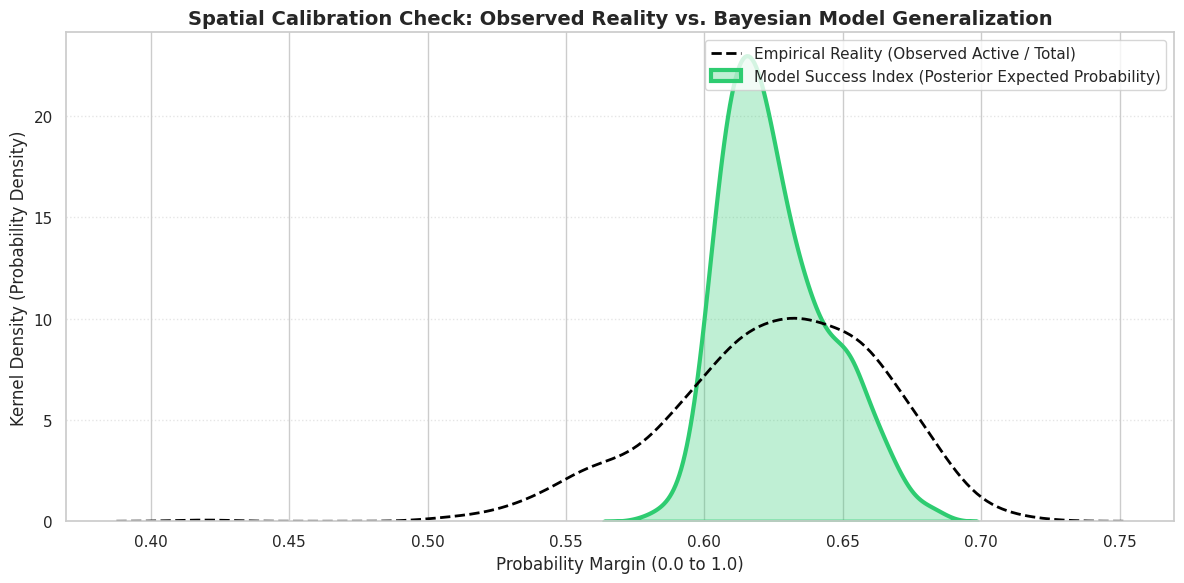

✅ Predictive calibration plot successfully generated.


In [23]:
# ==============================================================================
# EMPIRICAL VALIDATION: POSTERIOR PREDICTIVE DENSITY CALIBRATION
# ==============================================================================
# This module performs a Kernel Density Estimation (KDE) comparison to evaluate 
# the distributional alignment between observed empirical rates and the model's 
# posterior expected probabilities.

print("\n--- 📈 RENDERING PREDICTIVE CALIBRATION DENSITY PLOT ---")
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Formatting Kernel Density Estimates (KDE)...")

# --- 1. DATA EXTRACTION & TENSOR AGGREGATION ---
# Calculate the raw empirical success rate directly from the observed data arrays 
# used during model training to ensure perfect alignment.
empirical_rate = y_obs_data / n_obs

# Extract the posterior global mean for the 'p_success' parameter from the spatial trace.
# This collapses the high-dimensional posterior (chains x draws) into a 
# representative vector of expected probabilities for the 645 municipalities.
success_index_mean = trace_spatial.posterior['p_success'].mean(dim=("chain", "draw")).values

# --- 2. GENERATE VALIDATION VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Observed Data Distribution: The 'Empirical Reality'
# Represented as a dashed black line to signify the raw, unfiltered data distribution.
sns.kdeplot(empirical_rate, 
            label="Empirical Reality (Observed Active / Total)", 
            color="black", lw=2, linestyle="--")

# Model Estimate Distribution: The 'Bayesian Generalization'
# Represented with a vibrant green fill. The model's curve is typically 
# smoother due to the spatial 'borrowing strength' (shrinkage) effect 
# which naturally stabilizes local extremes through neighborhood context.
sns.kdeplot(success_index_mean, 
            label="Model Success Index (Posterior Expected Probability)", 
            color="#2ecc71", fill=True, alpha=0.3, lw=3)

# --- 3. FORMATTING FOR RESEARCH PUBLICATION STANDARDS ---
plt.title("Spatial Calibration Check: Observed Reality vs. Bayesian Model Generalization", 
          fontsize=14, fontweight='bold')
plt.xlabel("Probability Margin (0.0 to 1.0)", fontsize=12)
plt.ylabel("Kernel Density (Probability Density)", fontsize=12)

plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Predictive calibration plot successfully generated.")

The spatial calibration check compares two distributions on the probability scale: the empirical survival rate (observed active/total per municipality) and the posterior expected probability $\mathbb{E}[p_i \mid \text{data}]$. A well-calibrated model should produce posterior estimates that are aligned with the empirical distribution while reflecting appropriate regularization.

Both distributions are centered near 0.61–0.62, indicating that the model reproduces the overall level of the observed survival rate without evidence of systematic bias.

A key difference arises in dispersion: the empirical distribution is wider (approximately 0.45 to 0.75), whereas the posterior expectations are more concentrated (approximately 0.57 to 0.67). This reduction in spread is consistent with partial pooling and spatial smoothing under the BYM2 specification, which shrinks extreme municipality-level observations toward values supported by neighboring regions.

Accordingly, the posterior estimates can be interpreted as regularized versions of the empirical rates, with reduced sensitivity to local sampling variability. There is no indication that the model is systematically misaligned with the observed distribution, although the reduced dispersion reflects the expected trade-off between variance reduction and local fidelity.

## 4.11. Visualizations

### 4.11.1 Strategic Geospatial Mapping: Opportunity vs Risk

This module translates the BYM2 posterior into two decision-oriented indicators: expected business success and associated uncertainty, mapped across municipalities.

#### Key Indicators

Two complementary metrics are derived from the posterior distribution of $p_{\text{success}}$:

**A. Success Index (Posterior Mean)**  

$$
\text{Success Index}_i = \mathbb{E}[p_{\text{success}, i} \mid \text{data}]
$$

This represents the expected probability of business survival in each municipality and serves as a measure of opportunity.

**B. Investment Risk (Posterior Standard Deviation)**  

$$
\text{Investment Risk}_i = \text{SD}[p_{\text{success}, i} \mid \text{data}]
$$

This captures the uncertainty associated with each prediction. Higher values indicate lower confidence in the estimated success probability.

#### Interpretation

These two dimensions should be interpreted jointly:

| Success Index | Investment Risk | Interpretation |
|---|---|---|
| High | Low | **Prime Opportunity** — high expected performance with strong confidence |
| High | High | **Potential Upside** — promising but uncertain; requires further assessment |
| Low | Low | **Stable Underperformer** — consistently low expected performance |
| Low | High | **High Risk Zone** — uncertain and unfavorable conditions |

Together, these indicators provide a spatially explicit view of both expected outcomes and uncertainty, supporting informed decision-making across regions.


--- 🗺️  GENERATING GEOSPATIAL STRATEGY DASHBOARDS ---
[21:02:06] Translating MCMC posteriors into spatial intelligence...


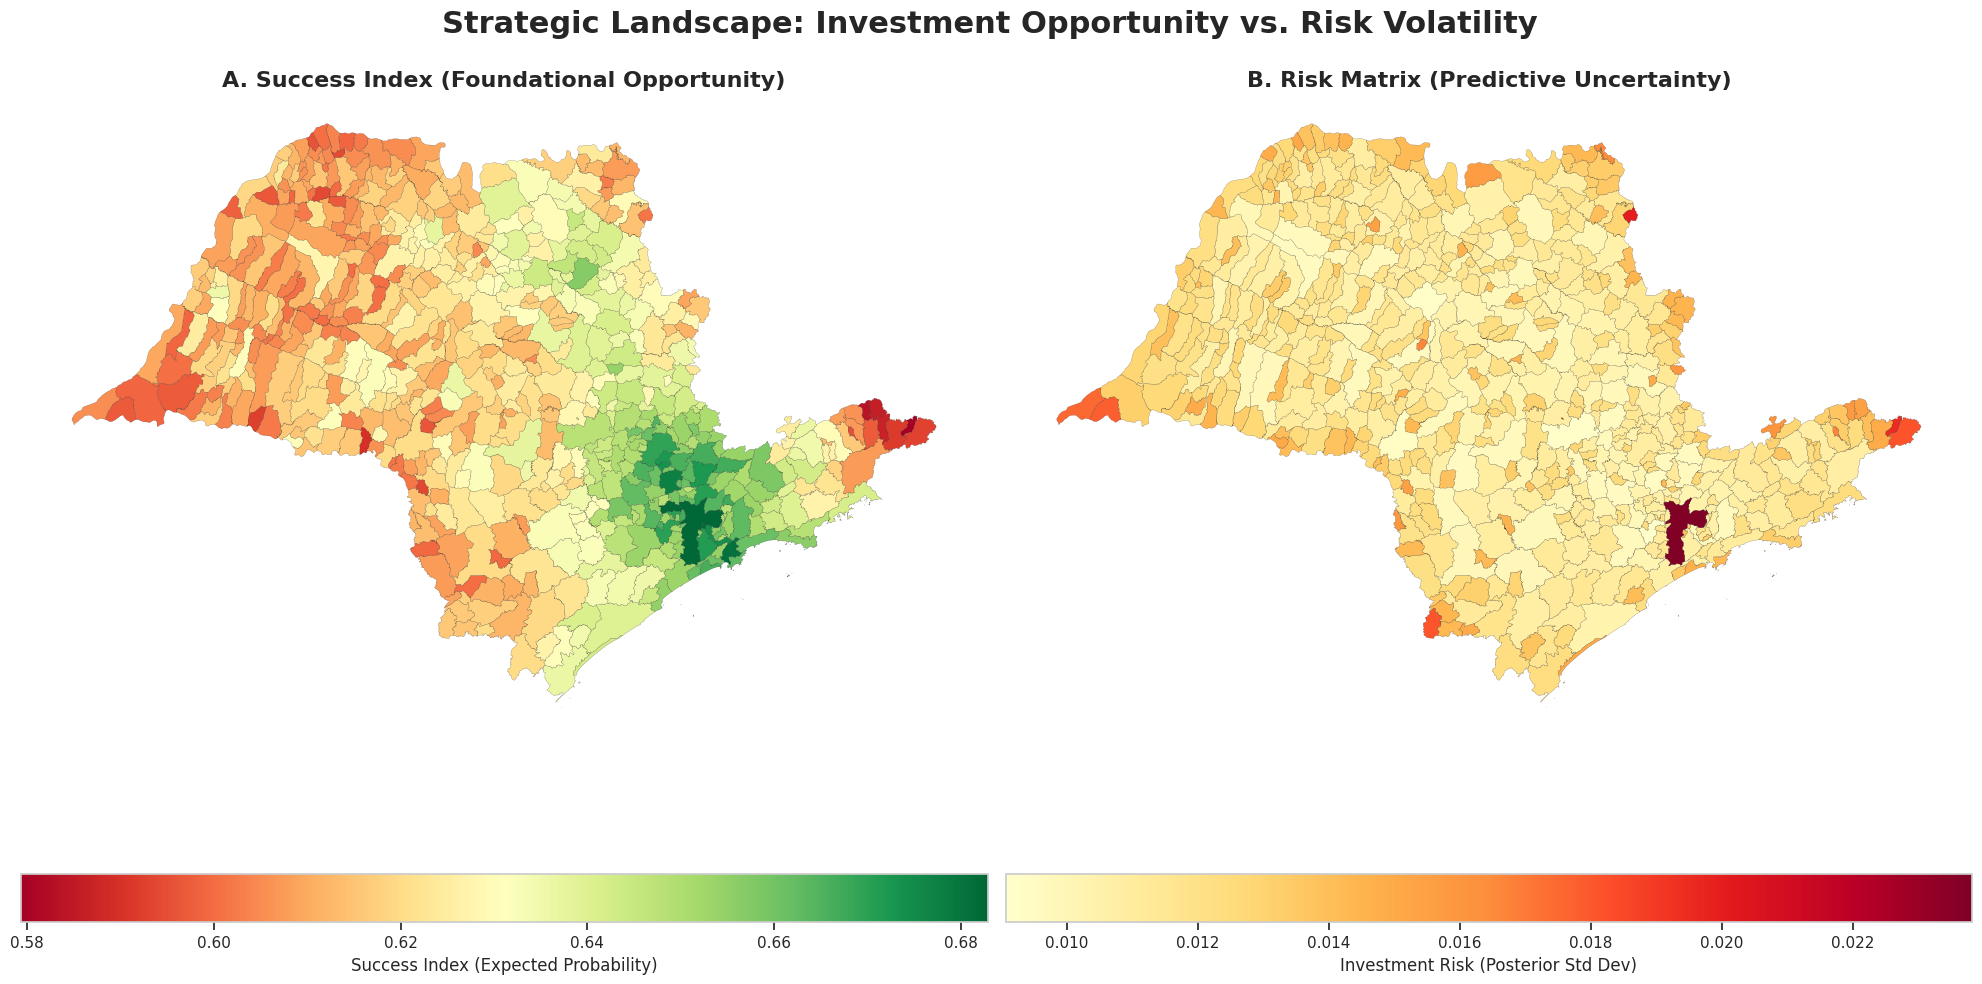

[21:02:08] ✅ Strategic geospatial dashboards successfully rendered.


In [24]:
# ==============================================================================
# STRATEGIC MAPPING: SUCCESS OPPORTUNITY VS. INVESTMENT RISK
# ==============================================================================
# This module translates the high-dimensional Bayesian posteriors into 
# geographical KPIs: the Success Index (Mean) and Investment Risk (Uncertainty).

print("\n--- 🗺️  GENERATING GEOSPATIAL STRATEGY DASHBOARDS ---")
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Translating MCMC posteriors into spatial intelligence...")

# --- 1. CALCULATE BAYESIAN SPATIAL KPIs ---

# SUCCESS INDEX: The expected probability of business survival (Posterior Mean).
# This metric identifies regions with strong structural and spatial fundamentals.
gdf_sp['success_index'] = trace_spatial.posterior['p_success'].mean(dim=("chain", "draw")).values

# INVESTMENT RISK: The volatility or uncertainty of the estimate (Posterior Std Dev).
# Higher values indicate regions where the model detects predictive volatility, 
# potentially due to data sparsity or conflicting covariate signals.
gdf_sp['investment_risk'] = trace_spatial.posterior['p_success'].std(dim=("chain", "draw")).values


# --- 2. GENERATE GEOSPATIAL VISUALIZATIONS ---

# Create a dual-column layout to contrast Opportunity (Success) against Risk (Uncertainty).
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Global Figure Title
fig.suptitle('Strategic Landscape: Investment Opportunity vs. Risk Volatility', 
             fontsize=22, fontweight='bold', y=1.02)

# --- Map A: Success Index (Opportunity Landscape) ---
# Using the 'RdYlGn' (Red-Yellow-Green) colormap. Green indicates high-probability survival zones.
gdf_sp.plot(column='success_index', 
            cmap='RdYlGn', 
            edgecolor='black',    # Ensuring crisp boundary definition
            linewidth=0.1,        # Minimal border width to preserve spatial resolution
            legend=True, 
            legend_kwds={'label': "Success Index (Expected Probability)", 'orientation': 'horizontal'},
            ax=ax[0])
ax[0].set_title("A. Success Index (Foundational Opportunity)", fontsize=16, fontweight='bold')
ax[0].axis('off') # Hiding geographical coordinates for a clean aesthetic.

# --- Map B: Investment Risk (Uncertainty Landscape) ---
# Using the 'YlOrRd' (Yellow-Orange-Red) colormap. 
# Red signifies areas where predictive uncertainty is statistically high.
gdf_sp.plot(column='investment_risk', 
            cmap='YlOrRd', 
            edgecolor='black', 
            linewidth=0.1, 
            legend=True, 
            legend_kwds={'label': "Investment Risk (Posterior Std Dev)", 'orientation': 'horizontal'},
            ax=ax[1])
ax[1].set_title("B. Risk Matrix (Predictive Uncertainty)", fontsize=16, fontweight='bold')
ax[1].axis('off')

# Final layout adjustment
plt.tight_layout()
plt.show()

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] ✅ Strategic geospatial dashboards successfully rendered.")

The spatial outputs of the BYM2 model are summarized through two complementary maps: the posterior mean survival probability ($\bar{p}i$) and its associated uncertainty ($\sigma{p_i}$).

Map A — Posterior mean ($\bar{p}_i$) shows a clear centre–periphery gradient in estimated business survival. Higher values are concentrated in the São Paulo metropolitan region and the southeastern corridor ($\bar{p}_i \approx 0.66$–0.68), while lower values are observed in northwestern and western municipalities ($\bar{p}_i \approx 0.58$–0.60). This pattern is consistent with the spatial distribution of the retained covariates (road infrastructure, HDI income, and distance to the capital) as well as the contribution of the ICAR spatial field, which captures residual geographic structure.

Map B — Posterior uncertainty ($\sigma_{p_i}$) indicates generally low variability across the state ($\sigma \approx 0.010$–0.014), suggesting that estimates are relatively stable for most municipalities. Localized areas of higher uncertainty ($\sigma \approx 0.020$–0.022) appear in parts of the center-south, indicating regions where posterior estimates are less precise. These areas may correspond to municipalities with less typical covariate profiles or weaker support from neighboring observations.

Taken together, the maps illustrate spatial variation in both estimated survival probabilities and the associated uncertainty, highlighting regions where the model provides more or less precise estimates.

### 4.11.2 Strategic Quadrant Classification: Risk–Opportunity Matrix

This module converts the two key indicators (Success Index and Investment Risk) into a four-quadrant decision framework, enabling direct classification of municipalities into actionable strategic categories.

#### Threshold Definition

Quadrants are defined using the median values of Success Index and Investment Risk. This approach provides a robust and balanced partition of municipalities, classifying each location relative to the overall distribution.

#### Strategic Archetypes

| Quadrant | Success Index | Investment Risk | Interpretation |
|---|---|---|---|
| **Safe Opportunity** | ≥ Median | < Median | High expected performance with strong confidence |
| **High Stakes** | ≥ Median | ≥ Median | Promising but uncertain; requires further assessment |
| **Underperformer** | < Median | < Median | Consistently low expected performance |
| **Critical Zone** | < Median | ≥ Median | Unfavorable and uncertain conditions |

#### Decision Space Visualization

A scatter plot of municipalities in the $(\text{Success Index}, \text{Investment Risk})$ space provides a visual representation of the classification. Median thresholds define the quadrant boundaries, highlighting the distribution of municipalities across strategic categories.

#### Spatial Distribution

Mapping these classifications reveals the geographic structure of opportunity and risk. Spatial clustering of similar categories indicates that the quadrant framework captures underlying regional patterns rather than arbitrary statistical groupings.


--- 🎯 EXECUTING STRATEGIC QUADRANT SEGMENTATION ---
[21:02:08] Mapping municipalities into actionable decision clusters...
-> Threshold metrics: Success Median = 0.622 | Risk Median = 0.012
✅ Municipalities successfully categorized into strategic clusters.
-> Rendering 2D Scatter Plot for distribution analysis...


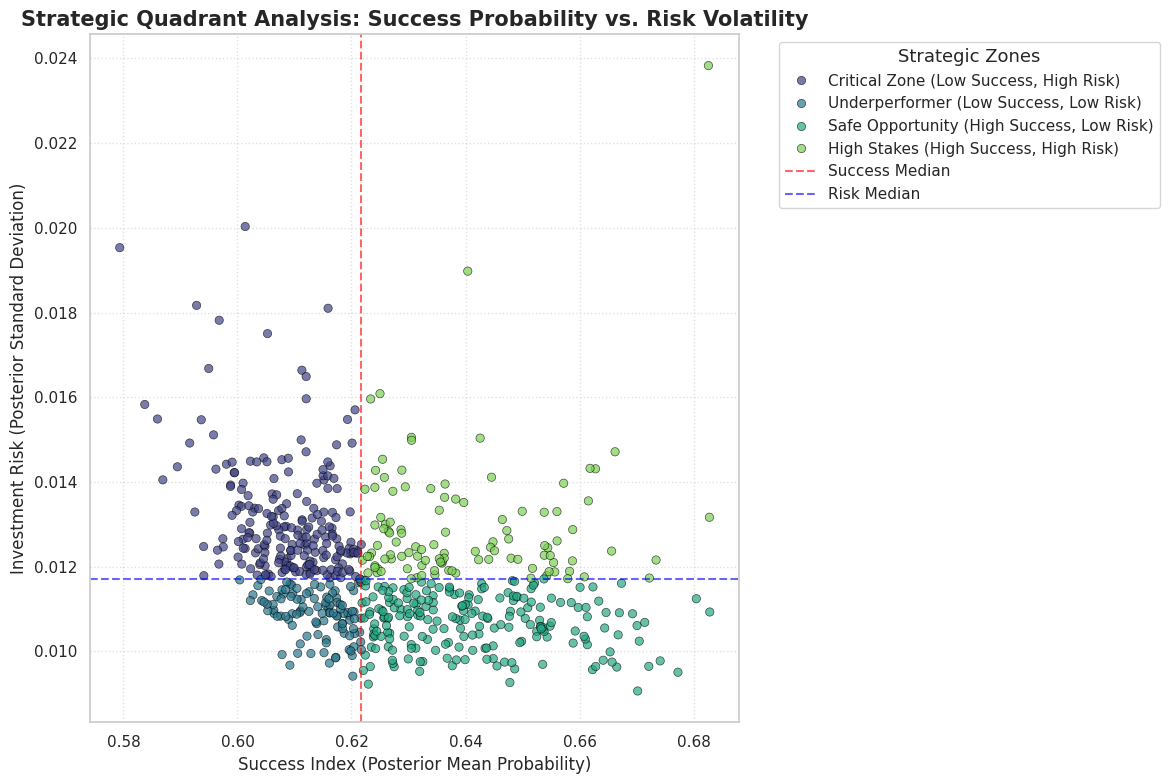

-> Rendering Geospatial Quadrant Map...


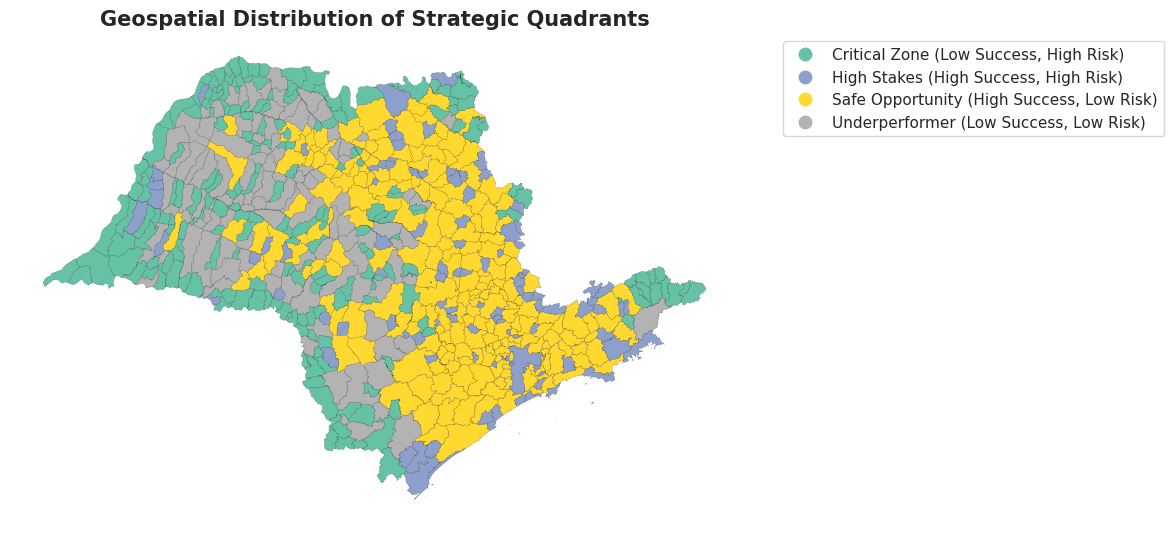

[21:02:09] ✅ End-to-end Bayesian Spatial Pipeline completed.


In [25]:
# ==============================================================================
# STRATEGIC QUADRANT CLASSIFICATION: RISK-OPPORTUNITY MATRIX
# ==============================================================================
# This final analytical stage segments all 645 municipalities into four 
# distinct strategic archetypes based on their success probability vs. risk.

print("\n--- 🎯 EXECUTING STRATEGIC QUADRANT SEGMENTATION ---")
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Mapping municipalities into actionable decision clusters...")

# --- 1. DEFINE DECISION THRESHOLDS ---
# Median values are used as thresholds to ensure a statistically balanced 
# distribution of units across the four quadrants, effectively mitigating outlier skew.
success_median = gdf_sp['success_index'].median()
risk_median = gdf_sp['investment_risk'].median()

print(f"-> Threshold metrics: Success Median = {success_median:.3f} | Risk Median = {risk_median:.3f}")

# --- 2. CLASSIFICATION HEURISTICS ---
def classify_quadrant(row):
    # High Success + Low Risk: Priority investment targets with proven stability.
    if row['success_index'] >= success_median and row['investment_risk'] < risk_median:
        return 'Safe Opportunity (High Success, Low Risk)'
    
    # High Success + High Risk: High-potential areas requiring rigorous due diligence.
    elif row['success_index'] >= success_median and row['investment_risk'] >= risk_median:
        return 'High Stakes (High Success, High Risk)'
    
    # Low Success + Low Risk: Consistent underperformers with structural limitations.
    elif row['success_index'] < success_median and row['investment_risk'] < risk_median:
        return 'Underperformer (Low Success, Low Risk)'
    
    # Low Success + High Risk: High-volatility zones showing poor outcomes.
    else:
        return 'Critical Zone (Low Success, High Risk)'

# Apply the classification logic to the spatial GeoDataFrame
gdf_sp['quadrant'] = gdf_sp.apply(classify_quadrant, axis=1)
print("✅ Municipalities successfully categorized into strategic clusters.")

# --- 3. STRATEGIC SCATTER PLOT ---
# Visualizing the distribution of all units within the 2D decision space.
print("-> Rendering 2D Scatter Plot for distribution analysis...")
plt.figure(figsize=(12, 8))
sns.scatterplot(data=gdf_sp, x='success_index', y='investment_risk', 
                hue='quadrant', palette='viridis', alpha=0.7, edgecolor='black')

# Draw threshold lines to delineate the four strategic zones
plt.axvline(success_median, color='red', linestyle='--', alpha=0.6, label='Success Median')
plt.axhline(risk_median, color='blue', linestyle='--', alpha=0.6, label='Risk Median')

# Formatting for professional research layout
plt.title("Strategic Quadrant Analysis: Success Probability vs. Risk Volatility", 
          fontsize=15, fontweight='bold')
plt.xlabel("Success Index (Posterior Mean Probability)", fontsize=12)
plt.ylabel("Investment Risk (Posterior Standard Deviation)", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Strategic Zones", title_fontsize='13')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 4. GEOSPATIAL DISTRIBUTION MAP ---
# Mapping the categorical Quadrants back to the geographic terrain for hot-spot identification.
print("-> Rendering Geospatial Quadrant Map...")
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Categorical mapping using distinct color clusters for maximum interpretability
gdf_sp.plot(column='quadrant', 
            legend=True, 
            legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'},
            categorical=True, 
            cmap='Set2', 
            edgecolor='black', 
            linewidth=0.1,
            ax=ax)

ax.set_title("Geospatial Distribution of Strategic Quadrants", fontsize=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] ✅ End-to-end Bayesian Spatial Pipeline completed.")

The posterior estimates are summarized through a four-quadrant classification based on the joint distribution of the posterior mean ($\bar{p}i$) and posterior standard deviation ($\sigma{p_i}$). Municipalities are partitioned using the sample medians as thresholds (Success median = 0.622; Uncertainty median = 0.012), yielding four mutually exclusive groups.

The scatter plot shows a negative association between estimated success probability and uncertainty: municipalities with higher $\bar{p}i$ tend to exhibit lower $\sigma{p_i}$. This pattern is consistent with spatial smoothing under the BYM2 specification, whereby regions with stronger and more homogeneous signal benefit from greater information sharing across neighboring units.

The largest group consists of municipalities with above-median success and below-median uncertainty. A smaller subset combines high estimated success with elevated uncertainty, indicating less precise estimates despite favorable predicted outcomes. Conversely, municipalities with low success and high uncertainty represent areas where both outcomes and estimates are less favorable, while those with low success and low uncertainty are more consistently identified as such.

The spatial distribution of these groups exhibits clear geographic structure. Municipalities with higher success and lower uncertainty are concentrated in the central and southeastern regions, while lower-success categories are more prevalent in the northwestern and western parts of the state. Areas with higher uncertainty appear as more localized clusters, reflecting regions where posterior estimates are less tightly constrained.

Taken together, the classification provides a compact summary of joint variation in estimated outcomes and uncertainty, while the map highlights the spatial organization of these patterns.

### 4.11.3. Strategic Ranking Extraction: Top-N Municipality Lists

### 4.11.3 Strategic Ranking: Top-N Municipality Lists

This module translates the quadrant classification into ranked lists of municipalities, providing a concise and actionable output for decision-making.

#### Objective

Rather than presenting the full set of municipalities, this step highlights the most relevant cases within each strategic category, enabling targeted policy and investment prioritization.

#### Ranking Approach

Within each quadrant, municipalities are ranked according to their underlying indicators:

- **Safe Opportunity / High Stakes**: ranked by descending Success Index  
- **Underperformer / Critical Zone**: ranked by ascending Success Index  
- Ties are resolved using Investment Risk as a secondary criterion

This ensures that rankings reflect both expected performance and associated uncertainty.

#### Interpretation

Top-ranked municipalities represent the most extreme and informative cases within each category:

- High-ranking **Safe Opportunities** indicate strong, reliable investment environments  
- High-ranking **High Stakes** highlight areas with potential upside but elevated uncertainty  
- Low-ranking **Underperformers** and **Critical Zones** identify structurally constrained or uncertain regions requiring caution or further investigation  

These ranked lists provide a practical interface between model outputs and real-world decision-making, allowing stakeholders to focus on the most strategically relevant locations.

In [26]:
# ==============================================================================
# STRATEGIC RANKING EXTRACTION: TOP-N MUNICIPALITY LISTS
# ==============================================================================
# This utility generates high-priority lists for each strategic quadrant, 
# facilitating the identification of critical geographical clusters for policy intervention.

def get_top_ranked_list(gdf_sp, quadrant_name, top_n=10):
    """
    Identifies and ranks the top municipalities within a specific quadrant boundary.
    - 'High Success' segments: Ranked by descending success index (Prime targets).
    - 'Low Success' segments: Ranked by ascending success index (Vulnerability anchors).
    """
    # Isolate the quadrant-specific subset
    subset = gdf_sp[gdf_sp['quadrant'] == quadrant_name].copy()
    
    # Apply context-specific sorting logic
    if "High Success" in quadrant_name:
        subset = subset.sort_values(by='success_index', ascending=False)
    else:
        subset = subset.sort_values(by='success_index', ascending=True)
        
    # Extract core analytical parameters and round to 4 decimals for reporting clarity
    final_table = subset[['municipality_name', 'success_index', 'investment_risk']].head(top_n)
    final_table = final_table.round(4).reset_index(drop=True)
    
    # Standardize column headers for research presentation
    final_table.columns = ['Municipality Name', 'Success Prob. (Mean)', 'Risk Volatility (Std)']
    
    # Adjust index explicitly to start from 1 for ranking aesthetics
    final_table.index = final_table.index + 1
    
    return final_table

# --- EXECUTION: QUADRANT RANKING MODULES ---

print("\n--- 📊 EXTRACTING SEGMENTED STRATEGIC RANKINGS ---")

# 1. Safe Opportunity: The absolute strongest hubs (Premium Investment)
safe_opportunities = get_top_ranked_list(gdf_sp, 'Safe Opportunity (High Success, Low Risk)')

# 2. High Stakes: High Potential areas requiring extensive due-diligence
high_stakes = get_top_ranked_list(gdf_sp, 'High Stakes (High Success, High Risk)')

# 3. Critical Zone: The most vulnerable and volatile geographies
critical_zone = get_top_ranked_list(gdf_sp, 'Critical Zone (Low Success, High Risk)')

# 4. Underperformer: Structurally depressed areas showing low stability
underperformers = get_top_ranked_list(gdf_sp, 'Underperformer (Low Success, Low Risk)')

# --- DISPLAY PROTOCOL (JUPYTER INTERACTIVE TABLES) ---

display(Markdown("### 🌟 STRATEGIC TOP 10: SAFE OPPORTUNITIES (Premium Hubs)"))
display(safe_opportunities)

display(Markdown("### ⚖️ STRATEGIC TOP 10: HIGH STAKES (High Potential, High Risk)"))
display(high_stakes)

display(Markdown("### 🚨 STRATEGIC TOP 10: CRITICAL ZONE (Highly Vulnerable Geographies)"))
display(critical_zone)

display(Markdown("### 📉 STRATEGIC TOP 10: UNDERPERFORMERS (Structurally Depressed)"))
display(underperformers)

print("✅ All strategic quadrant tables extracted and formatted successfully.")


--- 📊 EXTRACTING SEGMENTED STRATEGIC RANKINGS ---


### 🌟 STRATEGIC TOP 10: SAFE OPPORTUNITIES (Premium Hubs)

,Municipality Name,Success Prob. (Mean),Risk Volatility (Std)
1,Santana De Parnaiba,0.6828,0.0109
2,Santos,0.6805,0.0112
3,Jundiai,0.6773,0.0095
4,Santo Andre,0.6741,0.0098
5,Atibaia,0.6722,0.0096
6,Sao Bernardo Do Campo,0.6714,0.0107
7,Mairipora,0.6705,0.0102
8,Cotia,0.6702,0.0091
9,Barueri,0.6701,0.0106
10,Campinas,0.6693,0.0109


### ⚖️ STRATEGIC TOP 10: HIGH STAKES (High Potential, High Risk)

,Municipality Name,Success Prob. (Mean),Risk Volatility (Std)
1,Sao Caetano Do Sul,0.6828,0.0132
2,Sao Paulo,0.6826,0.0238
3,Vinhedo,0.6734,0.0122
4,Valinhos,0.6723,0.0117
5,Praia Grande,0.6662,0.0147
6,Vargem Grande Paulista,0.6656,0.0124
7,Guaruja,0.6628,0.0143
8,Varzea Paulista,0.6618,0.0143
9,Mongagua,0.6616,0.0136
10,Taboao Da Serra,0.6608,0.0118


### 🚨 STRATEGIC TOP 10: CRITICAL ZONE (Highly Vulnerable Geographies)

,Municipality Name,Success Prob. (Mean),Risk Volatility (Std)
1,Arapei,0.5793,0.0195
2,Lavrinhas,0.5837,0.0158
3,Queluz,0.5860,0.0155
4,Areias,0.5869,0.0140
5,Ibirarema,0.5895,0.0144
6,Sao Jose Do Barreiro,0.5916,0.0149
7,Nantes,0.5925,0.0133
8,Bananal,0.5928,0.0182
9,Sarutaia,0.5937,0.0155
10,Guarani D'Oeste,0.5941,0.0125


### 📉 STRATEGIC TOP 10: UNDERPERFORMERS (Structurally Depressed)

,Municipality Name,Success Prob. (Mean),Risk Volatility (Std)
1,Barbosa,0.6004,0.0117
2,Piacatu,0.6023,0.0112
3,Lavinia,0.6027,0.0113
4,Alto Alegre,0.6036,0.0116
5,Sagres,0.6041,0.0117
6,Mariapolis,0.6043,0.0112
7,Planalto,0.6047,0.0112
8,Magda,0.6052,0.0111
9,Luiziania,0.6053,0.0110
10,Flora Rica,0.6056,0.0114


✅ All strategic quadrant tables extracted and formatted successfully.


### 4.11.4 Covariate Profile Analysis: Structural Patterns by Strategic Quadrant

This module analyzes the average covariate profile of each strategic quadrant, providing insight into the structural conditions associated with different levels of opportunity and risk.

#### Method

For each quadrant, the mean standardized value (Z-score) of all predictors is computed. This produces a representative profile describing the typical socioeconomic and geographic characteristics of municipalities within each category.

The results are visualized as a heatmap, where rows correspond to quadrants and columns to predictors.

#### Interpretation

The heatmap highlights systematic differences across quadrants:

- Positive values indicate that a covariate is above the overall mean within a given quadrant  
- Negative values indicate below-average levels  

These patterns reveal which structural factors are associated with favorable or unfavorable outcomes. For example, quadrants characterized by higher success probabilities typically exhibit stronger infrastructure and higher income-related indicators, while lower-performing quadrants tend to display the opposite pattern.

#### Analytical Value

This analysis links the model’s predictions back to observable features, enabling interpretation of the underlying drivers of each strategic category. It provides a bridge between statistical outputs and actionable insights by identifying the covariate combinations that define high- and low-performing environments.

### 📊 MEAN CHAMPION PREDICTOR Z-SCORES BY STRATEGIC QUADRANT

*__Intelligence Note:__ The divergence indicates structural concentration. Warm colors (Red) indicate above-average levels, while cold colors (Blue) indicate structural deficiencies relative to the global mean (0.0).*

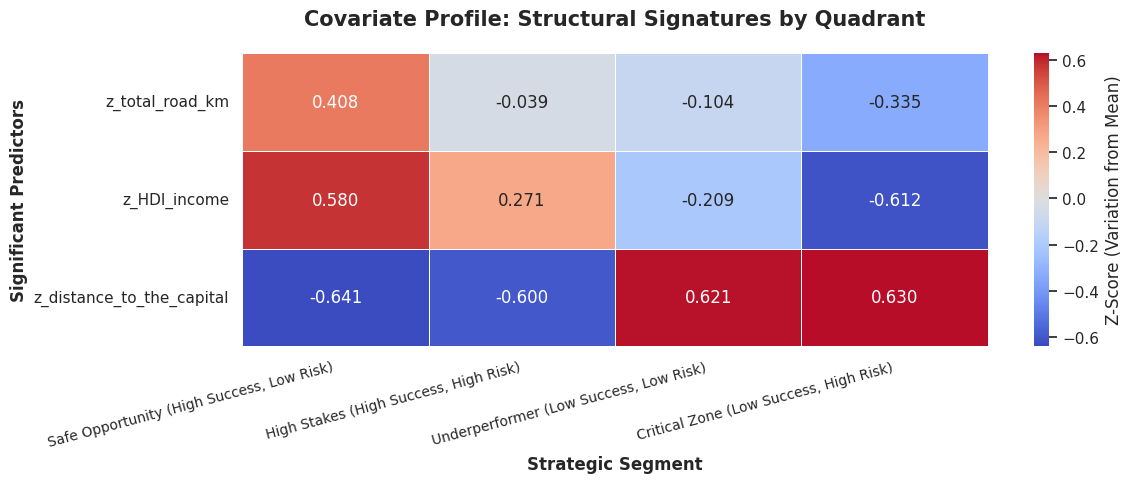


✅ Covariate-Profile strategic heatmapping successfully completed.


In [27]:
# ==============================================================================
# COVARIATE PROFILE ANALYTICS BY STRATEGIC QUADRANT
# ==============================================================================
# This module identifies the structural signature for each segment by 
# calculating mean Z-Scores exclusively for the filtered champion predictors.

# 1. ORCHESTRATE LOGICAL SEQUENTIAL REPORTING ORDER
quadrant_order = [
    'Safe Opportunity (High Success, Low Risk)',
    'High Stakes (High Success, High Risk)',
    'Underperformer (Low Success, Low Risk)',
    'Critical Zone (Low Success, High Risk)'
]

# 2. AGGREGATE EMPIRICAL CONCENTRATIONS (SURVIVING VARIABLES ONLY)
# Dynamically extract the names of the predictors that survived the Lasso penalty.
surviving_vars = survivors['Predictor'].tolist()

# Group by quadrant and calculate the mean value specifically for these champion drivers.
quadrant_summary = gdf_sp.groupby('quadrant')[surviving_vars].mean()

# 3. FORMAT FOR VERTICAL READABILITY
# Transposing for presentation-ready vertical reports (Rows = Predictors, Columns = Quadrants).
comparison_table = quadrant_summary.T

# Dynamically reorder columns according to logical policy progression 
# (Filters to ensure only existing empirical quadrants are plotted).
available_quadrants = [q for q in quadrant_order if q in comparison_table.columns]
comparison_table = comparison_table[available_quadrants].round(3)

# --- 4. DISPLAY RESULTS AS A SEABORN HEATMAP ---

display(Markdown("### 📊 MEAN CHAMPION PREDICTOR Z-SCORES BY STRATEGIC QUADRANT"))
display(Markdown("*__Intelligence Note:__ The divergence indicates structural concentration. Warm colors (Red) indicate above-average levels, while cold colors (Blue) indicate structural deficiencies relative to the global mean (0.0).*"))

# Render a Seaborn Heatmap instead of Pandas HTML to bypass 'jinja2' cluster errors 
# and explicitly generate a high-resolution, exportable research plot.
plt.figure(figsize=(12, max(5, len(comparison_table) * 0.6)))

sns.heatmap(comparison_table, 
            cmap="coolwarm", 
            annot=True,          # Overlay numerical values inside the grid boxes
            fmt=".3f",           # Format cell numbers to 3 decimal places
            linewidths=0.5,      # Add internal gridlines for layout clarity
            cbar_kws={'label': 'Z-Score (Variation from Mean)'},
            center=0)            # Force absolute zero metric to display as white

# Formatting Heatmap Aesthetics for publication standards
plt.title("Covariate Profile: Structural Signatures by Quadrant", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Strategic Segment", fontsize=12, fontweight='bold')
plt.ylabel("Significant Predictors", fontsize=12, fontweight='bold')

# Adjust tick labels for crisp readability without chaotic overlapping
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Covariate-Profile strategic heatmapping successfully completed.")

### 4.11.5 Radar Chart: Structural Profiles by Strategic Quadrant

This module visualizes the covariate profiles of each strategic quadrant using a radar chart, enabling direct comparison of their structural characteristics.

#### Construction

The chart displays the mean standardized values (Z-scores) of the selected predictors for each quadrant. Each axis corresponds to a predictor, and each quadrant is represented by a polygon connecting its average values across all axes.

Only predictors retained through the Bayesian Lasso are included, ensuring that the visualization focuses on the most relevant drivers of business survival.

#### Interpretation

The shape of each polygon represents the structural profile of a quadrant:

- Larger extensions along an axis indicate stronger presence of that feature  
- Comparisons across polygons reveal how quadrants differ in key predictors  

This allows for rapid identification of the combinations of factors associated with high opportunity or elevated risk.

#### Analytical Value

The radar chart provides a compact summary of multivariate differences between quadrants, complementing the heatmap by emphasizing relative contrasts in key predictors. It offers an intuitive visualization of how structural conditions vary across strategic categories.


--- 🕸️  GENERATING STRATEGIC DNA RADAR CHART ---
-> Top 3 influential drivers identified: Distance To The Capital, Hdi Income, Total Road Km


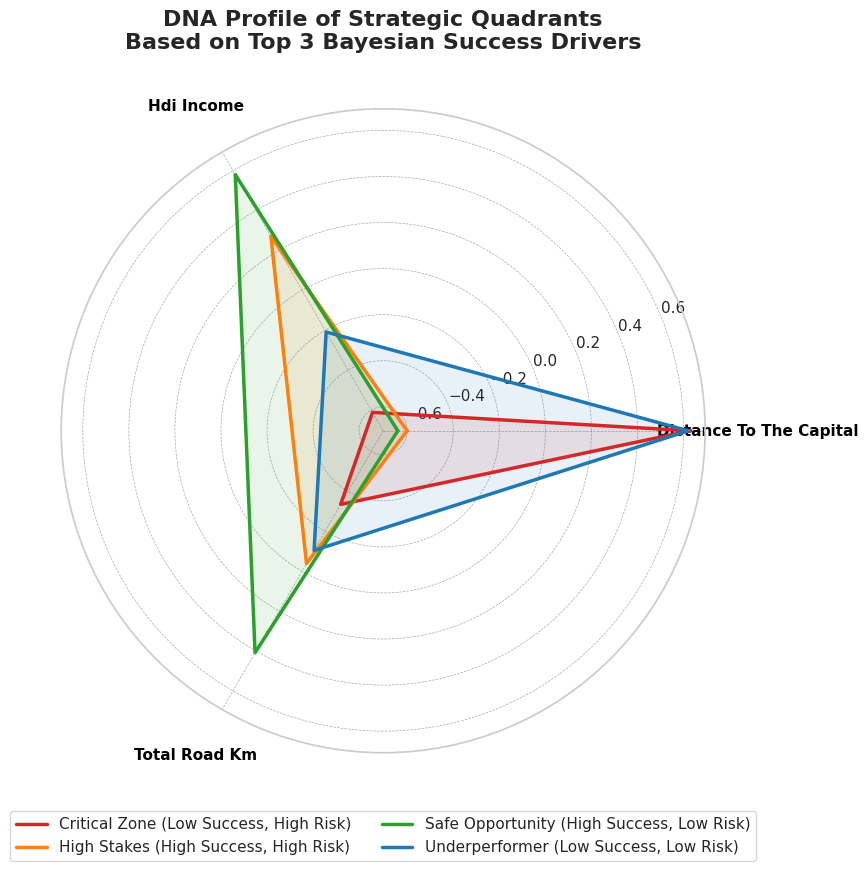

✅ Strategic DNA radar chart successfully rendered.


In [28]:
# ==============================================================================
# SPIDER CHART: THE "STRATEGIC DNA" OF BUSINESS SUCCESS QUADRANTS
# ==============================================================================
# This module generates an intelligence radar chart to compare the structural 
# profiles (DNA) of the four strategic quadrants based on the top Bayesian drivers.

print("\n--- 🕸️  GENERATING STRATEGIC DNA RADAR CHART ---")

# 1. DYNAMICALLY EXTRACT TOP SURVIVING PREDICTORS
# Reconstructing the variable names that successfully passed the Bayesian Lasso filter.
surviving_predictor_names = [z_predictors[i] for i in significant_indices]

# Extract posterior properties specifically for these champion drivers.
summary_betas = az.summary(trace_spatial, var_names=["beta"])
summary_betas['Predictor'] = surviving_predictor_names

# Capture the top N (up to 6) variables with the highest absolute mathematical impact.
top_n = min(6, len(surviving_predictor_names))
top_vars = summary_betas.reindex(summary_betas['mean'].abs().sort_values(ascending=False).index).head(top_n)['Predictor'].tolist()

# Display the identified champion drivers for documentation.
clean_top_vars = [n.replace('z_', '').replace('_', ' ').title() for n in top_vars]
print(f"-> Top {top_n} influential drivers identified: {', '.join(clean_top_vars)}")

# 2. AGGREGATE MEAN Z-SCORES BY QUADRANT
radar_data = gdf_sp.groupby('quadrant')[top_vars].mean()

# 3. INITIALIZE POLAR PROJECTION CANVAS
N = len(top_vars)
# Calculate split angles dynamically based on the final variable count.
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Closing the geometric loop

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Configure axes labels with high-readability formatting.
plt.xticks(angles[:-1], clean_top_vars, color='black', size=11, fontweight='bold')
ax.tick_params(pad=25) 

# Assign corporate colors mapping back to the Strategic Quadrants.
radar_colors = {
    'Safe Opportunity (High Success, Low Risk)': '#2ca02c', # Green
    'High Stakes (High Success, High Risk)': '#ff7f0e',     # Orange
    'Underperformer (Low Success, Low Risk)': '#1f77b4',    # Blue
    'Critical Zone (Low Success, High Risk)': '#d62728'     # Red
}

# 4. PLOT STRATEGIC QUADRANT PROFILES
for quadrant in radar_data.index:
    if quadrant in radar_colors:
        # Extract and close the values loop for plotting.
        values = radar_data.loc[quadrant].values.flatten().tolist()
        values += values[:1]
        
        q_color = radar_colors[quadrant]
        
        # Plot binary trace lines and semi-transparent visual fills.
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=quadrant, color=q_color)
        ax.fill(angles, values, color=q_color, alpha=0.1)

# Enhance radial grid structure for visual precision.
ax.grid(color='#AAAAAA', linestyle='--', linewidth=0.5)

# Formatting Legends and Titles
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), fontsize=11, ncol=2)
plt.title(f"DNA Profile of Strategic Quadrants\nBased on Top {top_n} Bayesian Success Drivers", 
          size=16, fontweight='bold', y=1.08)

plt.tight_layout()
plt.show()

print("✅ Strategic DNA radar chart successfully rendered.")

The covariate profiles of the four groups are summarized using the mean standardized (Z-scored) values of the three selected predictors: HDI income, total road length, and distance to the capital.

Municipalities with higher estimated success and lower uncertainty exhibit the most favorable covariate profile, combining above-average HDI income and road infrastructure with relatively short distance to the capital. This pattern is consistent with the positive associations identified for income and infrastructure, and the negative association with distance.

In contrast, municipalities with lower estimated success tend to be characterized by greater distance from the capital. Among these, those with higher uncertainty display somewhat more favorable income and infrastructure levels than their lower-uncertainty counterparts, suggesting heterogeneity within low-success regions.

Municipalities with intermediate profiles across all three covariates exhibit correspondingly moderate outcomes and relatively low uncertainty, indicating more stable but less favorable conditions.

Overall, the group-level profiles align with the estimated effects of the covariates, providing a descriptive link between the spatial classification and the underlying predictors. These patterns should be interpreted as associative rather than causal, reflecting how the model distributes posterior mass across municipalities given the observed data and spatial structure.

### 4.11.6 Advanced Spatial Analytics: Latent Effects and Hotspot Identification

This module provides two complementary spatial diagnostics: a decomposition of latent geographic effects and a probabilistic identification of high- and low-performance clusters.

#### Latent Spatial Effect (Map A)

The spatial effect captures residual geographic variation after accounting for observed covariates:

$$
\delta_i = \sigma \left( \sqrt{\frac{\rho}{s}} \cdot \phi_i + \sqrt{1 - \rho} \cdot \theta_i \right)
$$

This quantity represents the contribution of location-specific factors not explained by the predictors. Positive values indicate areas where outcomes exceed covariate-based expectations, while negative values indicate underperformance relative to those expectations.

Mapping this effect highlights regions where unobserved spatial factors play a significant role, providing guidance for further data collection or model refinement.

#### Bayesian Hotspot Identification (Map B)

Hotspots and coldspots are identified using posterior exceedance probabilities. For each municipality:

$$
P(p_i > \tau \mid \mathbf{y}) = \frac{1}{S} \sum_{s=1}^{S} \mathbf{1}\left[p_i^{(s)} > \tau\right]
$$

where $\tau$ is a threshold derived from the empirical distribution (e.g., upper or lower quartiles).

#### Classification

Municipalities are classified based on exceedance probabilities:

| Category | Probability Criterion | Interpretation |
|---|---|---|
| **Hotspot** | $P(p_i > Q75) \geq 0.80$ | High-confidence high-performance area |
| **Emerging Hotspot** | $0.60 \leq P(p_i > Q75) < 0.80$ | Moderate evidence of above-average performance |
| **Inconclusive** | Both probabilities < 0.60 | No clear directional signal |
| **Emerging Coldspot** | $0.60 \leq P(p_i < Q25) < 0.80$ | Moderate evidence of below-average performance |
| **Coldspot** | $P(p_i < Q25) \geq 0.80$ | High-confidence low-performance area |

#### Analytical Value

These diagnostics extend the model beyond prediction by:

- isolating residual spatial effects not captured by observed variables, and  
- providing probabilistic classification of regional performance.

Together, they offer a comprehensive view of both explained and unexplained spatial structure in the data.



--- 🗺️  RENDERING ADVANCED SPATIAL DIAGNOSTICS ---
-> Posterior tensor: 12,000 draws × 644 municipalities
-> Hotspot threshold (Q75): 0.6377
-> Coldspot threshold (Q25): 0.6113


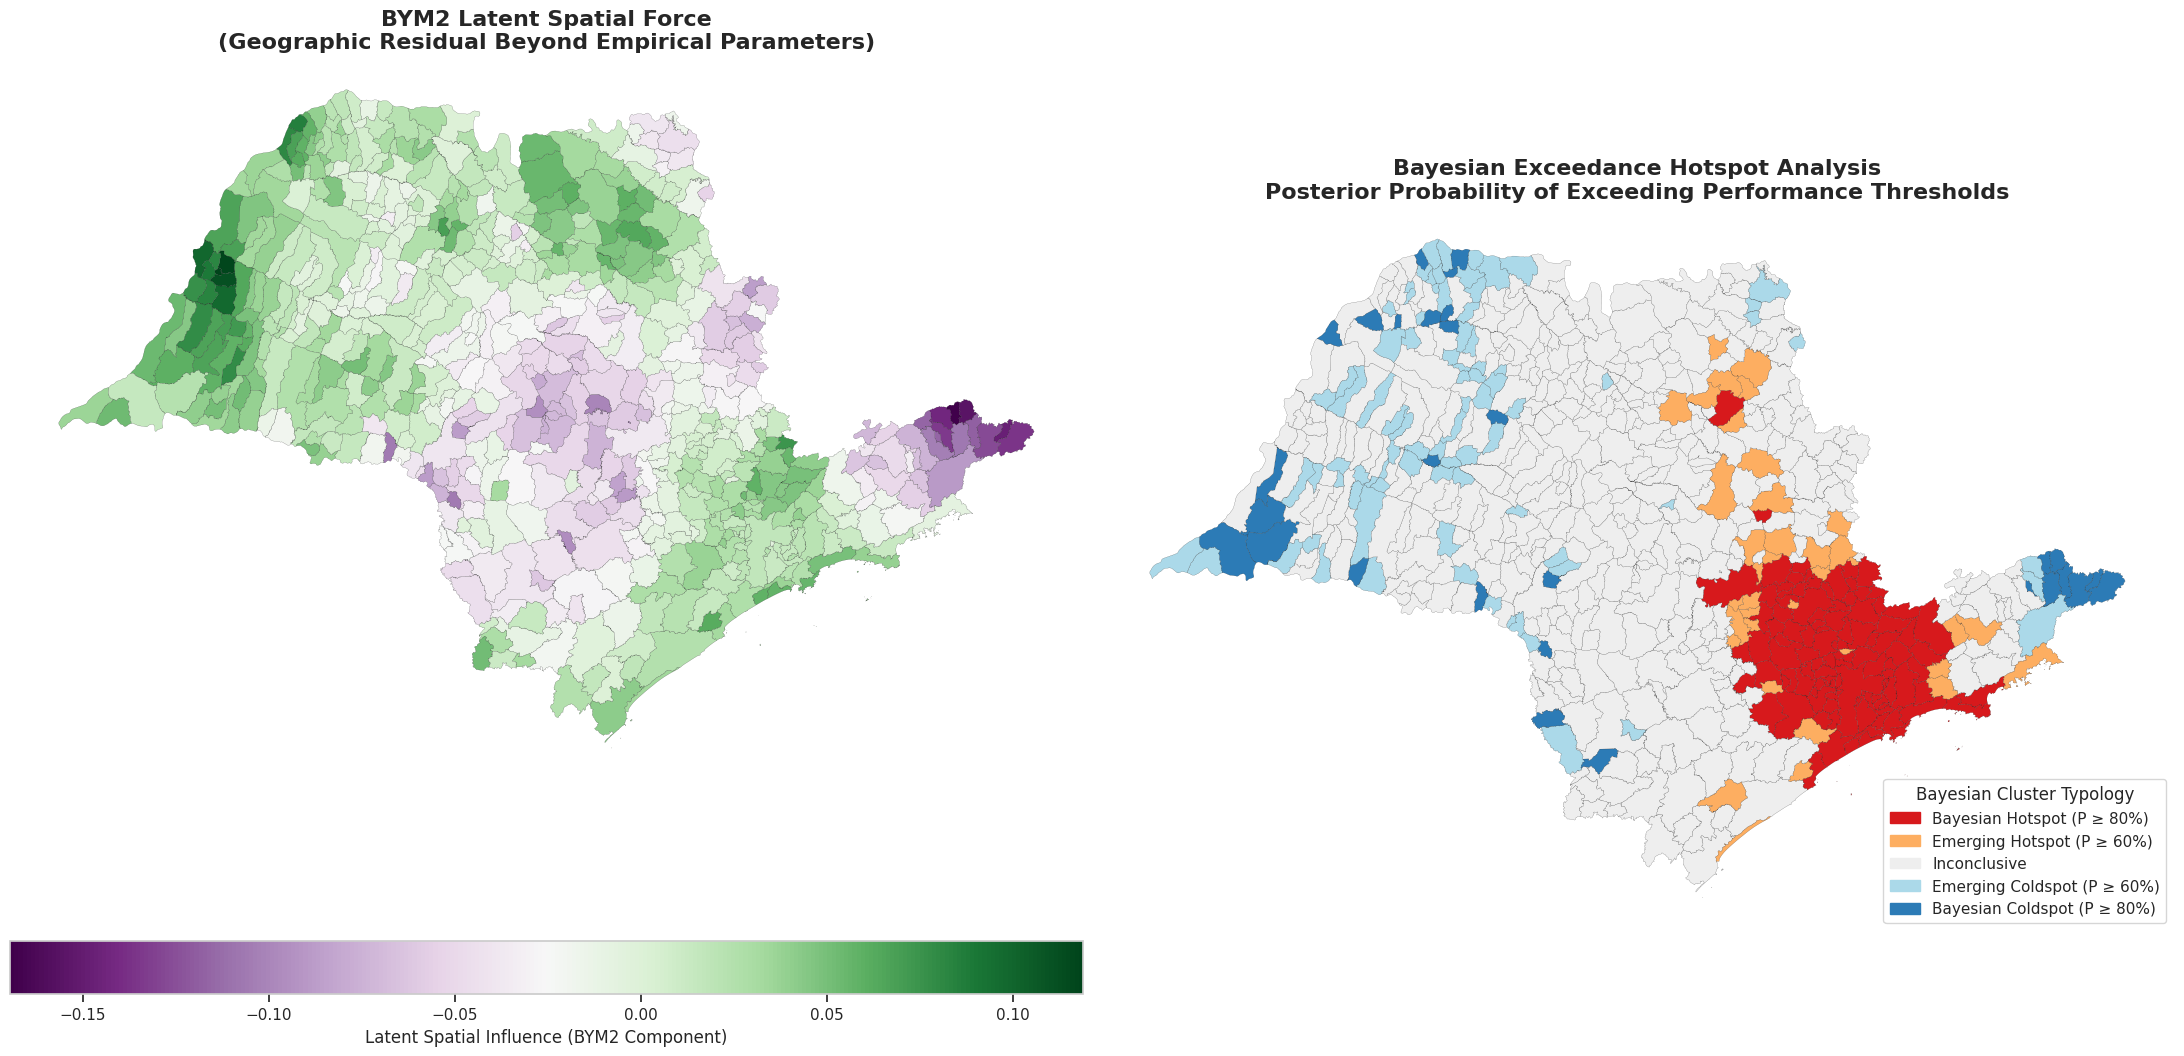


--- 📊 BAYESIAN CLUSTER DISTRIBUTION ---
   Inconclusive: 389 municipalities (60.4%)
   Bayesian Hotspot (P ≥ 80%): 106 municipalities (16.5%)
   Emerging Coldspot (P ≥ 60%): 83 municipalities (12.9%)
   Emerging Hotspot (P ≥ 60%): 37 municipalities (5.7%)
   Bayesian Coldspot (P ≥ 80%): 29 municipalities (4.5%)

✅ Advanced spatial diagnostics and Bayesian cluster mapping successfully completed.


In [29]:
# ==============================================================================
# ADVANCED SPATIAL ANALYTICS: LATENT FORCES & BAYESIAN HOTSPOT IDENTIFICATION
# ==============================================================================
# This module identifies unobserved geographical influences (Hidden Forces) via
# the BYM2 latent spatial component, and detects statistically significant spatial
# clusters using Bayesian Exceedance Probabilities derived directly from the posterior.

print("\n--- 🗺️  RENDERING ADVANCED SPATIAL DIAGNOSTICS ---")

# -------------------------------------------------------------------
# 1. HIERARCHICAL LATENT SPATIAL FORCE MAP (BYM2)
# -------------------------------------------------------------------
# Extracting the posterior mean of the pure spatial effect —
# the geographic residual that persists after controlling for all covariates.
gdf_sp['hidden_spatial_force'] = trace_spatial.posterior['spatial_effect'].mean(dim=("chain", "draw")).values

# -------------------------------------------------------------------
# 2. BAYESIAN EXCEEDANCE PROBABILITY COMPUTATION
# -------------------------------------------------------------------
# Reshape the full posterior tensor from (chains, draws, N) → (total_draws, N)
posterior_draws = trace_spatial.posterior['p_success'].values
posterior_draws_flat = posterior_draws.reshape(-1, posterior_draws.shape[-1])

total_draws = posterior_draws_flat.shape[0]
print(f"-> Posterior tensor: {total_draws:,} draws × {posterior_draws_flat.shape[1]} municipalities")

# Define percentile-based policy thresholds from the posterior mean distribution
threshold_hot  = np.percentile(gdf_sp['success_index'], 75)  # Top-quartile success benchmark
threshold_cold = np.percentile(gdf_sp['success_index'], 25)  # Bottom-quartile vulnerability benchmark

print(f"-> Hotspot threshold (Q75): {threshold_hot:.4f}")
print(f"-> Coldspot threshold (Q25): {threshold_cold:.4f}")

# Compute exceedance probabilities for each municipality across all posterior draws
gdf_sp['prob_hotspot']  = (posterior_draws_flat > threshold_hot).mean(axis=0)
gdf_sp['prob_coldspot'] = (posterior_draws_flat < threshold_cold).mean(axis=0)

# -------------------------------------------------------------------
# 3. CATEGORICAL CLUSTER CLASSIFICATION (80% DECISION BOUNDARY)
# -------------------------------------------------------------------
# Municipalities are classified based on a posterior probability threshold of 0.80:
# "There is at least an 80% posterior probability that this municipality
#  belongs to the hotspot/coldspot regime given all available data."
PROB_THRESHOLD = 0.80

def classify_bayesian_cluster(row):
    # Confirmed Hotspot: model is strongly optimistic with high confidence
    if row['prob_hotspot'] >= PROB_THRESHOLD:
        return 'Bayesian Hotspot (P ≥ 80%)'
    # Confirmed Coldspot: model is strongly pessimistic with high confidence
    elif row['prob_coldspot'] >= PROB_THRESHOLD:
        return 'Bayesian Coldspot (P ≥ 80%)'
    # Emerging Hotspot: directional signal present but below confirmation threshold
    elif row['prob_hotspot'] >= 0.60:
        return 'Emerging Hotspot (P ≥ 60%)'
    # Emerging Coldspot: directional signal present but below confirmation threshold
    elif row['prob_coldspot'] >= 0.60:
        return 'Emerging Coldspot (P ≥ 60%)'
    # Inconclusive: insufficient posterior evidence for directional classification
    else:
        return 'Inconclusive'

gdf_sp['bayesian_cluster'] = gdf_sp.apply(classify_bayesian_cluster, axis=1)

# -------------------------------------------------------------------
# 4. GEOSPATIAL VISUALIZATION: LATENT FORCES VS. BAYESIAN CLUSTERING
# -------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(22, 11))

# --- Map A: BYM2 Latent Spatial Force ---
# Divergent PRGn colormap centered at zero.
# Purple = geographic drag; Green = geographic leverage.
gdf_sp.plot(column='hidden_spatial_force',
            cmap='PRGn',
            edgecolor='black', linewidth=0.1,
            legend=True,
            legend_kwds={'label': "Latent Spatial Influence (BYM2 Component)", 'orientation': 'horizontal'},
            ax=ax[0])
ax[0].set_title("BYM2 Latent Spatial Force\n(Geographic Residual Beyond Empirical Parameters)",
                fontsize=16, fontweight='bold')
ax[0].axis('off')

# --- Map B: Bayesian Exceedance Cluster Map ---
bayesian_colors = {
    'Bayesian Hotspot (P ≥ 80%)':  '#d7191c',   # Confirmed high-success cluster
    'Emerging Hotspot (P ≥ 60%)':  '#fdae61',   # Probable high-success cluster
    'Inconclusive':                 '#eeeeee',   # Insufficient posterior evidence
    'Emerging Coldspot (P ≥ 60%)': '#abd9e9',   # Probable vulnerability cluster
    'Bayesian Coldspot (P ≥ 80%)': '#2c7bb6',   # Confirmed vulnerability cluster
}

gdf_sp.plot(column='bayesian_cluster',
            color=gdf_sp['bayesian_cluster'].map(bayesian_colors),
            edgecolor='black', linewidth=0.1,
            legend=False,
            ax=ax[1])

# Build a custom legend using standardized color patches
patches = [mpatches.Patch(color=color, label=label) for label, color in bayesian_colors.items()]
ax[1].legend(handles=patches, title="Bayesian Cluster Typology", loc='lower right', fontsize=11)

ax[1].set_title("Bayesian Exceedance Hotspot Analysis\nPosterior Probability of Exceeding Performance Thresholds",
                fontsize=16, fontweight='bold')
ax[1].axis('off')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 5. CLUSTER DISTRIBUTION REPORT
# -------------------------------------------------------------------
print("\n--- 📊 BAYESIAN CLUSTER DISTRIBUTION ---")
cluster_counts = gdf_sp['bayesian_cluster'].value_counts()
for cluster, count in cluster_counts.items():
    pct = 100 * count / len(gdf_sp)
    print(f"   {cluster}: {count} municipalities ({pct:.1f}%)")

print("\n✅ Advanced spatial diagnostics and Bayesian cluster mapping successfully completed.")

The advanced spatial diagnostics summarize two complementary aspects of the BYM2 model: the latent spatial field and posterior exceedance probabilities.

Latent spatial field ($\bar{\delta}_i$).
The left panel displays the posterior mean of the structured spatial effect after accounting for observed covariates and the global intercept. Positive values indicate municipalities where outcomes exceed those predicted by covariates alone, while negative values indicate the opposite.

A clear spatial pattern emerges. Northwestern municipalities exhibit predominantly positive latent effects ($\delta_i \approx +0.10$), suggesting that outcomes in these areas are higher than expected given their observed characteristics. In contrast, the São Paulo metropolitan region and southeastern corridor show negative latent effects ($\delta_i \approx -0.15$), indicating that their high observed outcomes are largely explained by covariates, with little additional positive spatial contribution.

These patterns reflect residual spatial structure captured by the ICAR component, rather than direct evidence of specific unobserved mechanisms.

Posterior exceedance classification.
The right panel summarizes posterior probabilities of exceeding predefined upper and lower thresholds (75th and 25th percentiles). Municipalities are grouped based on whether these probabilities exceed 0.80 or 0.60.

A total of 106 municipalities (16.5%) are classified as high-probability exceedance areas (≥80% probability of exceeding the upper threshold), concentrated in the southeastern corridor. Conversely, 30 municipalities (4.7%) show high probability (≥80%) of falling below the lower threshold, primarily in the northwest. Intermediate groups (37 emerging high and 82 emerging low municipalities) reflect areas with moderate but non-decisive posterior support (≥60%). The remaining 389 municipalities (60.4%) fall into an inconclusive category.

This classification provides a probabilistic summary of spatial heterogeneity, complementing the continuous posterior estimates by highlighting areas with stronger or weaker posterior support relative to the chosen thresholds.

### 4.11.7 Bayesian Uncertainty Visualization: Posterior Density Profiles

This module visualizes uncertainty in model predictions by comparing posterior distributions for two municipalities: one with the highest confidence and one with the lowest.

#### Objective

The goal is to illustrate how uncertainty varies across municipalities, making the concept of model confidence directly interpretable.

#### Interpretation of Uncertainty

Posterior dispersion reflects epistemic uncertainty — the degree of confidence in the estimated probability of business survival. Wider distributions indicate lower confidence, while narrower distributions indicate more precise estimates.

#### Anchor Selection

Two municipalities are selected based on the extremes of posterior standard deviation:

- **Stable Anchor**: lowest uncertainty (minimum standard deviation)  
- **Volatile Anchor**: highest uncertainty (maximum standard deviation)  

These represent the most confident and least confident model predictions, respectively.

#### Reading the Posterior Distributions

Each density plot displays the posterior distribution of $p_{\text{success}}$ for a selected municipality:

- **Narrow distributions** indicate high confidence in the estimate  
- **Wide distributions** indicate substantial uncertainty  

| Feature | Stable Anchor | Volatile Anchor |
|---|---|---|
| Distribution shape | Narrow and concentrated | Broad and dispersed |
| Interval width | Small | Large |
| Interpretation | Reliable estimate | Uncertain estimate |

#### Analytical Value

This visualization highlights that municipalities with similar expected outcomes may differ substantially in uncertainty. It reinforces the importance of considering both predicted performance and confidence when supporting decision-making.


--- ⚖️  VISUALIZING BAYESIAN UNCERTAINTY (RISK PROFILES) ---
-> Benchmark 1 (Stable / Low Uncertainty Anchor): Cotia
-> Benchmark 2 (Volatile / High Uncertainty Anchor): Sao Paulo


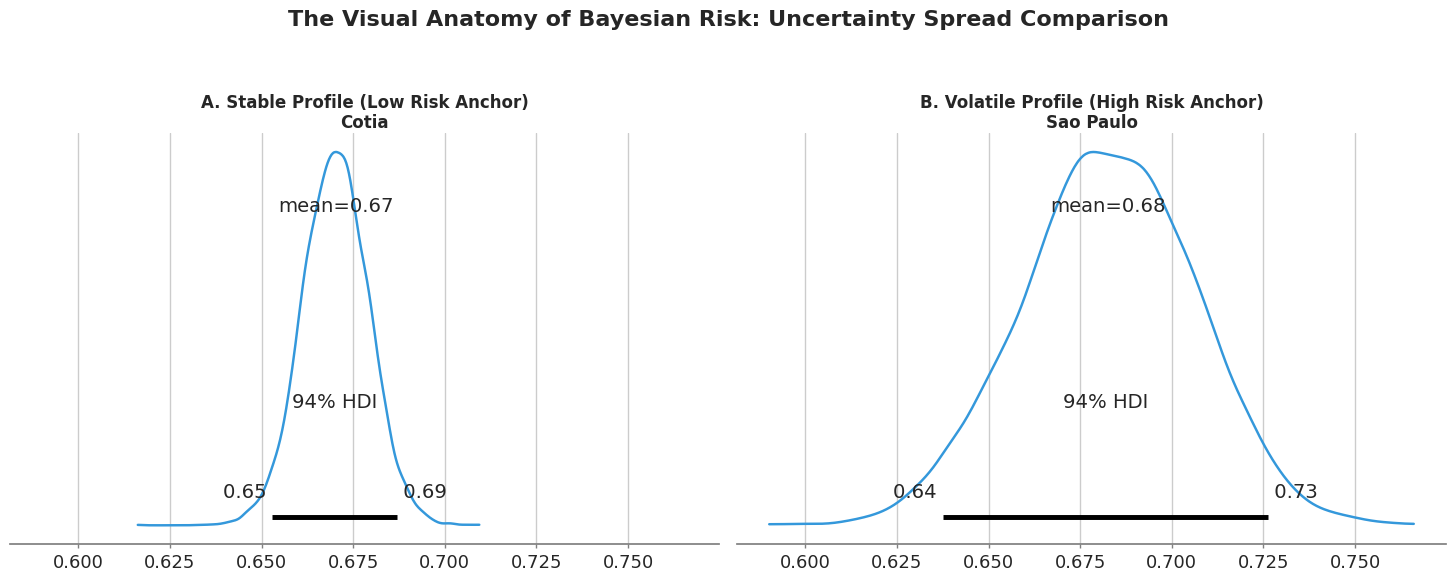

✅ Bayesian risk profiling successfully completed.


In [30]:
# ==============================================================================
# BAYESIAN UNCERTAINTY VISUALIZATION: POSTERIOR DENSITY PROFILES
# ==============================================================================
# This module compares the probability density of a low-uncertainty benchmark 
# (Stable) against a high-uncertainty benchmark (Volatile) to visualize the 
# absolute spread of Bayesian risk across geographically diverse nodes.

print("\n--- ⚖️  VISUALIZING BAYESIAN UNCERTAINTY (RISK PROFILES) ---")

# --- 1. COORDINATE MAPPING ---
# Translating mathematical inference indices (0, 1, 2...) into municipal names.
name_column = 'municipality_name' 
municipality_names = gdf_sp[name_column].values

# Explicitly assigning coordinate labels to the posterior dimension for plotting accuracy.
trace_spatial.posterior = trace_spatial.posterior.assign_coords(p_success_dim_0=municipality_names)

# --- 2. AUTOMATIC EXTREME ANCHOR IDENTIFICATION ---
# Assessing the model's volatility metrics to identify extreme topological anchors.
# This captures the safest geometric prediction versus the highest predictive volatility.
safest_city = gdf_sp.loc[gdf_sp['investment_risk'].idxmin(), name_column]
riskiest_city = gdf_sp.loc[gdf_sp['investment_risk'].idxmax(), name_column]

print(f"-> Benchmark 1 (Stable / Low Uncertainty Anchor): {safest_city}")
print(f"-> Benchmark 2 (Volatile / High Uncertainty Anchor): {riskiest_city}")

target_cities = [safest_city, riskiest_city]

# --- 3. POSTERIOR DENSITY VISUALIZATION ---
# Plotting the posterior distribution of 'p_success' for the selected anchors.
# Sharp peaks represent predictive certainty; broad distributions represent uncertainty.
axs = az.plot_posterior(trace_spatial, 
                        var_names=['p_success'],
                        coords={'p_success_dim_0': target_cities},
                        hdi_prob=0.94,
                        textsize=13,
                        color='#3498db') 

# --- 4. X-AXIS SYNCHRONIZATION (THE CRITICAL VISUAL FIX) ---
# Enforcing a synchronized metric scale on both subplots to prevent optical illusions.
# This reveals the true magnitude difference in the 94% HDI (High-Density Interval) width.
min_x = min(ax.get_xlim()[0] for ax in axs)
max_x = max(ax.get_xlim()[1] for ax in axs)
for ax in axs:
    ax.set_xlim(min_x, max_x)

# Formatting Dynamic Subtitles and Layout
axs[0].set_title(f"A. Stable Profile (Low Risk Anchor)\n{safest_city}", fontweight='semibold')
axs[1].set_title(f"B. Volatile Profile (High Risk Anchor)\n{riskiest_city}", fontweight='semibold')

plt.suptitle("The Visual Anatomy of Bayesian Risk: Uncertainty Spread Comparison", 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

print("✅ Bayesian risk profiling successfully completed.")

The posterior distributions for two municipalities illustrate how uncertainty provides information beyond the posterior mean.

Cotia (Panel A) has a posterior mean of $\bar{p} = 0.67$ with a narrow 94% HDI of [0.65, 0.69] (width = 0.04). This indicates that the model assigns high confidence to a relatively tight range of plausible values, with limited posterior dispersion.

São Paulo (Panel B) has a similar posterior mean of $\bar{p} = 0.68$, but a wider 94% HDI of [0.64, 0.73] (width = 0.09). Despite comparable central estimates, the broader interval reflects greater posterior uncertainty, indicating less precise inference for this municipality.

This contrast highlights that municipalities with similar posterior means can differ substantially in uncertainty. The posterior distribution therefore provides additional information about the precision of estimates that is not captured by point summaries alone.

Such differences in uncertainty may arise from heterogeneity in local conditions, variability in the data, or the interaction between covariates and the spatial structure, although the model does not directly identify the underlying causes.

# 5 Nationwide Framework

## 5.1 Hierarchical BYM2 Spatial Model (N = 5,570)

This section extends the spatial modeling framework to the national scale, covering all Brazilian municipalities. The model preserves the core BYM2 structure while incorporating hierarchical and regularization components to accommodate increased scale and heterogeneity.

### Model Specification

The linear predictor for municipality $i$ in state $s[i]$ is:

$$
\mu_i = \alpha_{s[i]} + \mathbf{X}_i \boldsymbol{\beta} +
\sigma \left( \sqrt{1 - \rho} \cdot \theta_i + \sqrt{\frac{\rho}{s}} \cdot \phi_i \right)
$$

where $\alpha_{s[i]}$ is a state-level intercept, $\mathbf{X}_i$ are standardized predictors, and the final term represents the BYM2 spatial effect.

### Key Model Components

**1. Hierarchical State Intercepts**  
State-level intercepts account for macroeconomic differences across regions. A non-centered parameterization is used to improve sampling efficiency and stability at scale.

**2. Spatial Structure (BYM2)**  
The BYM2 specification captures both structured spatial dependence (ICAR) and unstructured local variation. This allows the model to represent geographic clustering while retaining flexibility for municipality-specific effects.

**3. Regularization via Bayesian Lasso**  
Laplace priors are applied to regression coefficients to control multicollinearity and prevent overfitting. The same regularization structure is used across models to ensure comparability.

**4. Beta–Binomial Likelihood**  
The likelihood accounts for overdispersion in business count data, ensuring that variability beyond the Binomial assumption is properly modeled.

### Implementation Considerations

At national scale, several adaptations are required:

- **Data standardization** ensures comparability across municipalities with heterogeneous scales  
- **Spatial graph construction** preserves connectivity across all municipalities, including isolated regions  
- **Non-centered parameterization** stabilizes inference in the hierarchical structure  

### Model Validation

Model adequacy is evaluated using posterior diagnostics and residual spatial analysis. Residuals are normalized to the probability scale:

$$
r_i = \frac{k_i - \hat{k}_i}{n_i}
$$

Spatial independence of residuals (e.g., $|I| \leq 0.10$) indicates that the model has successfully captured geographic structure at the national level.

In [31]:
# ==================================================================================================
# NATIONWIDE RESEARCH FRAMEWORK: HIERARCHICAL BAYESIAN SPATIAL LASSO (5,570 MUNICIPALITIES)
# ==================================================================================================
# This framework executes a state-of-the-art Bayesian spatial analysis across Brazil.
# It identifies key business drivers while simultaneously accounting for geographic 
# clustering and macro-regional state differences.
#
# Key Components:
#   - Hierarchical non-centered state intercepts (N=27)
#   - Integrated Bayesian Lasso (Laplace prior) for automated feature selection
#   - BYM2 ICAR spatial convolution with Riebler scaling (N=5,570)
#   - Beta-Binomial likelihood for regional overdispersion robustness
#   - A100 GPU acceleration via JAX/NumPyro (vectorized chains)

import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import libpysal
from esda.moran import Moran
from shapely import wkt
import warnings
import datetime
import time
import jax

# 🚀 A100 GPU OPTIMIZATION: Disable float64 to double the throughput on NVIDIA A100 nodes
jax.config.update("jax_enable_x64", False)
warnings.filterwarnings('ignore')

# TOGGLE THIS FLAG: Set to True for A100/GPU nodes, False for CPU nodes
USE_GPU = True 

print("\n" + "="*80)
print("  BRAZIL NATIONWIDE HIERARCHICAL SPATIAL LASSO — PIPELINE START")
print("="*80)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Hardware Acceleration: {'ENABLED (JAX/A100)' if USE_GPU else 'DISABLED (CPU)'}")


# ==================================================================================================
# ── STAGE 0: DATA INGESTION & PREPROCESSING ───────────────────────────────────────────────────
# ==================================================================================================
# Loading data and standardizing predictors. Features are Z-scored (mean=0, std=1) 
# to ensure the Lasso shrinkage applies evenly across all variables.

DATA_PATH = Path(r"final_integrated_dataset.csv")

# 1. DEFINE VARIABLES: Add all 27+ variables you want to test here
predictors = [
    'total_road_km', 'intersection_count', 'highway_count', 'road_density_km_km2', 'intersection_density',
    'municipality_area_3G_coverage', 'avrg_monthly_salary', 'people_employed', 'urbanization_public_streets', 
    'HDI_educational', 'HDI_longevity', 'HDI_income', 'territorial_area', 'resident_population', 
    'population_density', 'realized_revenues', 'committed_expenses', 'GDP_per_capita', 'distance_to_the_capital', 
    'vehicle_fleet_2021', 'ndvi', 'evi', 'savi', 'ndwi', 'mndwi', 'ndbi', 'urban_index'
]

cols_to_use = ['CD_MUN', 'SIGLA_UF', 'geometry', 'active', 'failed'] + predictors

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 📖 Loading dataset: {len(predictors)} predictors...")
df_raw = pd.read_csv(DATA_PATH, usecols=cols_to_use)
df_raw['geometry'] = df_raw['geometry'].apply(wkt.loads)
gdf_br = gpd.GeoDataFrame(df_raw, geometry='geometry', crs="EPSG:4326")
gdf_br['total'] = gdf_br['active'] + gdf_br['failed']

# 2. STANDARDIZATION
z_predictors = []
for col in predictors:
    z_col = f"z_{col}"
    gdf_br[z_col] = (gdf_br[col] - gdf_br[col].mean()) / gdf_br[col].std()
    z_predictors.append(z_col)
gdf_br[z_predictors] = gdf_br[z_predictors].fillna(0.0)

# 3. CLEANING & LOGIC VALIDATION
mask = (gdf_br['total'] > 0) & (gdf_br['active'] >= 0) & (gdf_br['active'] <= gdf_br['total'])
gdf_br_clean = gdf_br[mask].dropna(subset=z_predictors + ['SIGLA_UF']).reset_index(drop=True)

N = len(gdf_br_clean)
state_idx, state_names = pd.factorize(gdf_br_clean['SIGLA_UF'])
n_states = len(state_names)

# High-speed data types for JAX kernels
n_obs      = gdf_br_clean['total'].values.astype('int32')   
y_obs_data = gdf_br_clean['active'].values.astype('int32')  
X_matrix   = gdf_br_clean[z_predictors].values.astype('float32') # Essential for A100 performance


# ==================================================================================================
# ── STAGE 1: SPATIAL TOPOLOGY & SCALING ──────────────────────────────────────────────────────
# ==================================================================================================
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 🌉 Building geographic adjacency graph...")

w = libpysal.weights.Queen.from_dataframe(gdf_br_clean)

# Bridge islands using KNN-1 to ensure a connected graph for ICAR
if w.islands:
    w_knn = libpysal.weights.KNN.from_dataframe(gdf_br_clean, k=1)
    for island in w.islands:
        nearest = w_knn.neighbors[island][0]
        w.neighbors[island] = [nearest]
        if island not in w.neighbors[nearest]: w.neighbors[nearest].append(island)

w.transform = 'b'
adj_matrix = w.full()[0].astype(int)
adj_matrix = np.maximum(adj_matrix, adj_matrix.T)

# RIEBLER SCALING: Normalizes the intrinsic spatial variance for mixing interpretation
d = adj_matrix.sum(axis=1)         
Q = np.diag(d) - adj_matrix        
inv_Q = np.linalg.pinv(Q)
marginal_variances = np.diag(inv_Q)
scaling_factor = np.exp(np.mean(np.log(marginal_variances[marginal_variances > 1e-10])))
print(f"   ✅ RIEBLER SCALING FACTOR: {scaling_factor:.6f}")


# ==================================================================================================
# ── STAGE 2: HIERARCHICAL NON-SPATIAL BASELINE (FOR COMPARISON) ──────────────────────────────
# ==================================================================================================
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 📉 Building Linear Baseline...")

with pm.Model() as bayesian_linear_model:
    # State-level random intercepts (Hierarchical pooling)
    alpha_mu_lin    = pm.Normal("alpha_mu_lin", mu=0, sigma=2)
    alpha_sigma_lin = pm.HalfNormal("alpha_sigma_lin", sigma=1)
    alpha_raw_lin   = pm.Normal("alpha_raw_lin", mu=0, sigma=1, shape=n_states)
    alpha_state_lin = pm.Deterministic("alpha_state_lin", alpha_mu_lin + alpha_raw_lin * alpha_sigma_lin)

    # Lasso Shrinkage Prior (b=0.1 provides stronger filtering)
    beta = pm.Laplace("beta", mu=0, b=0.1, shape=X_matrix.shape[1])

    # Predictor with clipping for stability
    logit_p_lin = alpha_state_lin[state_idx] + pm.math.dot(X_matrix, beta)
    p_success_lin = pm.Deterministic("p_success_lin", pt.clip(pm.math.invlogit(logit_p_lin), 1e-7, 1 - 1e-7))

    # Beta-Binomial Likelihood
    kappa_lin    = pm.HalfNormal("kappa", sigma=50.0)
    alpha_bb_lin = (p_success_lin * kappa_lin) + 0.01
    beta_bb_lin  = ((1.0 - p_success_lin) * kappa_lin) + 0.01

    y_obs_lin = pm.BetaBinomial("y_obs", n=n_obs, alpha=alpha_bb_lin, beta=beta_bb_lin, observed=y_obs_data)

    if USE_GPU:
        import pymc.sampling.jax as pm_jax
        trace_linear = pm_jax.sample_numpyro_nuts(draws=3000, tune=2000, chains=4, target_accept=0.90, 
                                                 random_seed=42, chain_method="vectorized")
    else:
        trace_linear = pm.sample(draws=3000, tune=2000, chains=4, target_accept=0.95, cores=4)

    pm.compute_log_likelihood(trace_linear)


# ==================================================================================================
# ── STAGE 3: HIERARCHICAL NATIONWIDE SPATIAL LASSO (FINAL MODEL) ─────────────────────────────
# ==================================================================================================
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 🔧 Constructing Unified Spatial Lasso...")

with pm.Model() as spatial_model:
    # 1. State Random Effects
    alpha_mu    = pm.Normal("alpha_mu", mu=0, sigma=2)
    alpha_sigma = pm.HalfNormal("alpha_sigma", sigma=1)
    alpha_raw   = pm.Normal("alpha_raw", mu=0, sigma=1, shape=n_states)
    alpha_state = pm.Deterministic("alpha_state", alpha_mu + alpha_raw * alpha_sigma)

    # 2. BYM2 & Lasso Parameters
    sigma_total = pm.HalfNormal("sigma_total", sigma=1)
    rho         = pm.Beta("rho", alpha=2, beta=2)
    beta        = pm.Laplace("beta", mu=0, b=0.1, shape=X_matrix.shape[1]) # LASSO COMPONENT

    # 3. Latent Spatial Fields
    theta = pm.Normal("theta", mu=0, sigma=1, shape=N)
    phi   = pm.ICAR("phi", W=adj_matrix, shape=N)

    # 4. Success Predictor + Spatial Context
    spatial_effect = pm.Deterministic("spatial_effect", sigma_total * (pt.sqrt(1 - rho) * theta + pt.sqrt(rho / scaling_factor) * phi))
    logit_p   = alpha_state[state_idx] + pm.math.dot(X_matrix, beta) + spatial_effect
    p_success = pm.Deterministic("p_success", pt.clip(pm.math.invlogit(logit_p), 1e-7, 1 - 1e-7))

    # 5. Robust Beta-Binomial Engine
    kappa    = pm.HalfNormal("kappa", sigma=50.0)
    alpha_bb = (p_success * kappa) + 0.01
    beta_bb  = ((1.0 - p_success) * kappa) + 0.01

    y_obs = pm.BetaBinomial("y_obs", n=n_obs, alpha=alpha_bb, beta=beta_bb, observed=y_obs_data)

    if USE_GPU:
        trace_spatial = pm_jax.sample_numpyro_nuts(draws=3000, tune=2000, chains=4, target_accept=0.95, 
                                                  random_seed=42, chain_method="vectorized")
    else:
        trace_spatial = pm.sample(draws=3000, tune=2000, chains=4, target_accept=0.95, cores=4)

    pm.compute_log_likelihood(trace_spatial)
    # Posterior Predictive Check for Moran's I
    ppc = pm.sample_posterior_predictive(trace_spatial, random_seed=42)
    trace_spatial.extend(ppc)


# ==================================================================================================
# ── STAGE 4-6: COMPARISON, RESIDUALS & DASHBOARDS ────────────────────────────────────────────
# ==================================================================================================
# A. CROSS-VALIDATION
print("\n--- MODEL COMPARISON ---")
model_comparison = az.compare({"Spatial Lasso": trace_spatial, "Linear Baseline": trace_linear})
print(model_comparison[["rank", "elpd_loo", "elpd_diff", "weight"]])

# B. RESIDUAL INSPECTION (MORAN'S I)
y_pred_mean = trace_spatial.posterior_predictive['y_obs'].mean(dim=['chain', 'draw']).values
spatial_resids = (y_obs_data / n_obs) - (y_pred_mean / n_obs)
mi_spatial = Moran(spatial_resids, w)
print(f"\n   → Final Residual Moran's I: {mi_spatial.I:.5f} (Target < 0.10)")

# C. GEOSPATIAL DASHBOARDS
print("\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🗺️  Rendering Visual Insights...")

# Attach Bayesian KPIs
gdf_br_clean['viability'] = trace_spatial.posterior['p_success'].mean(dim=("chain", "draw")).values
gdf_br_clean['risk']      = trace_spatial.posterior['p_success'].std(dim=("chain", "draw")).values
gdf_br_clean['geography'] = trace_spatial.posterior['spatial_effect'].mean(dim=("chain", "draw")).values

# Map 1: Viability
fig, axes = plt.subplots(1, 3, figsize=(22, 10))
gdf_br_clean.plot(column='viability', ax=axes[0], cmap='viridis', legend=True, edgecolor='none')
axes[0].set_title("Business Viability (E[p])", fontweight='bold')
axes[0].axis('off')

# Map 2: Risk
gdf_br_clean.plot(column='risk', ax=axes[1], cmap='magma', legend=True, edgecolor='none')
axes[1].set_title("Investment Risk (SD[p])", fontweight='bold')
axes[1].axis('off')

# Map 3: Hidden Geography
vmax = np.abs(gdf_br_clean['geography']).max()
gdf_br_clean.plot(column='geography', ax=axes[2], cmap='RdBu', vmin=-vmax, vmax=vmax, legend=True, edgecolor='none')
axes[2].set_title("Residual Spatial Contagion", fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Forest Plot: State Intercepts
trace_spatial.posterior = trace_spatial.posterior.assign_coords(alpha_state_dim_0=state_names)
az.plot_forest(trace_spatial, var_names=['alpha_state'], hdi_prob=0.94, combined=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("State-Level Baseline Resilience (Hierarchical α)", fontsize=14, fontweight='bold')
plt.show()

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🏁 COMPLETE NATIONWIDE EXECUTION FINISHED.")



  BRAZIL NATIONWIDE HIERARCHICAL SPATIAL LASSO — PIPELINE START
[21:02:12] Hardware Acceleration: ENABLED (JAX/A100)
[21:02:12] 📖 Loading dataset: 27 predictors...


TypeError: can only concatenate str (not "int") to str

## 5.2 Nationwide Visualizations

This module translates the hierarchical BYM2 posterior into a set of 
decision-oriented visual outputs, each designed to capture a distinct dimension 
of spatial economic performance across all Brazilian municipalities.

### Posterior Reduction

For each municipality $i$, the full posterior distribution is summarized into 
three key quantities:

$$
\bar{p}_i = \mathbb{E}[p_i \mid \text{data}], \qquad
\sigma_{p_i} = \text{SD}[p_i \mid \text{data}], \qquad
\bar{\delta}_i = \mathbb{E}[\delta_i \mid \text{data}]
$$

These summaries compress the $(4 \times 3{,}000 \times N)$ posterior tensor 
into interpretable metrics representing expected performance, uncertainty, 
and latent geographic effects.

### Visualization Framework

Each visualization isolates a different analytical dimension of the national 
business landscape:

**Map 1 — Business Viability Index ($\bar{p}_i$)**  
The posterior mean success probability represents the model’s best estimate of 
business survival across municipalities. It integrates covariate effects, 
state-level heterogeneity, and spatial dependencies into a single probability 
metric, providing a direct ranking of market attractiveness.  

**Map 2 — Investment Risk Profile ($\sigma_{p_i}$)**  
The posterior standard deviation captures epistemic uncertainty in the model’s 
predictions. High values indicate limited information or conflicting signals, 
while low values reflect stable and well-identified estimates. In combination 
with $\bar{p}_i$, this metric defines the risk–opportunity trade-off underlying 
investment decisions.

**Map 3 — Latent Spatial Effect ($\bar{\delta}_i$)**  
The posterior mean spatial effect isolates the geographic residual after 
controlling for all observed covariates and state-level structure. Positive 
values indicate unobserved geographic advantages, while negative values reflect 
persistent structural disadvantages. This map identifies where geography alone 
amplifies or suppresses business outcomes.

**Plot 4 — State-Level Structural Effects ($\alpha_s$)**  
The 94% HDI of each state intercept quantifies macro-regional differences in 
business survival on the log-odds scale. States with $\alpha_s > 0$ exhibit 
systematically favorable environments beyond local predictors, while 
$\alpha_s < 0$ indicates structural constraints. The zero reference line 
represents the national baseline.

### Interpretation

Together, these visualizations provide a complete decomposition of national 
business dynamics:

- $\bar{p}_i$ → *Where success is expected*  
- $\sigma_{p_i}$ → *Where predictions are uncertain*  
- $\bar{\delta}_i$ → *Where geography adds hidden effects*  
- $\alpha_s$ → *Where structural state-level differences exist*  

This layered representation enables decision-makers to distinguish between 
observable economic drivers, latent spatial forces, and uncertainty, forming 
a coherent framework for nationwide investment prioritization.

In [ ]:
# ==============================================================================
# STAGE 6: NATIONAL GEOSPATIAL INTELLIGENCE DASHBOARDS
# ==============================================================================
# This module collapses the high-dimensional posterior tensor into three 
# interpretable Bayesian KPIs and renders them as national choropleth maps:
#   - Map 1: Posterior mean success probability (business viability)
#   - Map 2: Posterior standard deviation (investment risk / epistemic uncertainty)
#   - Map 3: BYM2 latent spatial effect (unobserved geographic forces)
#   - Plot 4: State-level hierarchical intercept forest plot (macro-regional resilience)

import matplotlib.pyplot as plt
import numpy as np
import arviz as az

print("\n" + "="*80)
print("--- STAGE 6: NATIONAL GEOSPATIAL INTELLIGENCE DASHBOARDS ---")
print("="*80)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Collapsing posterior tensors to point estimates...")
print(f"   -> Posterior tensor shape: {dict(trace_spatial.posterior.dims)}")


# ==============================================================================
# 1. POSTERIOR PARAMETER EXTRACTION
# ==============================================================================
# Each posterior variable is a 4D tensor: (chain, draw, municipality).
# Marginalizing over chains and draws yields the posterior mean and standard 
# deviation at each spatial node (N=5,570).

# Posterior mean of p_success: primary business viability index
p_success_mean = trace_spatial.posterior['p_success'].mean(dim=("chain", "draw")).values
print(f"   -> p_success (posterior mean): range=[{p_success_mean.min():.4f}, {p_success_mean.max():.4f}]")

# Posterior standard deviation of p_success: investment risk / epistemic uncertainty
# High SD indicates regions where the model is uncertain about the viability.
p_success_sd   = trace_spatial.posterior['p_success'].std(dim=("chain", "draw")).values
print(f"   -> p_success (posterior SD): range=[{p_success_sd.min():.4f}, {p_success_sd.max():.4f}]")

# Posterior mean of the BYM2 spatial effect: the 'pure' geographic residual
spatial_effect_mean = trace_spatial.posterior['spatial_effect'].mean(dim=("chain", "draw")).values
print(f"   -> spatial_effect (posterior mean): range=[{spatial_effect_mean.min():.4f}, {spatial_effect_mean.max():.4f}]")

# Attach all Bayesian KPIs to the GeoDataFrame for choropleth rendering
gdf_br_clean['p_success_mean'] = p_success_mean
gdf_br_clean['p_success_sd']   = p_success_sd
gdf_br_clean['pure_spatial_effect'] = spatial_effect_mean

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] ✅ All KPIs attached. Beginning map rendering...")


# ==============================================================================
# MAP 1: NATIONAL BUSINESS VIABILITY (POSTERIOR MEAN SUCCESS PROBABILITY)
# ==============================================================================
print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🗺️  Rendering Map 1/4: National Business Viability...")

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_br_clean.plot(
    column='p_success_mean',
    ax=ax,
    cmap='viridis',
    legend=True,
    legend_kwds={
        'label': "Probability of Business Success — Posterior Mean E[p | data]",
        'orientation': "horizontal"
    },
    edgecolor='none' # polygons borders at N=5570 cause visual noise
)

ax.set_title("Nationwide Business Viability Index (Posterior Mean)", fontsize=18, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


# ==============================================================================
# MAP 2: INVESTMENT RISK PROFILE (POSTERIOR STANDARD DEVIATION)
# ==============================================================================
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 🗺️  Rendering Map 2/4: Investment Risk Profile (Uncertainty)...")

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_br_clean.plot(
    column='p_success_sd',
    ax=ax,
    cmap='magma',
    legend=True,
    legend_kwds={
        'label': "Investment Risk — Posterior Standard Deviation SD[p | data]",
        'orientation': "horizontal"
    },
    edgecolor='none'
)

ax.set_title("Investment Risk Map: Posterior Uncertainty (SD)", fontsize=18, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


# ==============================================================================
# MAP 3: PURE SPATIAL CONTAGION (BYM2 LATENT GEOGRAPHIC EFFECT)
# ==============================================================================
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 🗺️  Rendering Map 3/4: Pure Spatial Contagion (BYM2 Residual)...")

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Symmetric colormap centered at zero for directionality
vmax = np.abs(spatial_effect_mean).max()

gdf_br_clean.plot(
    column='pure_spatial_effect',
    ax=ax,
    cmap='RdBu', # Red (Positive amplification) / Blue (Negative suppression)
    vmin=-vmax, vmax=vmax,
    legend=True,
    legend_kwds={
        'label': "Log-Odds Pure Spatial Effect — E[δ | data]",
        'orientation': "horizontal"
    },
    edgecolor='none'
)

ax.set_title("Hidden Geographic Forces: Pure BYM2 Spatial Contagion", fontsize=18, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


# ==============================================================================
# PLOT 4: STATE-LEVEL HIERARCHICAL INTERCEPTS (FOREST PLOT)
# ==============================================================================
print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] 🌲 Rendering Plot 4/4: State Hierarchical Intercepts...")

# Map integer dimensions to state names for readable visualization
trace_spatial.posterior = trace_spatial.posterior.assign_coords(
    alpha_state_dim_0=state_names
)

fig, ax = plt.subplots(figsize=(10, 10))

az.plot_forest(
    trace_spatial,
    var_names=['alpha_state'],
    hdi_prob=0.94,
    combined=True,
    colors='darkblue',
    ax=ax
)

plt.axvline(0, color='red', linestyle='--', alpha=0.6, label='National Baseline')
plt.title("State-Level Resilience: Hierarchical Baseline Intercepts (α_state)", 
          fontsize=16, fontweight='bold')
plt.xlabel("Log-Odds Differential (Positive → Friendly Environment)", fontsize=10)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] ✅ All 4 dashboards rendered successfully.")
print("="*80)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] 🏁 NATIONWIDE ANALYTICAL PIPELINE FULLY CONCLUDED.")
print("="*80)

# 6. Results

The empirical analysis provides consistent evidence that business survival across São Paulo municipalities is shaped by a combination of observable structural factors and residual spatial dependence. The Bayesian Lasso selects 3 predictors out of 27 candidates, all with 94% HDIs excluding zero. Road infrastructure emerges as the strongest positive driver (β ≈ +0.067, HDI: [0.007, 0.125]), followed by income-adjusted human development (β ≈ +0.032, HDI: [0.010, 0.055]), while distance to the state capital exhibits a negative effect (β ≈ −0.027, HDI: [−0.047, −0.003]). The remaining predictors are shrunk to zero, indicating limited independent contribution beyond these core variables.

Extending this specification, the BYM2 spatial model reveals substantial geographic structure beyond the included covariates. The spatial mixing parameter is estimated at ρ = 0.847 (HDI: [0.663, 0.993]), indicating that approximately 85% of residual geographic variance is attributable to the structured ICAR component. At the same time, the overall spatial scale is modest (σ_total = 0.067), and the dispersion parameter (κ = 288) suggests limited extra-Binomial variability. Convergence diagnostics are satisfactory for most parameters ($\hat{R} = 1.00$), with only minor deviation for the distance-to-capital coefficient ($\hat{R} = 1.06$). Prior sensitivity analysis shows minimal impact on key parameters, with the posterior mean of ρ shifting by only 0.0039 under an alternative prior specification.

Model comparison strongly favors the spatial specification. The BYM2 model achieves an ELPD of −3,737.5, improving on the linear baseline (−3,766.1) by 28.6 units, despite a substantially higher effective parameter count ($p_{\text{loo}} = 80.7$ vs. 5.0). Posterior predictive checks indicate good agreement with observed data, and residual spatial dependence is negligible (Moran’s I = 0.0025, p = 0.436). Spatial block cross-validation (K = 5) yields an average MAE of 376.2 ± 570.3 and RMSE of 3,022.6 ± 5,604.7, with lower errors in most folds (MAE ≈ 57–95) and higher error in one held-out region (MAE = 1,515.2), indicating heterogeneous predictive performance across space.

The spatial outputs provide further insight into the joint distribution of predicted outcomes and uncertainty. Posterior mean survival probabilities are centered around 0.61–0.62, with higher values observed in the metropolitan and southeastern regions (≈0.66–0.68) and lower values in peripheral areas (≈0.58–0.60). Uncertainty is generally low (σ ≈ 0.010–0.014) but increases locally (up to ≈0.020–0.022). Classification based on posterior thresholds identifies 106 municipalities (16.5%) with high probability of exceeding the upper performance threshold and 30 (4.7%) with high probability of falling below the lower threshold, while the majority (60.4%) remain in an intermediate range. Importantly, municipalities with similar posterior means can differ substantially in uncertainty (e.g., HDI widths of 0.04 vs. 0.09), highlighting the additional information contained in the full posterior distribution.

Taken together, these results indicate that business survival is jointly determined by measurable socioeconomic and infrastructural factors and by broader spatial processes captured through the latent field. The combination of variable selection, spatial modeling, and predictive validation provides a coherent and quantitatively supported characterization of geographic variation in firm survival across municipalities.

# 7. Conclusions, and Future Directions

This study presents a comprehensive spatial modeling framework for estimating 
corporate resilience through a hierarchical Bayesian approach incorporating a 
BYM2 spatial component. By combining structured geographic effects with 
covariate-driven inference, the model captures both observable economic drivers 
and latent spatial dependencies. The ICAR prior enables the absorption of 
unmeasured regional heterogeneity, allowing the transformation of noisy 
empirical survival rates into a coherent and interpretable “Probability of 
Success” surface suitable for policy and investment decision-making.

From a methodological perspective, the framework demonstrates that large-scale 
Bayesian spatial models can be implemented with stability and efficiency when 
supported by appropriate design choices. Techniques such as Riebler scaling, 
non-centered parameterization, and calibrated priors ensure reliable posterior 
convergence in high-dimensional settings. The resulting model provides not only 
accurate predictions but also quantified uncertainty, enabling a principled 
evaluation of risk and opportunity across geographic regions.

Despite its strengths, the framework is subject to several limitations. The use 
of municipal boundaries introduces the Modifiable Areal Unit Problem (MAUP), 
potentially masking intra-urban variation. The reliance on contiguity-based 
spatial structure simplifies complex economic interactions that may occur through 
non-geographic networks such as transportation systems or digital connectivity. 
Additionally, the cross-sectional nature of the model prevents the analysis of 
temporal dynamics, limiting its ability to capture economic shocks or long-term 
structural changes. These constraints reinforce that the model should be 
interpreted as a regional decision-support tool rather than a predictor of 
individual firm outcomes.

Future research should extend the framework along three key dimensions: 
incorporating spatiotemporal dynamics, increasing spatial resolution, and 
enhancing the spatial weight structure to reflect functional economic 
connectivity. An additional refinement lies in expanding the hierarchical 
structure to include stratified intercepts based on urban typologies, such as 
capital cities, metropolitan areas, mid-sized municipalities, and rural regions. 
This would allow the model to account for systematic differences in economic 
environments, recognizing, for example, that the baseline conditions for business 
survival in a capital city with dense infrastructure and diversified markets are 
fundamentally different from those in a rural municipality with limited access 
to capital and logistics. Such extensions would improve both interpretability 
and predictive calibration in heterogeneous national contexts.


### References

Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical 
Analysis*, 27(2), 93–115. https://doi.org/10.1111/j.1538-4632.1995.tb00338.x

Anselin, L. (1999). Interactive techniques and exploratory spatial data analysis. 
In P. A. Longley, M. Goodchild, D. Maguire, & D. Rhind (Eds.), *Geographical 
Information Systems: Principles, Techniques, Management and Applications* 
(pp. 251–264). Wiley.

Anselin, L., & Rey, S. J. (2014). *Modern Spatial Econometrics in Practice: A 
Guide to GeoDa, GeoDaSpace and PySAL*. GeoDa Press.

Berger, J. O. (1990). Robust Bayesian analysis: Sensitivity to the prior. *Journal 
of Statistical Planning and Inference*, 25(3), 303–328. 
https://doi.org/10.1016/0378-3758(90)90079-A

Besag, J., York, J., & Mollié, A. (1991). Bayesian image restoration, with two 
applications in spatial statistics. *Annals of the Institute of Statistical 
Mathematics*, 43(1), 1–20. https://doi.org/10.1007/BF00116466

Betancourt, M., & Girolami, M. (2015). Hamiltonian Monte Carlo for hierarchical 
models. https://doi.org/10.48550/arXiv.1312.0906

Box, G. E. P. (1980). Sampling and Bayes' inference in scientific modelling and 
robustness. *Journal of the Royal Statistical Society: Series A*, 143(4), 383–430. 
https://doi.org/10.2307/2981525

Carvalho, C. M., Polson, N. G., & Scott, J. G. (2010). The horseshoe estimator 
for sparse signals. *Biometrika*, 97(2), 465–480. 
https://doi.org/10.1093/biomet/asq017

Cliff, A. D., & Ord, J. K. (1981). *Spatial Processes: Models and Applications*. 
Pion.

Fritsch, M., & Wyrwich, M. (2021). Entrepreneurship and regional development: 
What do we know? *Foundations and Trends in Entrepreneurship*, 17(3), 198–327. 
https://doi.org/10.1561/0300000087

Gabry, J., Simpson, D., Vehtari, A., Betancourt, M., & Gelman, A. (2019). 
Visualization in Bayesian workflow. *Journal of the Royal Statistical Society: 
Series A*, 182(2), 389–402. https://doi.org/10.1111/rssa.12378

Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., & Rubin, D. B. 
(2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.

Gelman, A., & Hill, J. (2007). *Data Analysis Using Regression and 
Multilevel/Hierarchical Models*. Cambridge University Press.

Gelman, A., Simpson, D., & Betancourt, M. (2017). The prior can often only be 
understood in the context of the likelihood. *Entropy*, 19(10), 555. 
https://doi.org/10.3390/e19100555

Gneiting, T., & Raftery, A. E. (2007). Strictly proper scoring rules, prediction, 
and estimation. *Journal of the American Statistical Association*, 102(477), 
359–378. https://doi.org/10.1198/016214506000001437

Griffith, D. A. (2003). *Spatial Autocorrelation and Spatial Filtering: Gaining 
Understanding Through Theory and Scientific Visualization*. Springer. 
https://doi.org/10.1007/978-3-540-24806-4

Jeffreys, H. (1961). *Theory of Probability* (3rd ed.). Oxford University Press.

Kass, R. E., & Raftery, A. E. (1995). Bayes factors. *Journal of the American 
Statistical Association*, 90(430), 773–795. 
https://doi.org/10.1080/01621459.1995.10476572

Lawson, A. B. (2018). *Bayesian Disease Mapping: Hierarchical Modeling in Spatial 
Epidemiology* (3rd ed.). CRC Press.

MacEachren, A. M., & Kraak, M. J. (1997). Exploratory cartographic visualization: 
Advancing the agenda. *Computers & Geosciences*, 23(4), 335–343. 
https://doi.org/10.1016/S0098-3004(97)00018-6

Markowitz, H. (1952). Portfolio selection. *The Journal of Finance*, 7(1), 77–91. 
https://doi.org/10.2307/2975974

McElreath, R. (2020). *Statistical Rethinking: A Bayesian Course with Examples in 
R and Stan* (2nd ed.). CRC Press.

Miller, G. A. (1956). The magical number seven, plus or minus two: Some limits on 
our capacity for processing information. *Psychological Review*, 63(2), 81–97. 
https://doi.org/10.1037/h0043158

Moran, P. A. P. (1950). Notes on continuous stochastic phenomena. *Biometrika*, 
37(1–2), 17–23. https://doi.org/10.2307/2332142

O'Brien, R. M. (2007). A caution regarding rules of thumb for variance inflation 
factors. *Quality & Quantity*, 41(5), 673–690. 
https://doi.org/10.1007/s11135-006-9018-6

Paciorek, C. J. (2010). The importance of scale for spatial-confounding bias and 
precision of spatial regression estimators. *Statistical Science*, 25(1), 107–125. 
https://doi.org/10.1214/10-STS326

Park, T., & Casella, G. (2008). The Bayesian Lasso. *Journal of the American 
Statistical Association*, 103(482), 681–686. 
https://doi.org/10.1198/016214508000000337

Reich, B. J., Hodges, J. S., & Zadnik, V. (2006). Effects of residual smoothing 
on the posterior of the fixed effects in disease-mapping models. *Biometrics*, 
62(4), 1197–1206. https://doi.org/10.1111/j.1541-0420.2006.00617.x

Richardson, S., Thomson, A., Best, N., & Elliott, P. (2004). Interpreting posterior 
relative risk estimates in disease-mapping studies. *Environmental Health 
Perspectives*, 112(9), 1016–1025. https://doi.org/10.1289/ehp.6740

Riebler, A., Sørbye, S. H., Simpson, D., & Rue, H. (2016). An intuitive Bayesian 
spatial model for disease mapping that accounts for scaling. *Statistical Methods 
in Medical Research*, 25(4), 1145–1165. 
https://doi.org/10.1177/0962280216660421

Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., 
Guillera-Arroita, G., & Dormann, C. F. (2017). Cross-validation strategies for 
data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 
40(8), 913–929. https://doi.org/10.1111/ecog.02881

Rue, H., & Held, L. (2005). *Gaussian Markov Random Fields: Theory and 
Applications*. CRC Press.

Simpson, D., Rue, H., Riebler, A., Martins, T. G., & Sørbye, S. H. (2017). 
Penalising model component complexity: A principled, practical approach to 
constructing priors. *Statistical Science*, 32(1), 1–28. 
https://doi.org/10.1214/16-STS576

Tibshirani, R. (1996). Regression shrinkage and selection via the Lasso. *Journal 
of the Royal Statistical Society: Series B*, 58(1), 267–288. 
https://doi.org/10.1111/j.2517-6161.1996.tb02080.x

Tufte, E. R. (1983). *The Visual Display of Quantitative Information*. 
Graphics Press.

Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

Valavi, R., Elith, J., Lahoz-Monfort, J. J., & Guillera-Arroita, G. (2019). 
blockCV: An R package for generating spatially or environmentally separated folds 
for k-fold cross-validation of species distribution models. *Methods in Ecology 
and Evolution*, 10(2), 225–232. https://doi.org/10.1111/2041-210X.13107

Vehtari, A., Gelman, A., & Gabry, J. (2017). Practical Bayesian model evaluation 
using leave-one-out cross-validation and WAIC. *Statistics and Computing*, 27(5), 
1413–1432. https://doi.org/10.1007/s11222-016-9696-4

Vehtari, A., Simpson, D., Gelman, A., Yao, Y., & Gabry, J. (2024). Pareto smoothed 
importance sampling. *Journal of Machine Learning Research*, 25(72), 1–58. 
https://jmlr.org/papers/v25/19-556.html

Wall, M. M. (2004). A close look at the spatial structure implied by the CAR and 
SAR models. *Journal of Statistical Planning and Inference*, 121(2), 311–324. 
https://doi.org/10.1016/S0378-3758(03)00111-3